In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nibabel as nib
import seaborn as sns

from nilearn import plotting
from nilearn.image import new_img_like

In [2]:
import rsatoolbox
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed, Model
from rsatoolbox.rdm import RDMs
from rsatoolbox.vis import show_rdm, show_rdm_panel

from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight
from glob import glob

In [3]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [4]:
project_dir = os.path.join('/bgfs/bchandrasekaran/krs228/data/', 'FLT/')
fmriprep_dir = os.path.join(project_dir, 'data_denoised/derivatives/',
                            'denoised_fmriprep-22.1.1/')

bidsroot = os.path.join(project_dir, 'data_denoised')
deriv_dir = os.path.join(bidsroot, 'derivatives')

fwhm_sub = 0
model_dir = os.path.join(deriv_dir, 'nilearn', 'level-1_fwhm-{:.02f}'.format(fwhm_sub),)

task_list = ['tonecat']
space_label = 'MNI152NLin2009cAsym'

In [5]:
statmap = 'tstat' # 'beta'

In [6]:
model_desc = 'stimulus_per_run_LSS'

In [7]:
model_dir

'/bgfs/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/level-1_fwhm-0.00'

## Make categorical models

In [8]:
pattern_descriptors = {'tone': ['T1', 'T1', 'T1', 'T1', 
                                'T2', 'T2', 'T2', 'T2', 
                                'T3', 'T3', 'T3', 'T3', 
                                'T4', 'T4', 'T4', 'T4', ],
                       'talker': ['M1', 'M2', 'F1', 'F2',
                                  'M1', 'M2', 'F1', 'F2',
                                  'M1', 'M2', 'F1', 'F2',
                                  'M1', 'M2', 'F1', 'F2', ],
                      }
                                  

### Categorical RDMs

In [9]:
# make categorical RDMs
tone_rdm = np.array([[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,], ])

talker_rdm = np.array([[0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, ],
                       [1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, ],
                       [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, ],
                       [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, ],
                       [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, ],
                       [1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, ],
                       [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, ],
                       [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, ],
                       [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, ],
                       [1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, ],
                       [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, ],
                       [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, ],
                       [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, ],
                       [1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, ],
                       [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, ],
                       [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, ], ])

rdms_array = np.array([tone_rdm, talker_rdm])

In [10]:
cat_rdms = RDMs(rdms_array,
                  rdm_descriptors={'categorical_model':['tone', 'talker'],},
                  pattern_descriptors=pattern_descriptors,
                  dissimilarity_measure='Euclidean'
                 )

In [11]:
tone_rdms = cat_rdms.subset('categorical_model','tone')

talker_rdms = cat_rdms.subset('categorical_model','talker')

#### Convert from RDM to Model

In [12]:
tone_model = ModelFixed( 'Tone', cat_rdms.subset('categorical_model', 'tone'))
talker_model = ModelFixed( 'Talker', cat_rdms.subset('categorical_model', 'talker'))
cat_models = [tone_model, talker_model]

In [13]:
tone_model.name

'Tone'

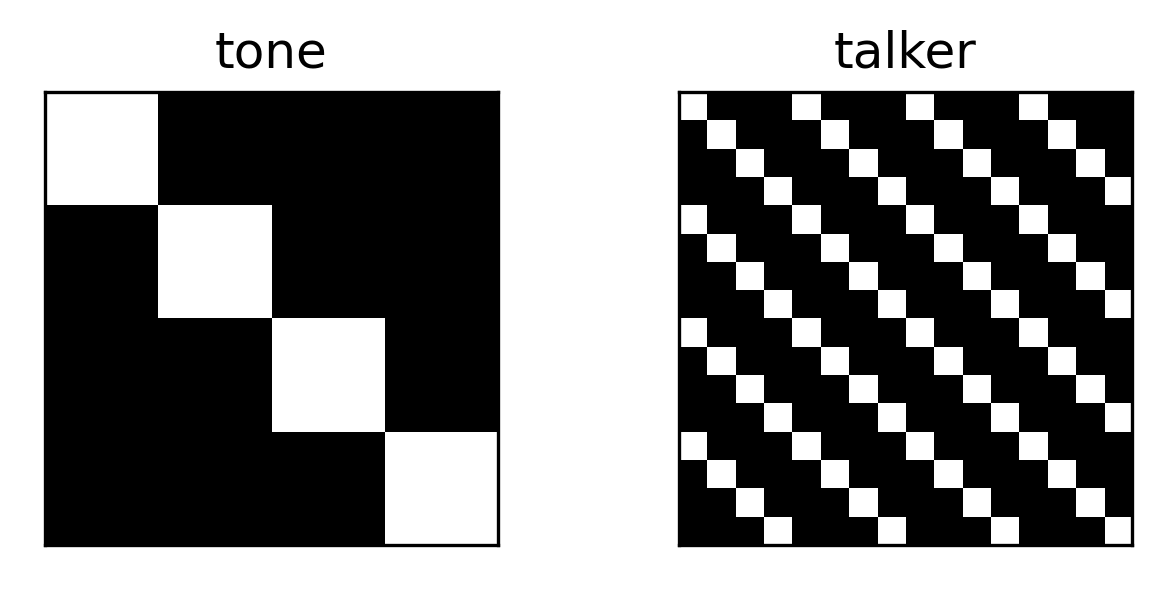

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(5,2), dpi=300)

#show_rdm_panel(ffr_rdm, ax=axs.flat[0], rdm_descriptor='FFR model', cmap='inferno',)
show_rdm_panel(tone_rdms, ax=axs.flat[0], rdm_descriptor='categorical_model', cmap='Greys',)
show_rdm_panel(talker_rdms, ax=axs.flat[1], rdm_descriptor='categorical_model', cmap='Greys',)


## Set up participants

In [15]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.)
ignore_subs = ['sub-FLT27', # always leave out FLT27 – did not participate
               'sub-FLT07', # bad QA 11/14/23 
               # 'sub-FLT02', # incorrect button press coding for run00
              ]
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index,
                     inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], 
                            ignore_index=True, 
                            inplace=True)

In [16]:
participants_df

,participant_id,age,sex,group,FFR_id
0,sub-FLT02,21,F,non-Mandarin,1002.0
1,sub-FLT03,25,F,Mandarin,2002.0
2,sub-FLT04,21,F,non-Mandarin,1003.0
3,sub-FLT05,26,M,Mandarin,3010.0
4,sub-FLT06,21,F,non-Mandarin,3001.0
5,sub-FLT08,23,F,Mandarin,2005.0
6,sub-FLT09,30,F,non-Mandarin,3002.0
7,sub-FLT10,23,F,Mandarin,2006.0
8,sub-FLT11,20,F,non-Mandarin,1005.0
9,sub-FLT12,20,F,non-Mandarin,3004.0


In [17]:
# create group-specific lists of subject IDs
sub_group_dict = {'Mandarin': list(participants_df.participant_id[participants_df.group=='Mandarin']),
                  'non-Mandarin': list(participants_df.participant_id[participants_df.group=='non-Mandarin'])}

In [18]:
sub_group_dict

{'Mandarin': ['sub-FLT03',
  'sub-FLT05',
  'sub-FLT08',
  'sub-FLT10',
  'sub-FLT15',
  'sub-FLT17',
  'sub-FLT18',
  'sub-FLT19',
  'sub-FLT21',
  'sub-FLT22',
  'sub-FLT23',
  'sub-FLT24',
  'sub-FLT26'],
 'non-Mandarin': ['sub-FLT02',
  'sub-FLT04',
  'sub-FLT06',
  'sub-FLT09',
  'sub-FLT11',
  'sub-FLT12',
  'sub-FLT13',
  'sub-FLT14',
  'sub-FLT20',
  'sub-FLT25',
  'sub-FLT28',
  'sub-FLT30']}

In [19]:
participant_list = participants_df.participant_id
participant_list = [p.split('-')[1] for p in participant_list]
group_assignment = participants_df.group

# Run with auditory cortical ROIs

## Define network ROIs

In [181]:
## define ROIs
network_name = 'auditory' # 'tian_subcortical_S3' # auditory

if network_name == 'auditory':
    roi_list_ordered = [
                #'L-IC', 'L-MGN', 
                'L-HG', 'L-PT',  'L-PP', 'L-STGp', 'L-STGa', 'L-ParsOp', 'L-ParsTri',
                #'R-IC', 'R-MGN', 
                'R-HG', 'R-PT',  'R-PP', 'R-STGp', 'R-STGa', 'R-ParsOp', 'R-ParsTri', 
               ]
elif network_name == 'aud-striatal':
    roi_list_ordered = ['L-Caud', 'L-Put', 'L-IC', 'L-MGN',
                'L-HG', 'L-PP', 'L-PT', 'L-STGa', 'L-STGp', 
                'L-ParsOp', 'L-ParsTri',
                'R-Caud', 'R-Put','R-IC', 'R-MGN',
                'R-HG', 'R-PP', 'R-PT', 'R-STGa', 'R-STGp', 
                'R-ParsOp', 'R-ParsTri',
               ]
elif network_name == 'tian_subcortical_S3':
    roi_list_ordered = [
        'CAU-DA-lh', 'CAU-DA-rh', 
        'CAU-VA-lh', 'CAU-VA-rh', 
        'pCAU-lh', 'pCAU-rh', 
        'PUT-DA-lh', 'PUT-DA-rh', 
        'PUT-DP-lh', 'PUT-DP-rh', 
        'PUT-VA-lh', 'PUT-VA-rh', 
        'PUT-VP-lh', 'PUT-VP-rh',
        #'aGP-lh', 'pGP-lh', 
        #'NAc-core-lh',  'NAc-core-rh', 
        #'NAc-shell-lh', 'NAc-shell-rh', 
         #'aGP-rh', 'pGP-rh',         
               ]
    


## Load run-specific subject-specific RDMs

In [182]:
# from `rsa_roi.py`-generated outputs
group_rdm_list = []
for sx, sub_id in enumerate(participant_list):
    print(sub_id)
    group_id = group_assignment[sx]

    out_dir = os.path.join(model_dir, 'rsa_roi', network_name)
    sub_fpath = os.path.join(out_dir,
                         f'sub-{sub_id}_{network_name}_{model_desc}_rdms.hdf5')
    sub_rdm = rsatoolbox.rdm.rdms.load_rdm(sub_fpath)
    
    # add the group descriptor to the subject's RDM
    sub_rdm.rdm_descriptors['group'] = [group_id for x in sub_rdm.rdm_descriptors['index']]
    group_rdm_list.append(sub_rdm)
auditory_rdms = rsatoolbox.rdm.rdms.concat(group_rdm_list).subset('group', value='non-Mandarin')

FLT02
FLT03
FLT04
FLT05
FLT06
FLT08
FLT09
FLT10
FLT11
FLT12
FLT13
FLT14
FLT15
FLT17
FLT18
FLT19
FLT20
FLT21
FLT22
FLT23
FLT24
FLT25
FLT26
FLT28
FLT30


### Per "stage" (runcombo), per subject

In [183]:
runcombo_dict = {'early': ['run00', 'run01'], 
                 'middle': ['run02', 'run03'], 
                 'final': ['run04','run05']}

### Participant-specific across-model comparisons

In [184]:
group_dict = {}

for group_id in np.unique(auditory_rdms.rdm_descriptors['group']):

    for full_sub_id in sub_group_dict[group_id]:
        sub_id = full_sub_id[4:]
        try:
            ffr_id = str(int(participants_df[participants_df['participant_id'] == full_sub_id]['FFR_id'].values[0]))
            print(f'{sub_id} | ffr_id: {ffr_id}')
        except ValueError:
            print(f'no ffr_id for {sub_id}')
            continue

        sub_dict = {}

        for runcombo in runcombo_dict:
            # initialize results list
            runcombo_roi_res_dict = {}

            for ROI in roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
                print(f'{sub_id} runcombo-{runcombo} ROI-{ROI}')
                runs = runcombo_dict[runcombo]

                results_grr = rsatoolbox.inference.eval_fixed(cat_models, 
                                                              auditory_rdms.subset('participant', value=sub_id).subset('run',value=runs).subset('ROI',value=ROI),  
                                                              method='corr',)
                #print(f'p-value vs. 0: {results_grr.test_zero()[0]:.04f}')
                runcombo_roi_res_dict[ROI] = results_grr.get_means()#[0]
                #runcombo_roi_res_dict[ROI] = results_grr

            sub_dict[runcombo] = runcombo_roi_res_dict

        #except:
        #    print(f'no FFR data for {sub_id}')
        group_dict[sub_id] = sub_dict

FLT02 | ffr_id: 1002
FLT02 runcombo-early ROI-L-HG
FLT02 runcombo-early ROI-L-PT
FLT02 runcombo-early ROI-L-PP
FLT02 runcombo-early ROI-L-STGp
FLT02 runcombo-early ROI-L-STGa
FLT02 runcombo-early ROI-L-ParsOp
FLT02 runcombo-early ROI-L-ParsTri
FLT02 runcombo-early ROI-R-HG
FLT02 runcombo-early ROI-R-PT
FLT02 runcombo-early ROI-R-PP
FLT02 runcombo-early ROI-R-STGp
FLT02 runcombo-early ROI-R-STGa
FLT02 runcombo-early ROI-R-ParsOp
FLT02 runcombo-early ROI-R-ParsTri
FLT02 runcombo-middle ROI-L-HG
FLT02 runcombo-middle ROI-L-PT
FLT02 runcombo-middle ROI-L-PP
FLT02 runcombo-middle ROI-L-STGp
FLT02 runcombo-middle ROI-L-STGa
FLT02 runcombo-middle ROI-L-ParsOp
FLT02 runcombo-middle ROI-L-ParsTri
FLT02 runcombo-middle ROI-R-HG
FLT02 runcombo-middle ROI-R-PT
FLT02 runcombo-middle ROI-R-PP
FLT02 runcombo-middle ROI-R-STGp
FLT02 runcombo-middle ROI-R-STGa
FLT02 runcombo-middle ROI-R-ParsOp
FLT02 runcombo-middle ROI-R-ParsTri
FLT02 runcombo-final ROI-L-HG
FLT02 runcombo-final ROI-L-PT
FLT02 runcomb

In [185]:
print(results_grr)

Results for running fixed evaluation for corr on 2 models:

Model  |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------
Tone   |  0.008 ± 0.022 |        0.394  |         0.193  |
Talker | -0.055 ± 0.040 |        0.799  |         0.185  |

p-values are based on uncorrected t-tests


## Turn into models

In [186]:
run_list = [f'run{x:02}' for x in range(6)]

In [187]:
auditory_rdms.rdm_descriptors.keys()

dict_keys(['ROI', 'index', 'participant', 'run', 'group'])

### Mean RDMs per ROI and run

In [188]:
mean_rdms_nman_list = []
for runx, run in enumerate(run_list):
    for rx, roi in enumerate(roi_list_ordered):
        dissim_nman = auditory_rdms.subset('group', value='non-Mandarin').subset('ROI', value=roi).dissimilarities
        roi_nman = RDMs(dissim_nman.mean(axis=0),
                        rdm_descriptors={'ROI': roi_list_ordered[rx],
                                         'run': run},
                        pattern_descriptors=pattern_descriptors)
        mean_rdms_nman_list.append(roi_nman)

mean_rdms_nman = rsatoolbox.rdm.rdms.concat(mean_rdms_nman_list)



In [189]:
mean_rdms_nman

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
None
dissimilarities = 
[[2.23743876 2.34689609 2.18650173 ... 2.17850936 2.15031954 2.18287416]
 [2.24696129 2.37699616 2.27383488 ... 2.23607403 2.25428628 2.25215078]
 [2.20619628 2.32489295 2.18038944 ... 2.27401734 2.20582302 2.2665683 ]
 ...
 [2.0329463  2.04790876 1.93656288 ... 2.05481222 2.05257865 2.01457251]
 [2.08101533 2.11458094 2.10682755 ... 2.09676269 2.1098589  2.16875028]
 [2.03465671 2.16472333 2.05777247 ... 2.08370621 2.14886031 2.11447075]]
descriptors = 
{}
rdm_descriptors = 
{'ROI': ['L-HG', 'L-PT', 'L-PP', 'L-STGp', 'L-STGa', 'L-ParsOp', 'L-ParsTri', 'R-HG', 'R-PT', 'R-PP', 'R-STGp', 'R-STGa', 'R-ParsOp', 'R-ParsTri', 'L-HG', 'L-PT', 'L-PP', 'L-STGp', 'L-STGa', 'L-ParsOp', 'L-ParsTri', 'R-HG', 'R-PT', 'R-PP', 'R-STGp', 'R-STGa', 'R-ParsOp', 'R-ParsTri', 'L-HG', 'L-PT', 'L-PP', 'L-STGp', 'L-STGa', 'L-ParsOp', 'L-ParsTri', 'R-HG', 'R-PT', 'R-PP', 'R-STGp', 'R-STGa', 'R-ParsOp', 'R-ParsTri', 'L-HG', 'L-PT', 'L-PP', 'L

In [190]:
auditory_models_dict = {}

for runx, run in enumerate(run_list): 
    auditory_models_dict[run] = [ModelFixed(x, rdm=mean_rdms_nman.subset('ROI',value=x).subset('run', value=run)) for x in np.unique(mean_rdms_nman.rdm_descriptors['ROI'])]


In [191]:
auditory_models_dict[run]

### Mean RDMs per run only

In [192]:
mean_rdms_run_list = []
for runx, run in enumerate(run_list):
        dissim_run_nman = auditory_rdms.subset('group', value='non-Mandarin').dissimilarities
        run_nman = RDMs(dissim_nman.mean(axis=0),
                        rdm_descriptors={
                                         #'ROI': roi_list_ordered[rx],
                                         'run': run},
                        pattern_descriptors=pattern_descriptors)
        mean_rdms_run_list.append(run_nman)

mean_rdms_run = rsatoolbox.rdm.rdms.concat(mean_rdms_run_list)



In [193]:
mean_rdms_run

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
None
dissimilarities = 
[[2.03465671 2.16472333 2.05777247 2.15233043 2.1430756  2.21569035
  2.2773303  2.28224638 2.28980634 2.31093683 2.24031052 2.28576185
  2.06669448 2.07628629 2.13137517 2.13757789 2.08222271 2.12484232
  2.19930685 2.22271756 2.17328526 2.168658   2.2746128  2.27210929
  2.17895551 2.1512333  2.1112456  2.12621867 2.05153388 2.05424821
  2.23744099 2.15009505 2.06040638 2.26552159 2.17480179 2.2345632
  2.17996154 2.21545979 2.16061513 2.07357988 2.16477587 2.09288653
  2.2090117  2.08141072 2.25093611 2.18101971 2.17814732 2.25708799
  2.3255555  2.16110585 2.17875881 2.16801793 2.16260287 2.17804686
  2.14363221 2.14132226 2.15700648 2.12669643 2.39377879 2.35225354
  2.26851033 2.17393291 2.0670405  2.13212032 2.30123384 2.13476152
  2.09295001 2.14384805 2.27343974 2.20842269 2.23481389 2.15599264
  2.15700518 2.12741811 2.19065344 2.16740738 2.1917924  2.38989095
  2.34010937 2.35387315 2.26215638 2.16102498 2

In [194]:
auditory_single_model_dict = {}

for runx, run in enumerate(run_list): 
    auditory_single_model_dict[run] = ModelFixed(f'Auditory {run} RDM', rdm=mean_rdms_run.subset('run', run))


In [195]:
auditory_single_model_dict

{'run00': <rsatoolbox.model.model.ModelFixed at 0x7f1dc19560d0>,
 'run01': <rsatoolbox.model.model.ModelFixed at 0x7f1dc0ce2130>,
 'run02': <rsatoolbox.model.model.ModelFixed at 0x7f1dc0ce22e0>,
 'run03': <rsatoolbox.model.model.ModelFixed at 0x7f1dc0ce2e20>,
 'run04': <rsatoolbox.model.model.ModelFixed at 0x7f1dc25a0f70>,
 'run05': <rsatoolbox.model.model.ModelFixed at 0x7f1dc25a0580>}

In [196]:
auditory_runcombo_models_dict = {}

for runx, runcombo in enumerate(runcombo_dict): 
    runs = runcombo_dict[runcombo]
    auditory_runcombo_models_dict[runcombo] = ModelFixed(f'auditory {run} RDM', 
                                                         rdm=mean_rdms_run.subset('run', runs).mean())


In [199]:
auditory_runcombo_models_dict['early'].rdm_obj

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
None
dissimilarities = 
[[2.03465671 2.16472333 2.05777247 2.15233043 2.1430756  2.21569035
  2.2773303  2.28224638 2.28980634 2.31093683 2.24031052 2.28576185
  2.06669448 2.07628629 2.13137517 2.13757789 2.08222271 2.12484232
  2.19930685 2.22271756 2.17328526 2.168658   2.2746128  2.27210929
  2.17895551 2.1512333  2.1112456  2.12621867 2.05153388 2.05424821
  2.23744099 2.15009505 2.06040638 2.26552159 2.17480179 2.2345632
  2.17996154 2.21545979 2.16061513 2.07357988 2.16477587 2.09288653
  2.2090117  2.08141072 2.25093611 2.18101971 2.17814732 2.25708799
  2.3255555  2.16110585 2.17875881 2.16801793 2.16260287 2.17804686
  2.14363221 2.14132226 2.15700648 2.12669643 2.39377879 2.35225354
  2.26851033 2.17393291 2.0670405  2.13212032 2.30123384 2.13476152
  2.09295001 2.14384805 2.27343974 2.20842269 2.23481389 2.15599264
  2.15700518 2.12741811 2.19065344 2.16740738 2.1917924  2.38989095
  2.34010937 2.35387315 2.26215638 2.16102498 2

# Run with striatal ROIs

## Define network ROIs

In [200]:
## define ROIs
network_name = 'tian_subcortical_S3'

if network_name == 'auditory':
    roi_list_ordered = [
                #'L-IC', 'L-MGN', 
                'L-HG', 'L-PT',  'L-PP', 'L-STGp', 'L-STGa', 'L-ParsOp', 'L-ParsTri',
                #'R-IC', 'R-MGN', 
                'R-HG', 'R-PT',  'R-PP', 'R-STGp', 'R-STGa', 'R-ParsOp', 'R-ParsTri', 
               ]
elif network_name == 'aud-striatal':
    roi_list_ordered = ['L-Caud', 'L-Put', 'L-IC', 'L-MGN',
                'L-HG', 'L-PP', 'L-PT', 'L-STGa', 'L-STGp', 
                'L-ParsOp', 'L-ParsTri',
                'R-Caud', 'R-Put','R-IC', 'R-MGN',
                'R-HG', 'R-PP', 'R-PT', 'R-STGa', 'R-STGp', 
                'R-ParsOp', 'R-ParsTri',
               ]
elif network_name == 'tian_subcortical_S3':
    roi_list_ordered = [
        'CAU-DA-lh', 'CAU-DA-rh', 
        'CAU-VA-lh', 'CAU-VA-rh', 
        'pCAU-lh', 'pCAU-rh', 
        'PUT-DA-lh', 'PUT-DA-rh', 
        'PUT-DP-lh', 'PUT-DP-rh', 
        'PUT-VA-lh', 'PUT-VA-rh', 
        'PUT-VP-lh', 'PUT-VP-rh',
        #'aGP-lh', 'pGP-lh', 
        #'NAc-core-lh',  'NAc-core-rh', 
        #'NAc-shell-lh', 'NAc-shell-rh', 
         #'aGP-rh', 'pGP-rh',         
               ]
    


## Load run-specific subject-specific RDMs

In [201]:
# from `rsa_roi.py`-generated outputs
group_rdm_list = []
for sx, sub_id in enumerate(participant_list):
    print(sub_id)
    group_id = group_assignment[sx]

    out_dir = os.path.join(model_dir, 'rsa_roi', network_name)
    sub_fpath = os.path.join(out_dir,
                         f'sub-{sub_id}_{network_name}_{model_desc}_rdms.hdf5')
    sub_rdm = rsatoolbox.rdm.rdms.load_rdm(sub_fpath)
    
    # add the group descriptor to the subject's RDM
    sub_rdm.rdm_descriptors['group'] = [group_id for x in sub_rdm.rdm_descriptors['index']]
    group_rdm_list.append(sub_rdm)
striatal_rdms = rsatoolbox.rdm.rdms.concat(group_rdm_list).subset('group', value='non-Mandarin')
striatal_rdms = striatal_rdms.subset('ROI', value=roi_list_ordered)

FLT02
FLT03
FLT04
FLT05
FLT06
FLT08
FLT09
FLT10
FLT11
FLT12
FLT13
FLT14
FLT15
FLT17
FLT18
FLT19
FLT20
FLT21
FLT22
FLT23
FLT24
FLT25
FLT26
FLT28
FLT30


In [202]:
sorted(np.unique(striatal_rdms.rdm_descriptors['ROI']))

['CAU-DA-lh',
 'CAU-DA-rh',
 'CAU-VA-lh',
 'CAU-VA-rh',
 'PUT-DA-lh',
 'PUT-DA-rh',
 'PUT-DP-lh',
 'PUT-DP-rh',
 'PUT-VA-lh',
 'PUT-VA-rh',
 'PUT-VP-lh',
 'PUT-VP-rh',
 'pCAU-lh',
 'pCAU-rh']

### Per "stage" (runcombo), per subject

In [203]:
runcombo_dict = {'early': ['run00', 'run01'], 
                 'middle': ['run02', 'run03'], 
                 'final': ['run04','run05']}

### Participant-specific across-model comparisons

In [204]:
group_dict = {}

for group_id in np.unique(striatal_rdms.rdm_descriptors['group']):

    for full_sub_id in sub_group_dict[group_id]:
        sub_id = full_sub_id[4:]
        try:
            ffr_id = str(int(participants_df[participants_df['participant_id'] == full_sub_id]['FFR_id'].values[0]))
            print(f'{sub_id} | ffr_id: {ffr_id}')
        except ValueError:
            print(f'no ffr_id for {sub_id}')
            continue

        sub_dict = {}

        for runcombo in runcombo_dict:
            # initialize results list
            runcombo_roi_res_dict = {}

            for ROI in roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
                print(f'{sub_id} runcombo-{runcombo} ROI-{ROI}')
                runs = runcombo_dict[runcombo]

                results_grr = rsatoolbox.inference.eval_fixed(cat_models, #all_models, 
                                                              striatal_rdms.subset('participant', value=sub_id).subset('run',value=runs).subset('ROI',value=ROI),  
                                                              method='corr',)
                #print(f'p-value vs. 0: {results_grr.test_zero()[0]:.04f}')
                runcombo_roi_res_dict[ROI] = results_grr.get_means()#[0]
                #runcombo_roi_res_dict[ROI] = results_grr

            sub_dict[runcombo] = runcombo_roi_res_dict

        #except:
        #    print(f'no FFR data for {sub_id}')
        group_dict[sub_id] = sub_dict

FLT02 | ffr_id: 1002
FLT02 runcombo-early ROI-CAU-DA-lh
FLT02 runcombo-early ROI-CAU-DA-rh
FLT02 runcombo-early ROI-CAU-VA-lh
FLT02 runcombo-early ROI-CAU-VA-rh
FLT02 runcombo-early ROI-pCAU-lh
FLT02 runcombo-early ROI-pCAU-rh
FLT02 runcombo-early ROI-PUT-DA-lh
FLT02 runcombo-early ROI-PUT-DA-rh
FLT02 runcombo-early ROI-PUT-DP-lh
FLT02 runcombo-early ROI-PUT-DP-rh
FLT02 runcombo-early ROI-PUT-VA-lh
FLT02 runcombo-early ROI-PUT-VA-rh
FLT02 runcombo-early ROI-PUT-VP-lh
FLT02 runcombo-early ROI-PUT-VP-rh
FLT02 runcombo-middle ROI-CAU-DA-lh
FLT02 runcombo-middle ROI-CAU-DA-rh
FLT02 runcombo-middle ROI-CAU-VA-lh
FLT02 runcombo-middle ROI-CAU-VA-rh
FLT02 runcombo-middle ROI-pCAU-lh
FLT02 runcombo-middle ROI-pCAU-rh
FLT02 runcombo-middle ROI-PUT-DA-lh
FLT02 runcombo-middle ROI-PUT-DA-rh
FLT02 runcombo-middle ROI-PUT-DP-lh
FLT02 runcombo-middle ROI-PUT-DP-rh
FLT02 runcombo-middle ROI-PUT-VA-lh
FLT02 runcombo-middle ROI-PUT-VA-rh
FLT02 runcombo-middle ROI-PUT-VP-lh
FLT02 runcombo-middle ROI-PUT

In [205]:
print(results_grr)

Results for running fixed evaluation for corr on 2 models:

Model  |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------
Tone   |  0.024 ± 0.051 |        0.358  |         0.772  |
Talker | -0.031 ± 0.036 |        0.728  |         0.493  |

p-values are based on uncorrected t-tests


## Turn into models

In [206]:
striatal_rdms.rdm_descriptors.keys()

dict_keys(['ROI', 'index', 'participant', 'run', 'group'])

### Mean RDM per ROI and run

In [207]:
run_list = [f'run{x:02}' for x in range(6)]

In [208]:
mean_rdms_nman_list = []
for runx, run in enumerate(run_list):
    for rx, roi in enumerate(roi_list_ordered):
        dissim_nman = striatal_rdms.subset('ROI', value=roi).dissimilarities
        roi_nman = RDMs(dissim_nman.mean(axis=0),
                        rdm_descriptors={'ROI': roi_list_ordered[rx],
                                         'run': run},
                        pattern_descriptors=pattern_descriptors)
        mean_rdms_nman_list.append(roi_nman)

mean_rdms_nman = rsatoolbox.rdm.rdms.concat(mean_rdms_nman_list)



In [209]:
mean_rdms_nman

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
None
dissimilarities = 
[[2.28740161 2.38979498 2.12222979 ... 2.38379818 2.20930735 2.41275817]
 [2.29953145 2.39733196 2.18383926 ... 2.27810638 2.2244644  2.37108426]
 [2.48720218 2.38690949 2.29919335 ... 2.2677142  2.08340702 2.26633042]
 ...
 [1.9837027  2.14212401 2.09671518 ... 2.09496774 2.04946465 2.11105679]
 [2.08718565 2.15924345 2.13823814 ... 2.20330173 2.1785818  2.28195512]
 [2.316992   2.35559342 2.22537026 ... 2.28796706 2.17024717 2.34830318]]
descriptors = 
{}
rdm_descriptors = 
{'ROI': ['CAU-DA-lh', 'CAU-DA-rh', 'CAU-VA-lh', 'CAU-VA-rh', 'pCAU-lh', 'pCAU-rh', 'PUT-DA-lh', 'PUT-DA-rh', 'PUT-DP-lh', 'PUT-DP-rh', 'PUT-VA-lh', 'PUT-VA-rh', 'PUT-VP-lh', 'PUT-VP-rh', 'CAU-DA-lh', 'CAU-DA-rh', 'CAU-VA-lh', 'CAU-VA-rh', 'pCAU-lh', 'pCAU-rh', 'PUT-DA-lh', 'PUT-DA-rh', 'PUT-DP-lh', 'PUT-DP-rh', 'PUT-VA-lh', 'PUT-VA-rh', 'PUT-VP-lh', 'PUT-VP-rh', 'CAU-DA-lh', 'CAU-DA-rh', 'CAU-VA-lh', 'CAU-VA-rh', 'pCAU-lh', 'pCAU-rh', 'PUT-DA-lh

In [210]:
striatal_models_dict = {}

for runx, run in enumerate(run_list): 
    striatal_models_dict[run] = [ModelFixed(x, rdm=mean_rdms_nman.subset('ROI',value=x).subset('run', value=run)) for x in np.unique(mean_rdms_nman.rdm_descriptors['ROI'])]


In [211]:
striatal_models_dict[run]

In [212]:
striatal_single_model_dict = {}

for runx, run in enumerate(run_list): 
    striatal_single_model_dict[run] = ModelFixed(f'Striatal {run} RDM', rdm=mean_rdms_nman)


### Mean RDMs per run only

In [213]:
mean_rdms_run_list = []
for runx, run in enumerate(run_list):
        dissim_run_nman = striatal_rdms.subset('group', value='non-Mandarin').dissimilarities
        run_nman = RDMs(dissim_nman.mean(axis=0),
                        rdm_descriptors={
                                         #'ROI': roi_list_ordered[rx],
                                         'run': run},
                        pattern_descriptors=pattern_descriptors)
        mean_rdms_run_list.append(run_nman)

mean_rdms_run = rsatoolbox.rdm.rdms.concat(mean_rdms_run_list)

In [214]:
mean_rdms_run

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
None
dissimilarities = 
[[2.316992   2.35559342 2.22537026 2.38471622 2.4046466  2.27413867
  2.34212164 2.53757337 2.47528553 2.28135066 2.4053878  2.42834392
  2.26239027 2.43194262 2.36669902 2.1482415  2.24935794 2.20872625
  2.30973574 2.30160422 2.21029001 2.37379915 2.31030476 2.21987752
  2.23734919 2.17937849 2.22763405 2.36088743 2.20605564 2.1326642
  2.19540561 2.25332811 2.19880122 2.23435607 2.30445807 2.24259692
  2.1717104  2.23657421 2.27438724 2.1439763  2.21793059 2.09102422
  2.34585053 2.20243473 2.33602482 2.28235476 2.34868436 2.32390509
  2.32775462 2.30819367 2.24906941 2.36355765 2.39732281 2.30597776
  2.26465629 2.24118728 2.23993768 2.31234572 2.28526371 2.30066258
  2.20218799 2.28701332 2.13587877 2.24538673 2.22417185 2.25373147
  2.17539872 2.30753192 2.32580626 2.25449454 2.23520717 2.30816019
  2.34162947 2.27258054 2.19122425 2.17624386 2.35889247 2.32901109
  2.31591487 2.36209981 2.30560178 2.30369284 2

In [215]:
striatal_single_model_dict = {}

for runx, run in enumerate(run_list): 
    striatal_single_model_dict[run] = ModelFixed(f'striatal {run} RDM', rdm=mean_rdms_run.subset('run', run))


In [216]:
striatal_single_model_dict

{'run00': <rsatoolbox.model.model.ModelFixed at 0x7f1dc263d610>,
 'run01': <rsatoolbox.model.model.ModelFixed at 0x7f1dc263d160>,
 'run02': <rsatoolbox.model.model.ModelFixed at 0x7f1dc263d5e0>,
 'run03': <rsatoolbox.model.model.ModelFixed at 0x7f1dc2656d00>,
 'run04': <rsatoolbox.model.model.ModelFixed at 0x7f1dc2656be0>,
 'run05': <rsatoolbox.model.model.ModelFixed at 0x7f1dc26565b0>}

In [217]:
striatal_runcombo_models_dict = {}

for runx, runcombo in enumerate(runcombo_dict): 
    runs = runcombo_dict[runcombo]
    striatal_runcombo_models_dict[runcombo] = ModelFixed(f'striatal {run} RDM', rdm=mean_rdms_run.subset('run', runs).mean())


In [218]:
striatal_runcombo_models_dict

{'early': <rsatoolbox.model.model.ModelFixed at 0x7f1dc17770a0>,
 'middle': <rsatoolbox.model.model.ModelFixed at 0x7f1dc2656040>,
 'final': <rsatoolbox.model.model.ModelFixed at 0x7f1dbf06d070>}

# Compare


early
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
auditory run05 RDM |  0.022 ± 0.009 |        0.006  |       < 0.001  |

p-values are based on uncorrected t-tests

middle
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
auditory run05 RDM |  0.078 ± 0.008 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests

final
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
auditory run05 RDM |  0.056 ± 0.010 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests


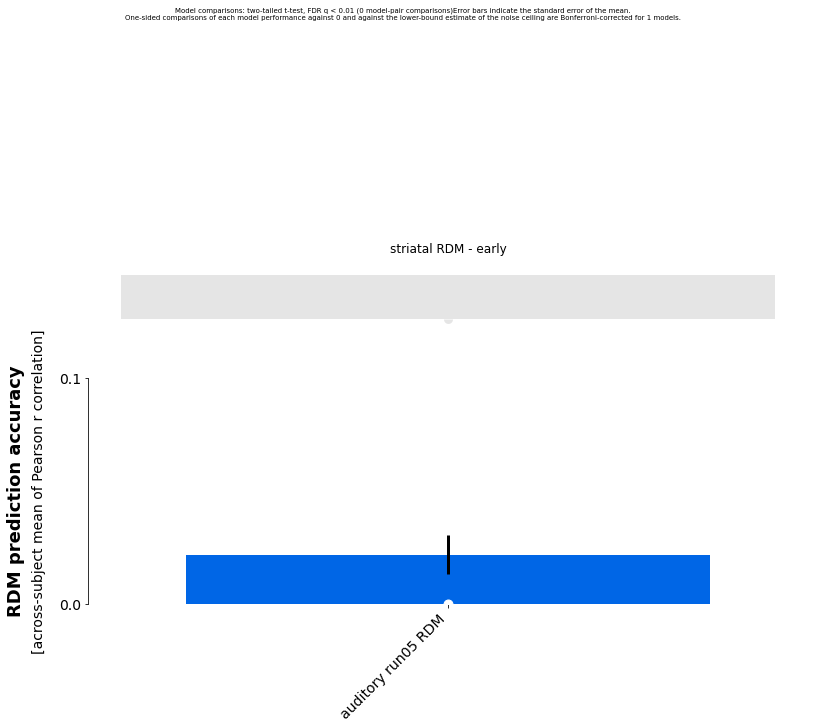

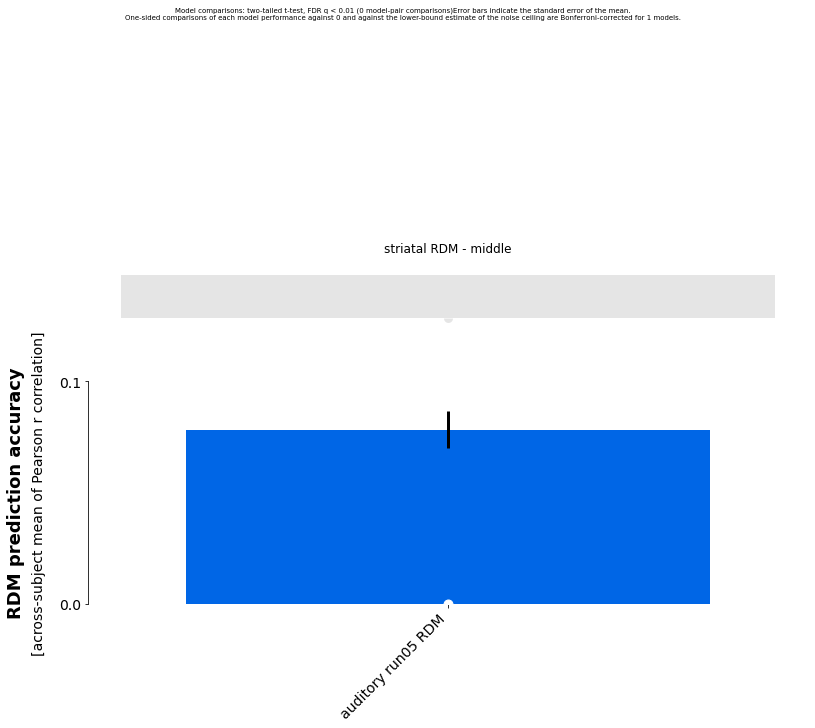

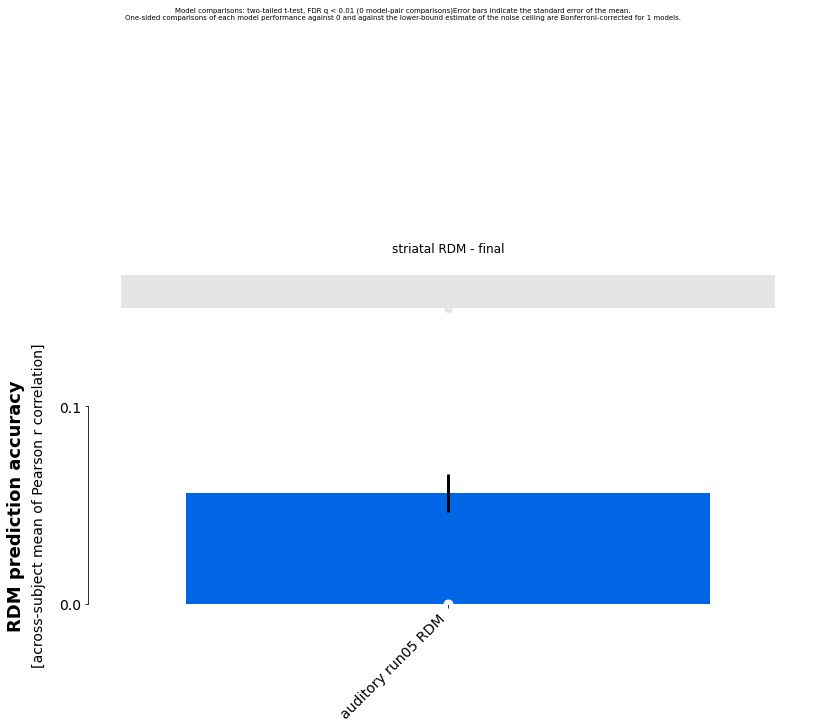

In [223]:
for runx, runcombo in enumerate(runcombo_dict): 
    runs = runcombo_dict[runcombo]
    print(f'\n{runcombo}')
    results_grr = rsatoolbox.inference.eval_fixed(auditory_runcombo_models_dict[runcombo], 
                                                  striatal_rdms.subset('run', value=runs),  
                                                  method='corr',
                                                 )
    print(results_grr)
    
    fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr,
                                                         test_pair_comparisons='nili', #'nili', False
                                                        );
    ax1.set_title(f'striatal RDM - {runcombo}');
    ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")


early
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
striatal run05 RDM |  0.054 ± 0.007 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests

middle
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
striatal run05 RDM |  0.028 ± 0.007 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests

final
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
striatal run05 RDM |  0.075 ± 0.008 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests


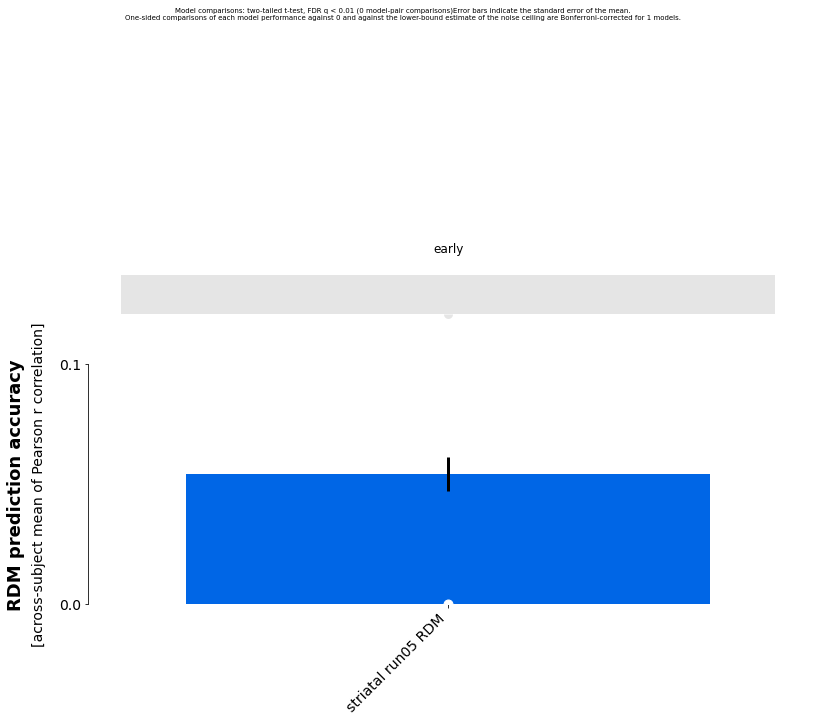

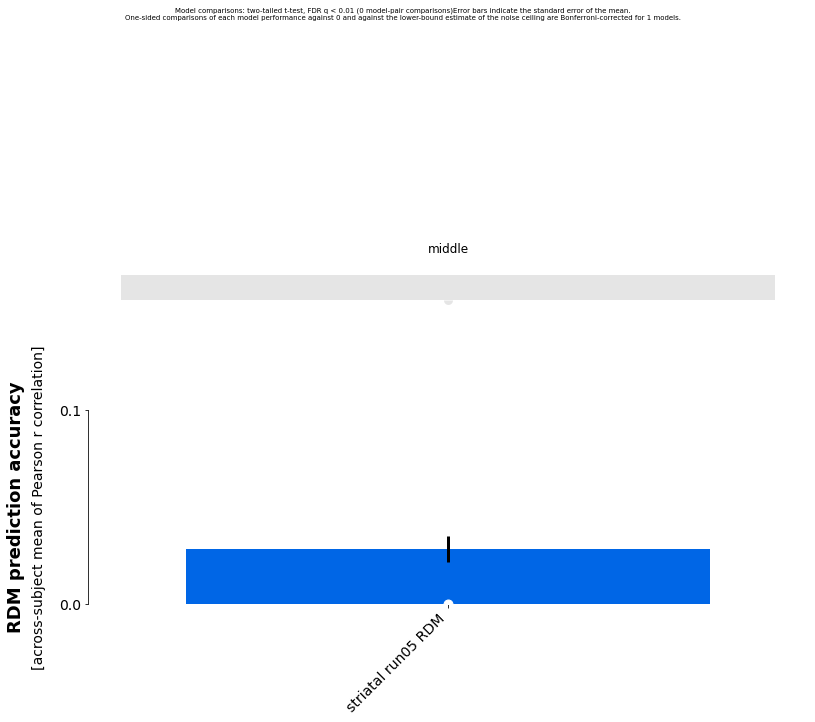

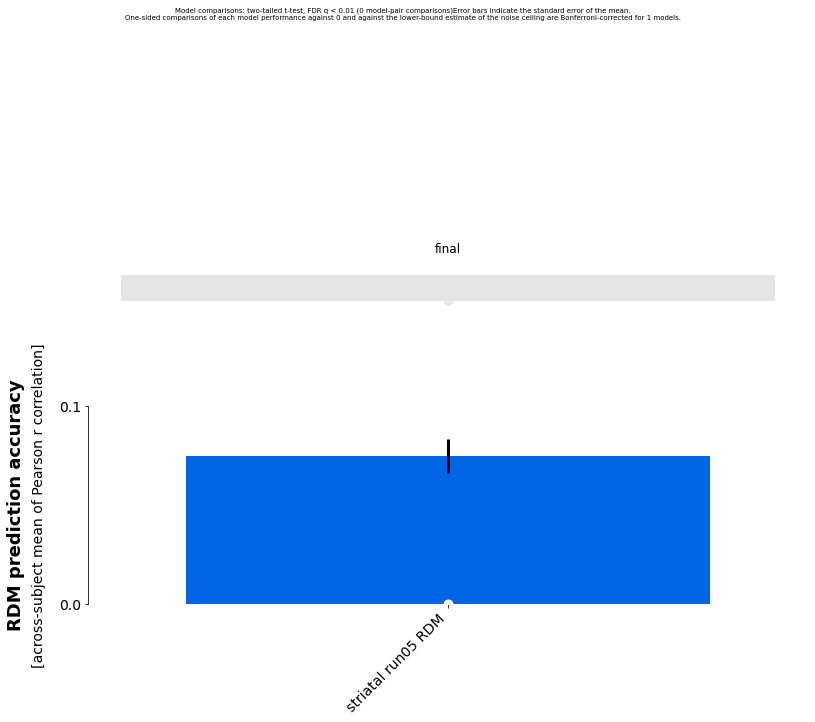

In [222]:
for runx, runcombo in enumerate(runcombo_dict): 
    runs = runcombo_dict[runcombo]
    print(f'\n{runcombo}')
    results_grr = rsatoolbox.inference.eval_fixed(striatal_runcombo_models_dict[runcombo], 
                                                  auditory_rdms.subset('run', value=runs),  
                                                  method='corr',
                                                 )
    print(results_grr)
    
    fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr,
                                                         test_pair_comparisons='nili', #'nili', False
                                                        );
    ax1.set_title(f'{runcombo}');
    ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")

#### All cortex vs. all striatum

run00
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
Auditory run00 RDM |  0.044 ± 0.013 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests
run01
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
Auditory run01 RDM | -0.000 ± 0.011 |        0.515  |       < 0.001  |

p-values are based on uncorrected t-tests
run02
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
Auditory run02 RDM |  0.119 ± 0.011 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests
run03
Results for running fixed ev

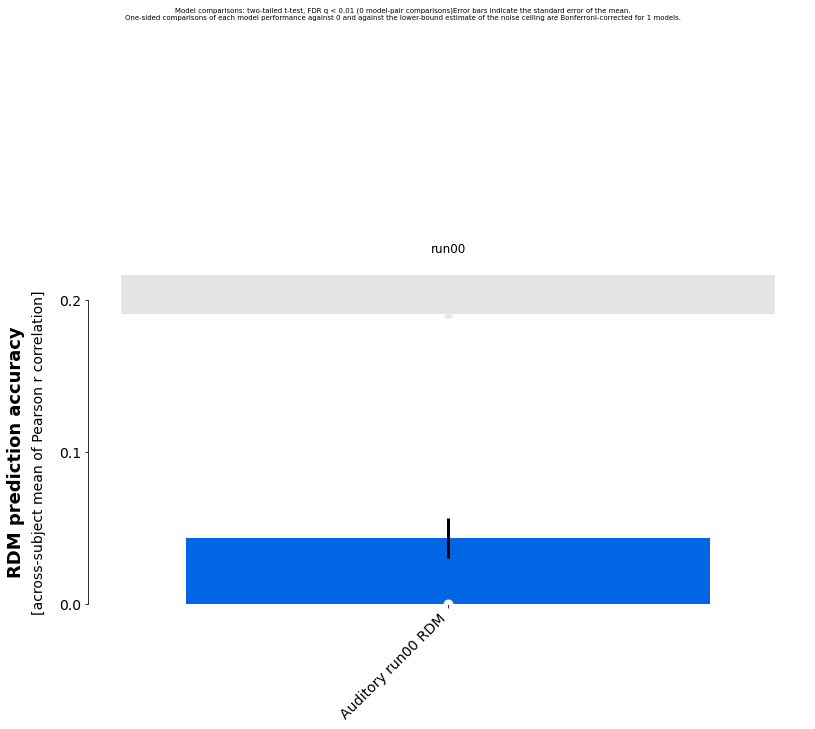

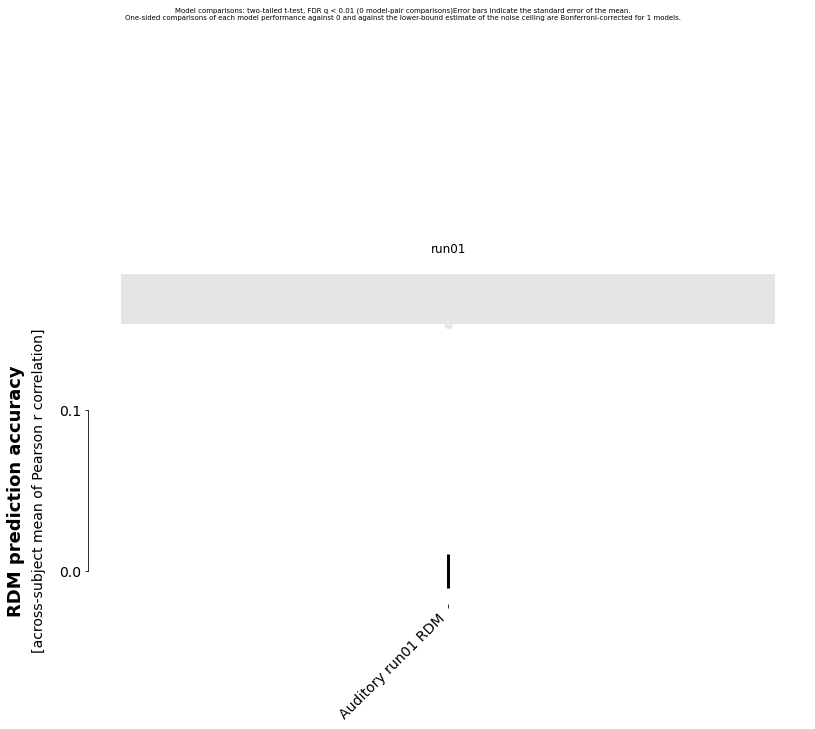

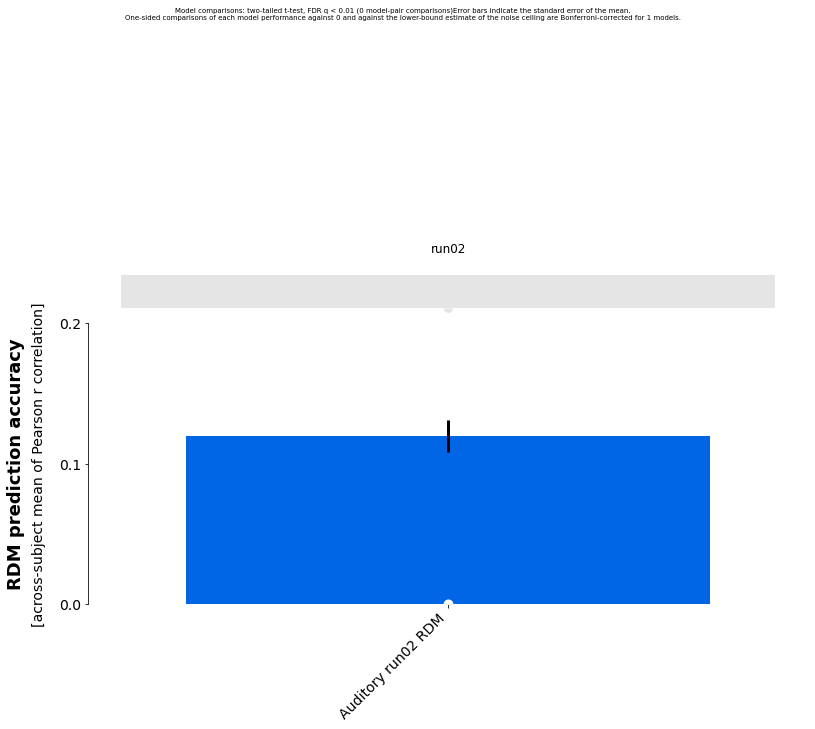

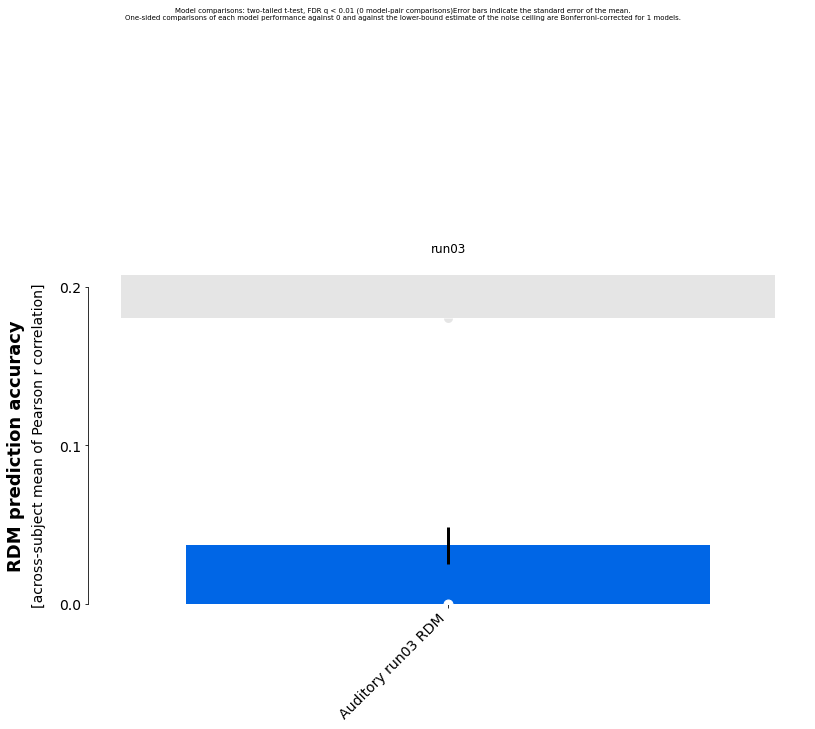

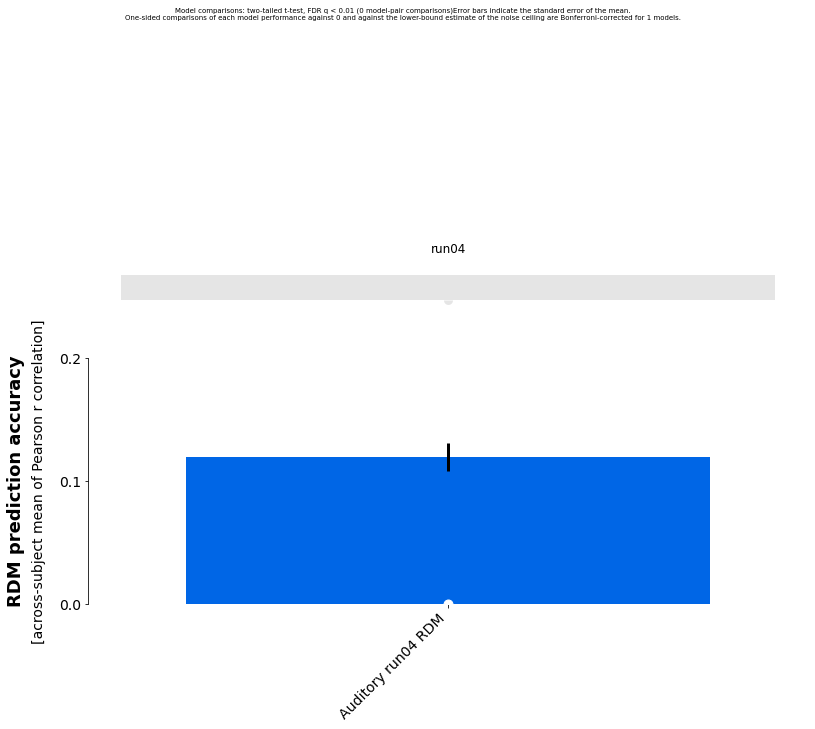

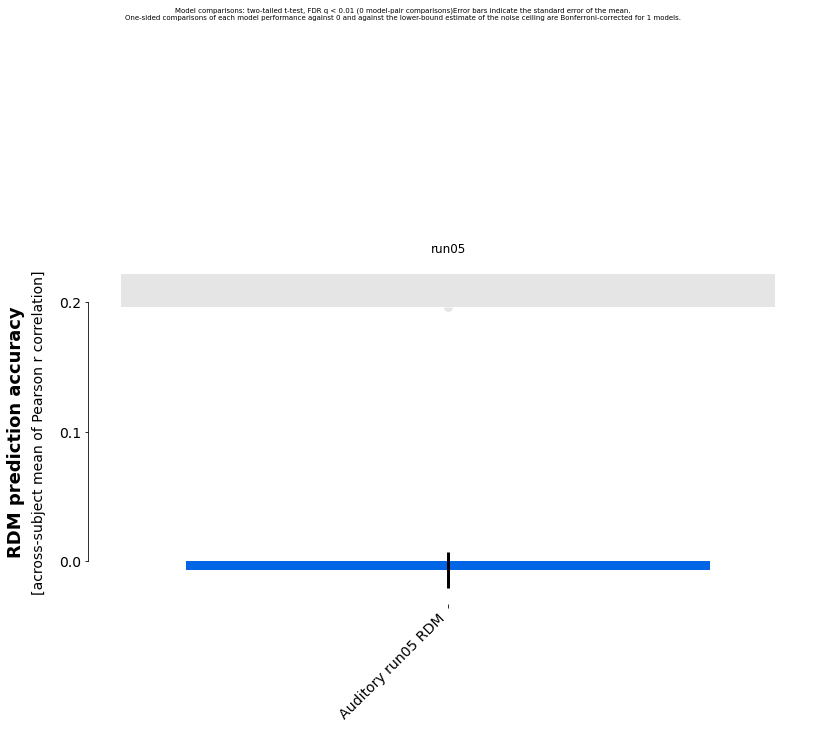

In [134]:
for runx, run in enumerate(run_list): 

    print(f'{run}')
    results_grr = rsatoolbox.inference.eval_fixed(auditory_single_model_dict[run], 
                                                  striatal_rdms.subset('run', value=run),  
                                                  method='corr',
                                                 )
    print(results_grr)
    
    fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr,
                                                         test_pair_comparisons='nili', #'nili', False
                                                        );
    ax1.set_title(f'{run}');
    ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")

#### All striatum vs. all cortex

run00
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
striatal run00 RDM |  0.075 ± 0.010 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests
run01
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
striatal run01 RDM |  0.034 ± 0.009 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests
run02
Results for running fixed evaluation for corr on 1 models:

Model              |   Eval ± SEM   | p (against 0) | p (against NC) |
----------------------------------------------------------------------
striatal run02 RDM |  0.061 ± 0.009 |      < 0.001  |       < 0.001  |

p-values are based on uncorrected t-tests
run03
Results for running fixed ev

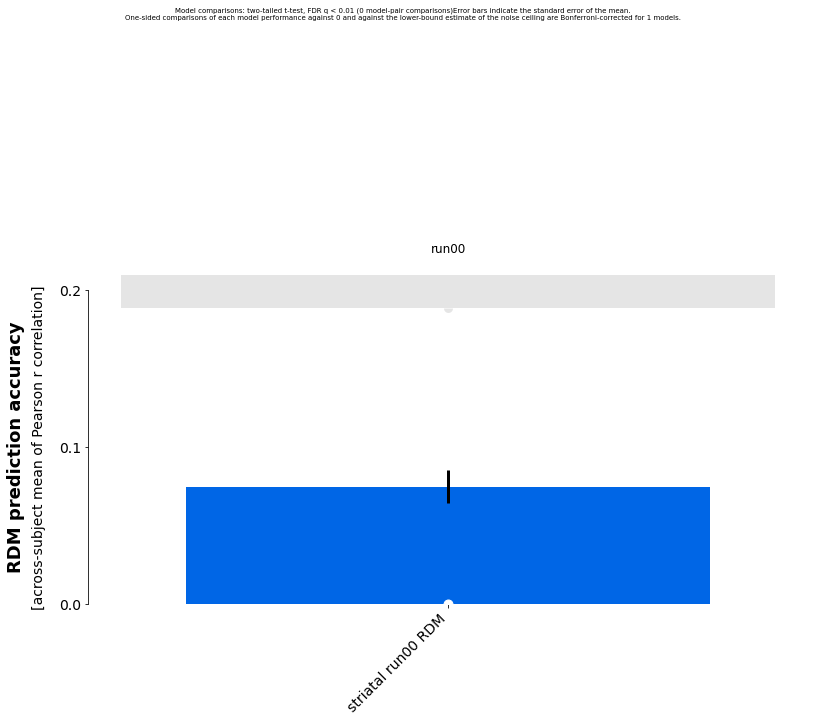

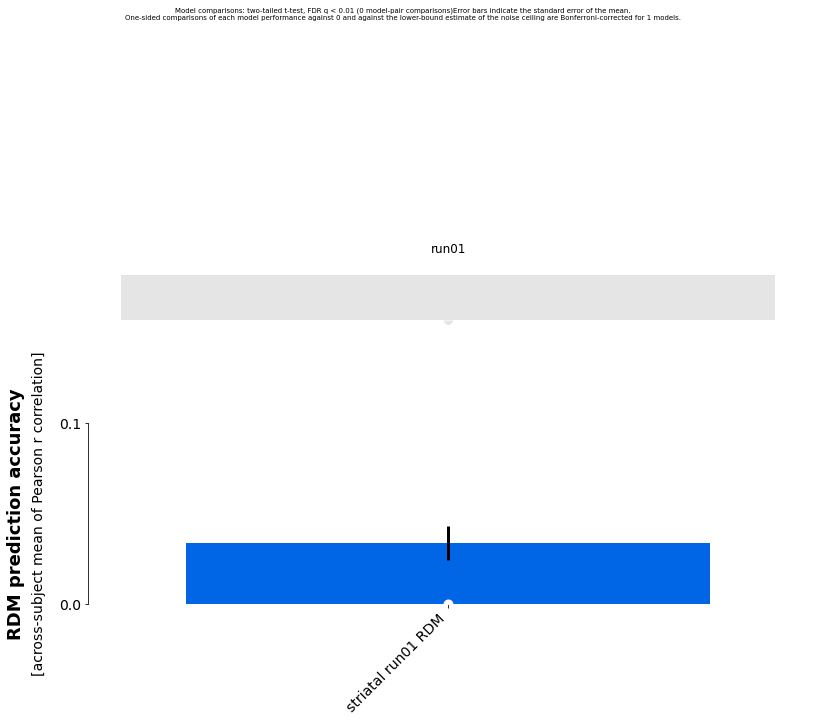

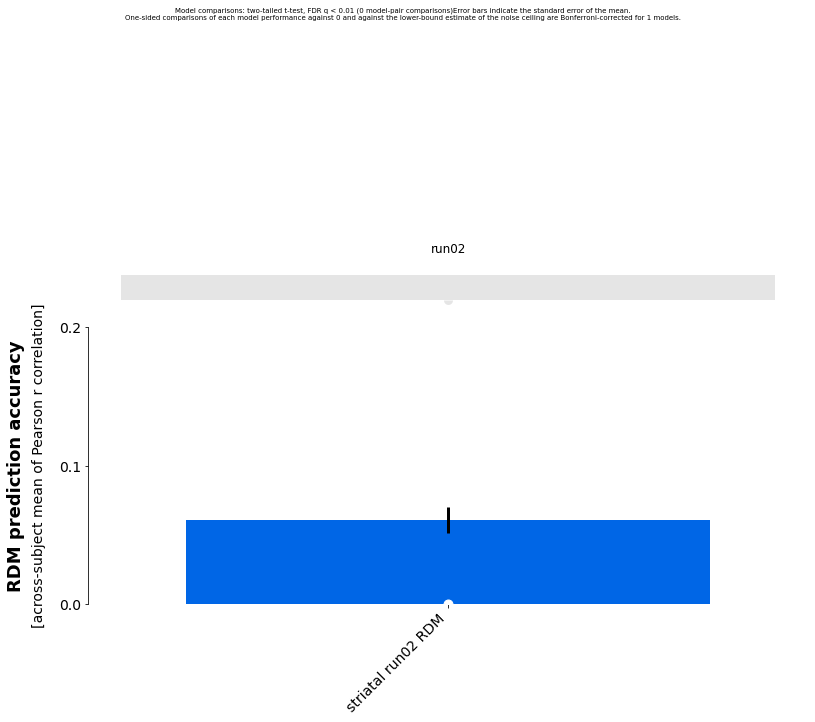

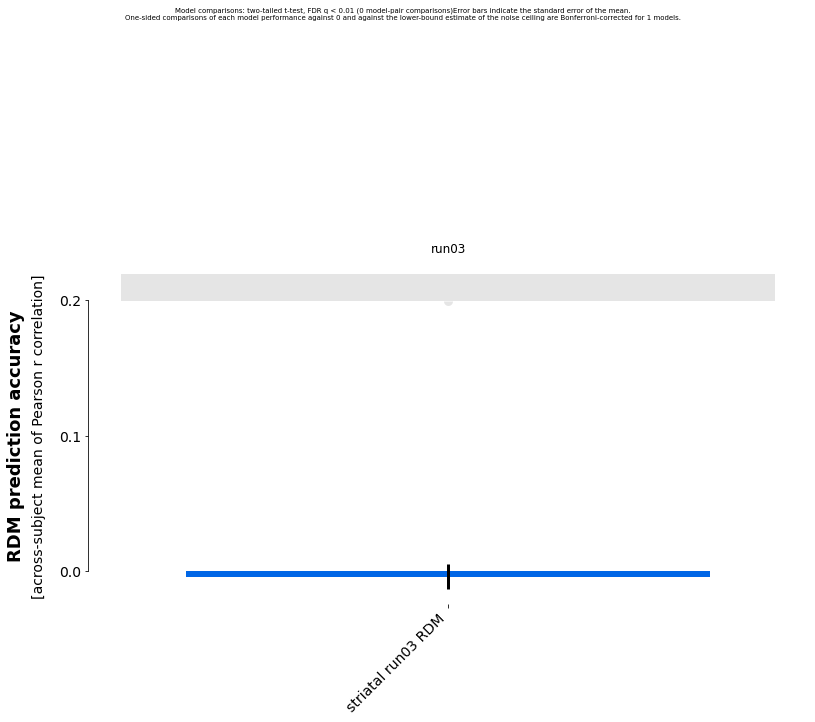

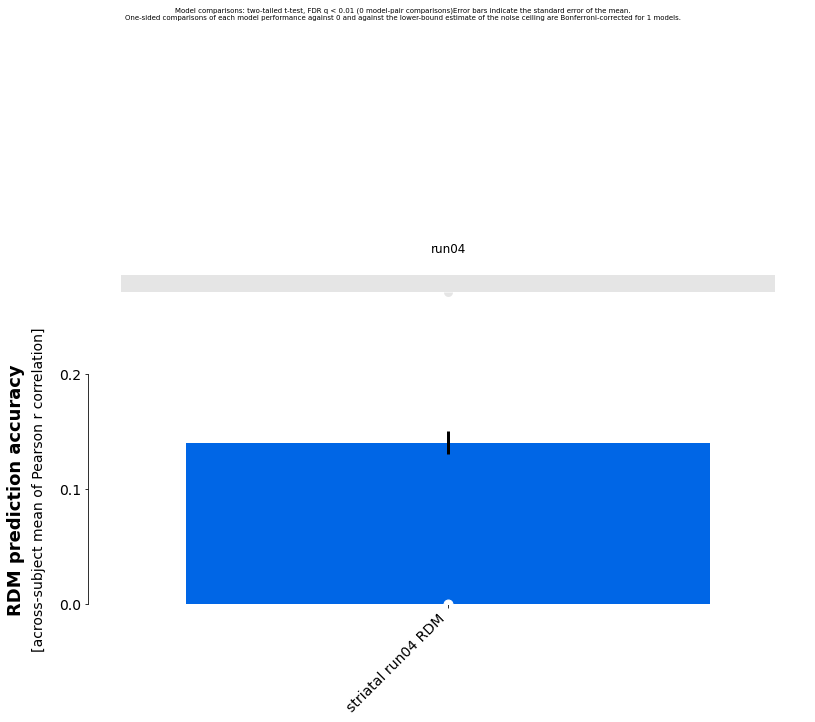

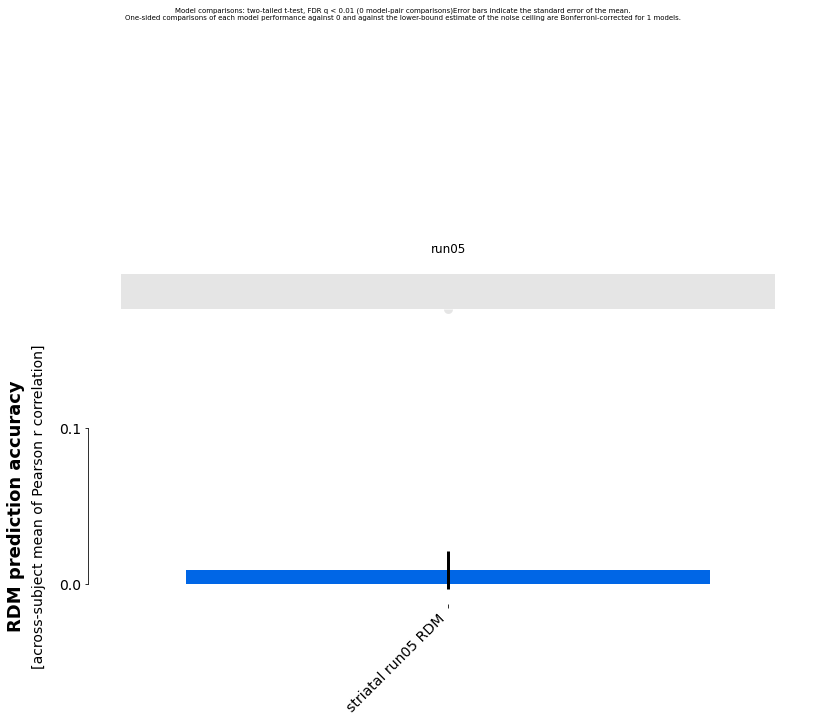

In [98]:
for runx, run in enumerate(run_list): 

    print(f'{run}')
    results_grr = rsatoolbox.inference.eval_fixed(striatal_single_model_dict[run], 
                                                  auditory_rdms.subset('run', value=run),  
                                                  method='corr',
                                                 )
    print(results_grr)
    
    fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr,
                                                         test_pair_comparisons='nili', #'nili', False
                                                        );
    ax1.set_title(f'{run}');
    ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")

#### Auditory data per striatal ROI

In [241]:
np.unique(auditory_rdms.rdm_descriptors['ROI'])

array(['L-HG', 'L-IC', 'L-MGN', 'L-PP', 'L-PT', 'L-ParsOp', 'L-ParsTri',
       'L-STGa', 'L-STGp', 'R-HG', 'R-IC', 'R-MGN', 'R-PP', 'R-PT',
       'R-ParsOp', 'R-ParsTri', 'R-STGa', 'R-STGp'], dtype='<U9')

In [70]:
striatal_models_dict[run]

run00
Results for running fixed evaluation for corr on 14 models:

Model     |   Eval ± SEM   | p (against 0) | p (against NC) |
-------------------------------------------------------------
CAU-DA-lh |  0.039 ± 0.009 |      < 0.001  |       < 0.001  |
CAU-DA-rh |  0.048 ± 0.011 |      < 0.001  |       < 0.001  |
CAU-VA-lh |  0.009 ± 0.010 |        0.180  |       < 0.001  |
CAU-VA-rh | -0.001 ± 0.010 |        0.541  |       < 0.001  |
PUT-DA-lh |  0.077 ± 0.009 |      < 0.001  |       < 0.001  |
PUT-DA-rh |  0.079 ± 0.010 |      < 0.001  |       < 0.001  |
PUT-DP-lh |  0.049 ± 0.011 |      < 0.001  |       < 0.001  |
PUT-DP-rh |  0.095 ± 0.011 |      < 0.001  |       < 0.001  |
PUT-VA-lh |  0.060 ± 0.010 |      < 0.001  |       < 0.001  |
PUT-VA-rh |  0.025 ± 0.012 |        0.021  |       < 0.001  |
PUT-VP-lh |  0.050 ± 0.010 |      < 0.001  |       < 0.001  |
PUT-VP-rh |  0.075 ± 0.010 |      < 0.001  |       < 0.001  |
pCAU-lh   |  0.017 ± 0.012 |        0.077  |       < 0.001  |
pCA

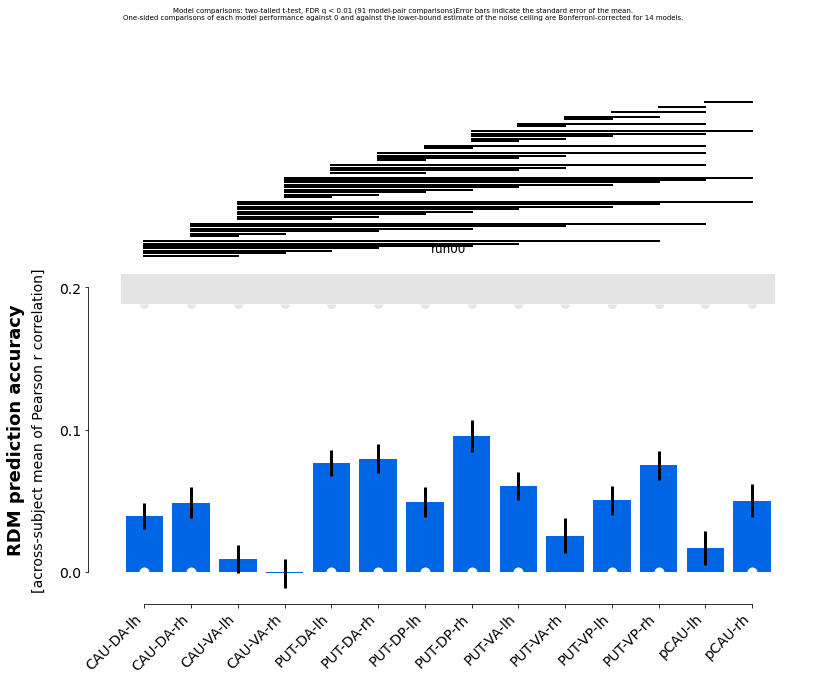

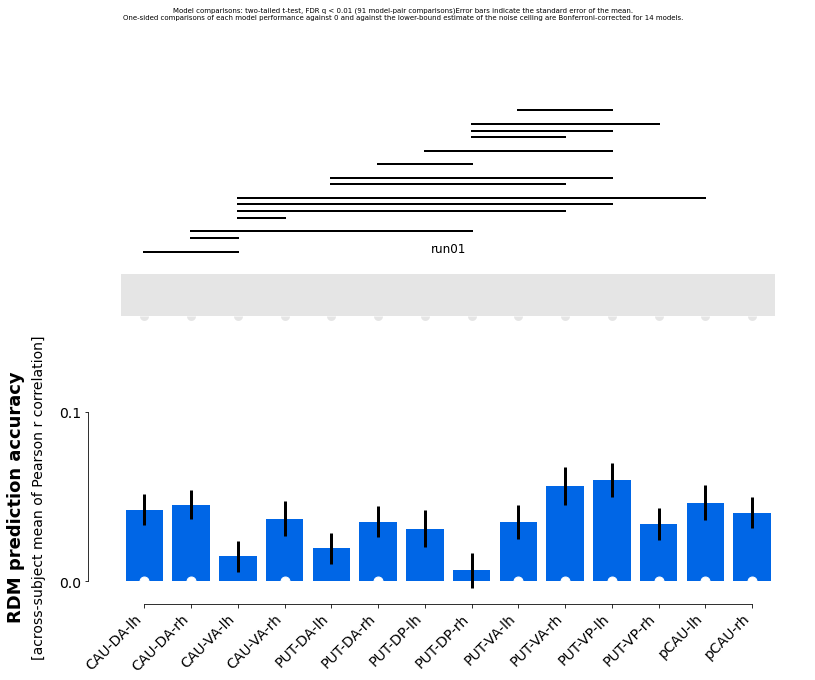

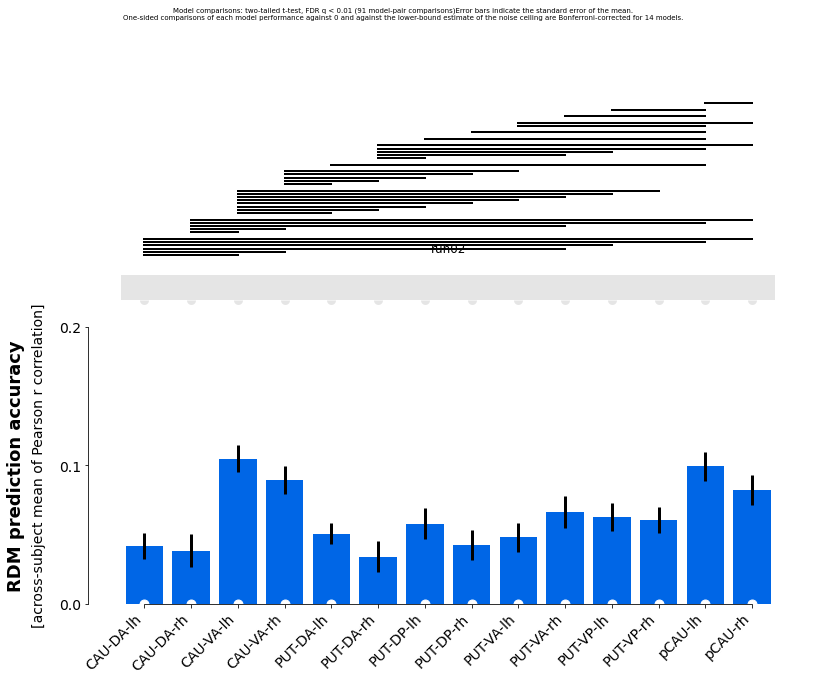

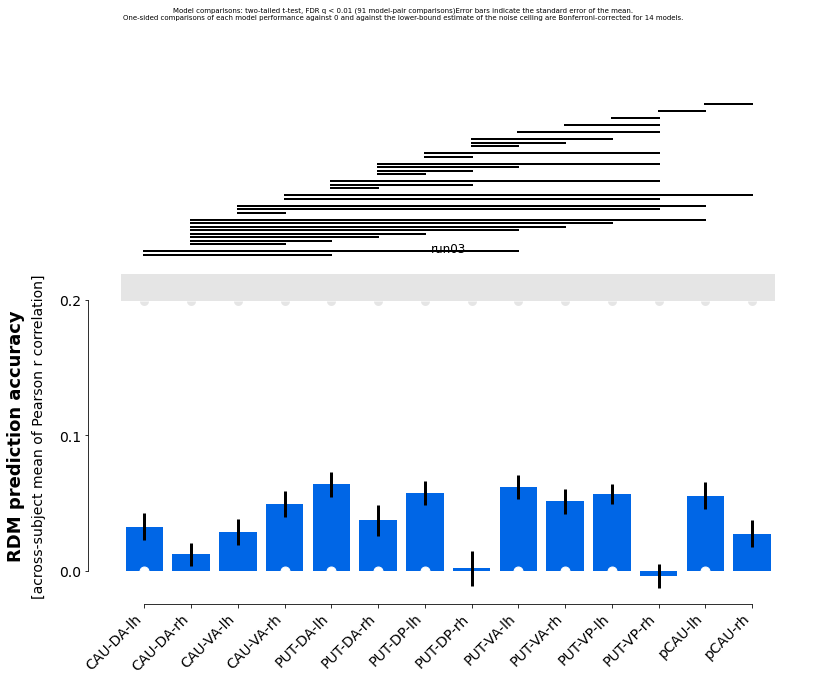

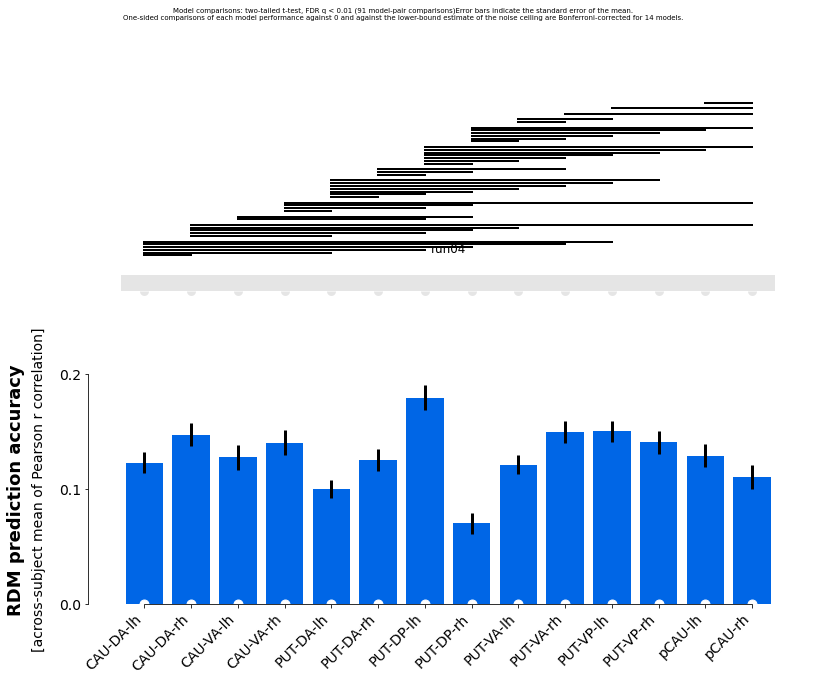

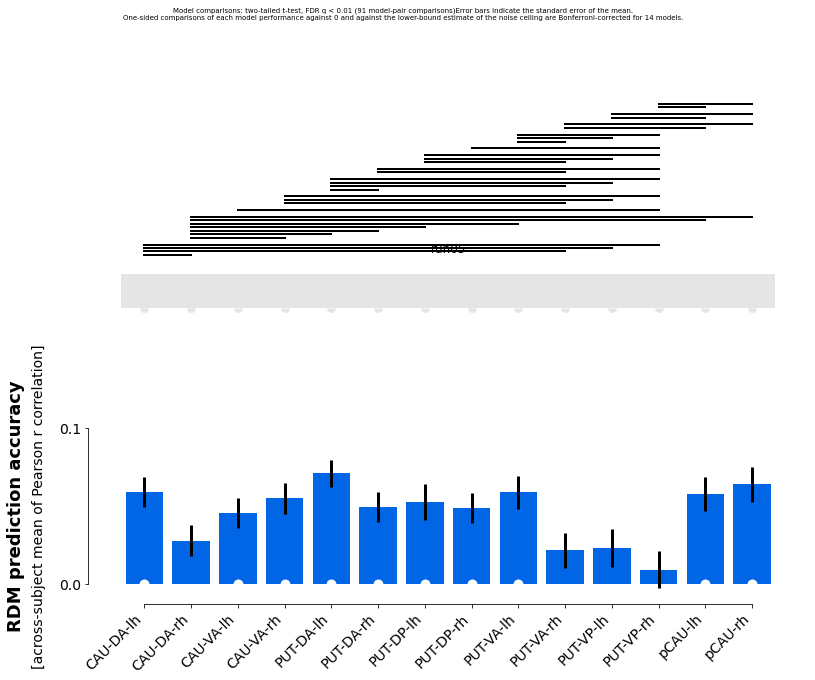

In [242]:
for runx, run in enumerate(run_list): 

    print(f'{run}')
    results_grr = rsatoolbox.inference.eval_fixed(striatal_models_dict[run], 
                                                  auditory_rdms.subset('run', value=run),  
                                                  method='corr',)
    print(results_grr)
    
    fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr,
                                                         test_pair_comparisons='nili', #'nili', False
                                                        );
    ax1.set_title(f'{run}');
    ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")

#### Striatal data per auditory ROI

In [239]:
np.unique(striatal_rdms.rdm_descriptors['ROI'])

array(['CAU-DA-lh', 'CAU-DA-rh', 'CAU-VA-lh', 'CAU-VA-rh', 'PUT-DA-lh',
       'PUT-DA-rh', 'PUT-DP-lh', 'PUT-DP-rh', 'PUT-VA-lh', 'PUT-VA-rh',
       'PUT-VP-lh', 'PUT-VP-rh', 'pCAU-lh', 'pCAU-rh'], dtype='<U9')

run00
Results for running fixed evaluation for corr on 14 models:

Model     |   Eval ± SEM   | p (against 0) | p (against NC) |
-------------------------------------------------------------
L-HG      |  0.051 ± 0.011 |      < 0.001  |       < 0.001  |
L-PP      |  0.053 ± 0.009 |      < 0.001  |       < 0.001  |
L-PT      |  0.082 ± 0.010 |      < 0.001  |       < 0.001  |
L-ParsOp  |  0.022 ± 0.012 |        0.033  |       < 0.001  |
L-ParsTri |  0.025 ± 0.010 |        0.007  |       < 0.001  |
L-STGa    |  0.036 ± 0.011 |      < 0.001  |       < 0.001  |
L-STGp    |  0.059 ± 0.011 |      < 0.001  |       < 0.001  |
R-HG      |  0.088 ± 0.013 |      < 0.001  |       < 0.001  |
R-PP      |  0.079 ± 0.010 |      < 0.001  |       < 0.001  |
R-PT      |  0.085 ± 0.012 |      < 0.001  |       < 0.001  |
R-ParsOp  |  0.029 ± 0.014 |        0.019  |       < 0.001  |
R-ParsTri |  0.044 ± 0.013 |      < 0.001  |       < 0.001  |
R-STGa    |  0.054 ± 0.013 |      < 0.001  |       < 0.001  |
R-S

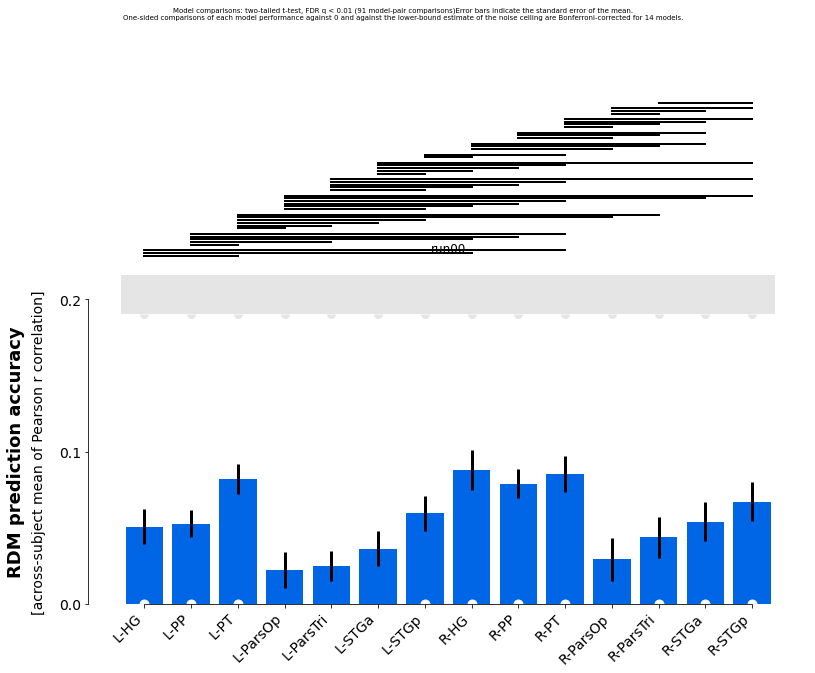

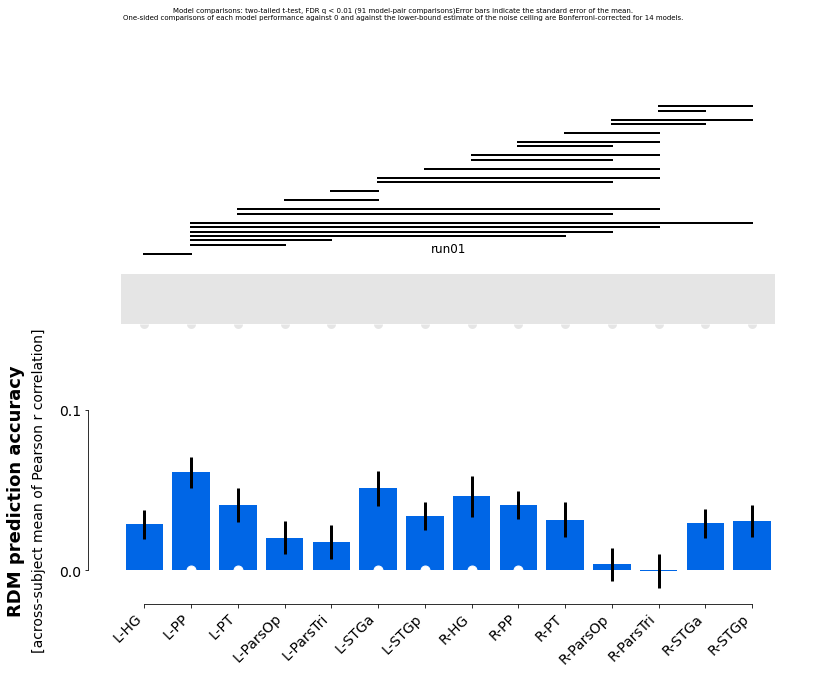

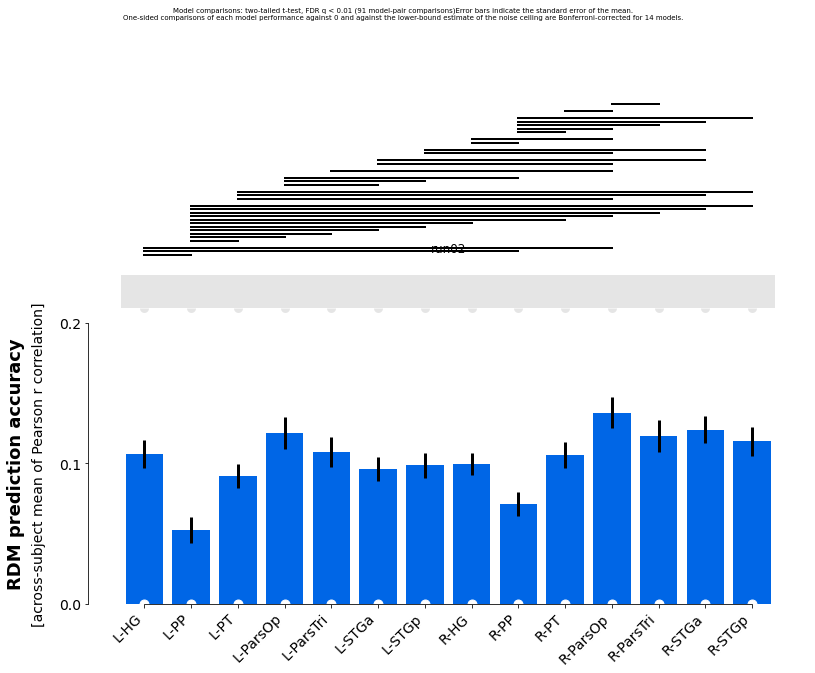

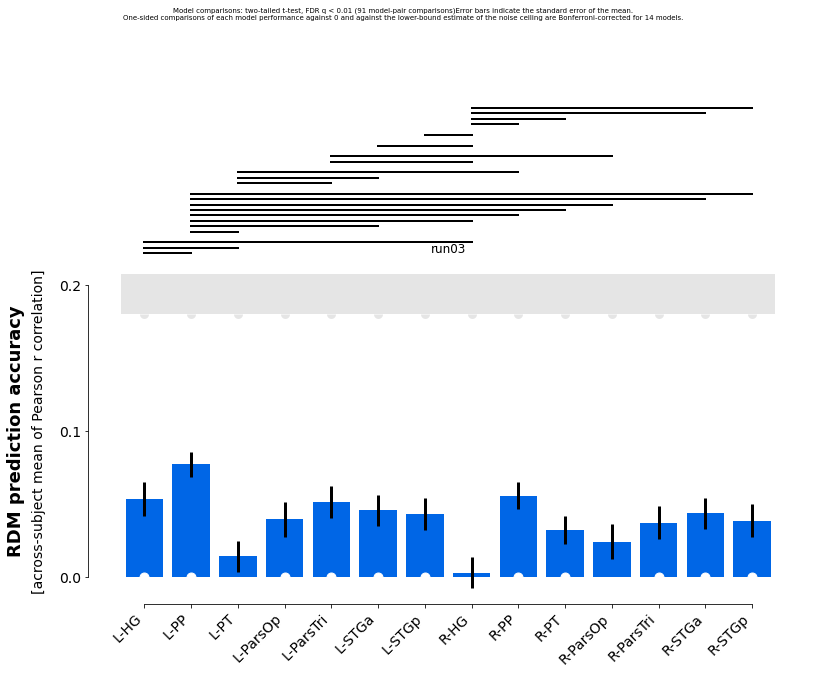

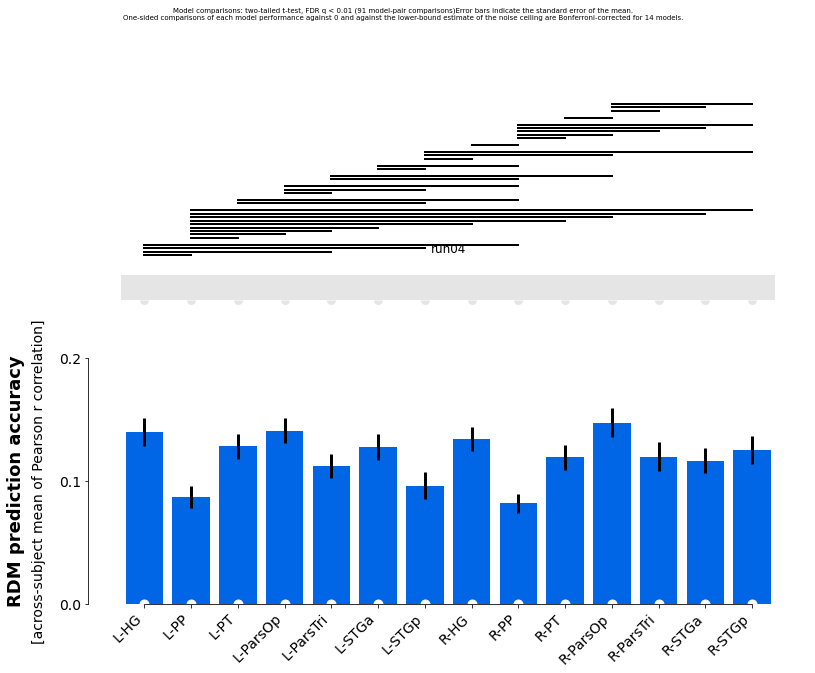

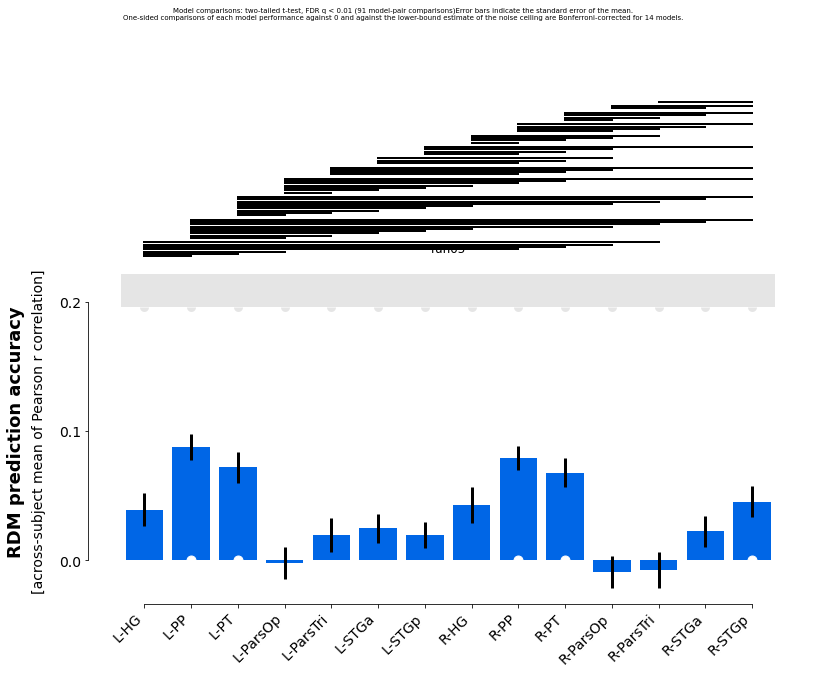

In [240]:
for runx, run in enumerate(run_list): 

    print(f'{run}')
    results_grr = rsatoolbox.inference.eval_fixed(auditory_models_dict[run], 
                                                  striatal_rdms.subset('run', value=run),  
                                                  method='corr',)
    print(results_grr)
    
    fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr,
                                                         test_pair_comparisons='nili', #'nili', #False, # getting a bug from plot_arrow()
                                                        );
    ax1.set_title(f'{run}');
    ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")

run00 ROI-CAU-DA-lh
run00 ROI-CAU-DA-rh
run00 ROI-CAU-VA-lh
run00 ROI-CAU-VA-rh
run00 ROI-NAc-core-lh
run00 ROI-NAc-core-rh
run00 ROI-NAc-shell-lh
run00 ROI-NAc-shell-rh
run00 ROI-PUT-DA-lh
run00 ROI-PUT-DA-rh
run00 ROI-PUT-DP-lh
run00 ROI-PUT-DP-rh
run00 ROI-PUT-VA-lh
run00 ROI-PUT-VA-rh
run00 ROI-PUT-VP-lh
run00 ROI-PUT-VP-rh
run00 ROI-pCAU-lh
run00 ROI-pCAU-rh
run01 ROI-CAU-DA-lh
run01 ROI-CAU-DA-rh
run01 ROI-CAU-VA-lh


/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/rsatoolbox/vis/model_plot.py:282: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12.5, 10))


run01 ROI-CAU-VA-rh
run01 ROI-NAc-core-lh
run01 ROI-NAc-core-rh
run01 ROI-NAc-shell-lh
run01 ROI-NAc-shell-rh
run01 ROI-PUT-DA-lh
run01 ROI-PUT-DA-rh
run01 ROI-PUT-DP-lh
run01 ROI-PUT-DP-rh
run01 ROI-PUT-VA-lh
run01 ROI-PUT-VA-rh
run01 ROI-PUT-VP-lh
run01 ROI-PUT-VP-rh
run01 ROI-pCAU-lh
run01 ROI-pCAU-rh
run02 ROI-CAU-DA-lh
run02 ROI-CAU-DA-rh
run02 ROI-CAU-VA-lh
run02 ROI-CAU-VA-rh
run02 ROI-NAc-core-lh
run02 ROI-NAc-core-rh
run02 ROI-NAc-shell-lh
run02 ROI-NAc-shell-rh
run02 ROI-PUT-DA-lh
run02 ROI-PUT-DA-rh
run02 ROI-PUT-DP-lh
run02 ROI-PUT-DP-rh
run02 ROI-PUT-VA-lh
run02 ROI-PUT-VA-rh
run02 ROI-PUT-VP-lh
run02 ROI-PUT-VP-rh
run02 ROI-pCAU-lh
run02 ROI-pCAU-rh
run03 ROI-CAU-DA-lh
run03 ROI-CAU-DA-rh
run03 ROI-CAU-VA-lh
run03 ROI-CAU-VA-rh
run03 ROI-NAc-core-lh
run03 ROI-NAc-core-rh
run03 ROI-NAc-shell-lh
run03 ROI-NAc-shell-rh
run03 ROI-PUT-DA-lh
run03 ROI-PUT-DA-rh
run03 ROI-PUT-DP-lh
run03 ROI-PUT-DP-rh
run03 ROI-PUT-VA-lh
run03 ROI-PUT-VA-rh
run03 ROI-PUT-VP-lh
run03 ROI-PUT-VP-r

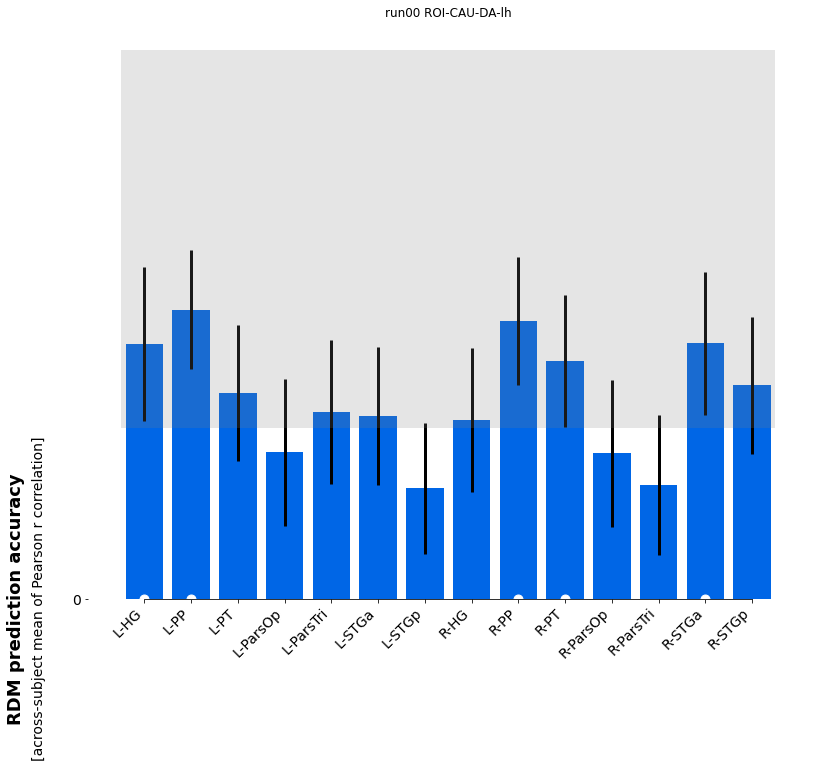

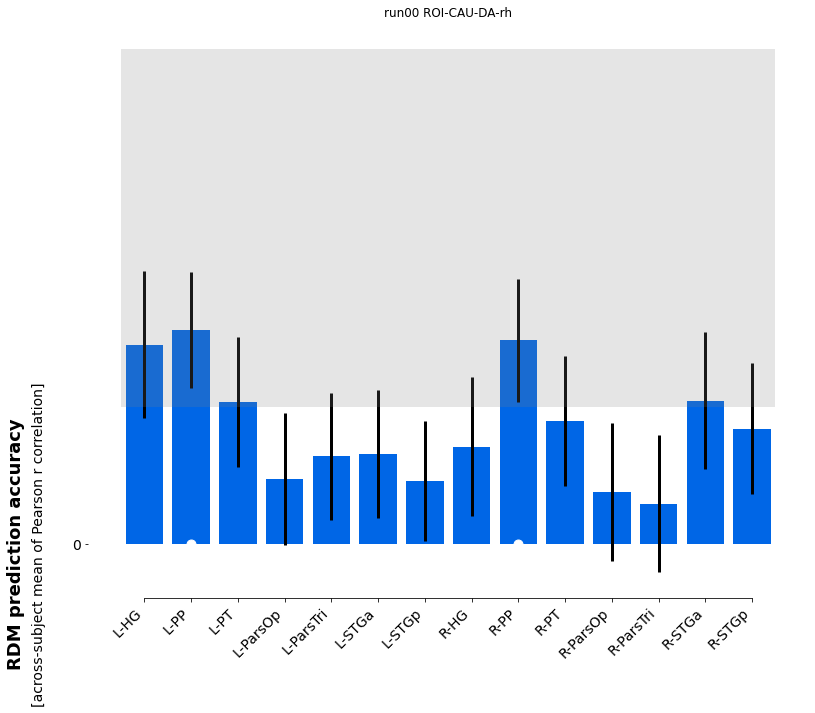

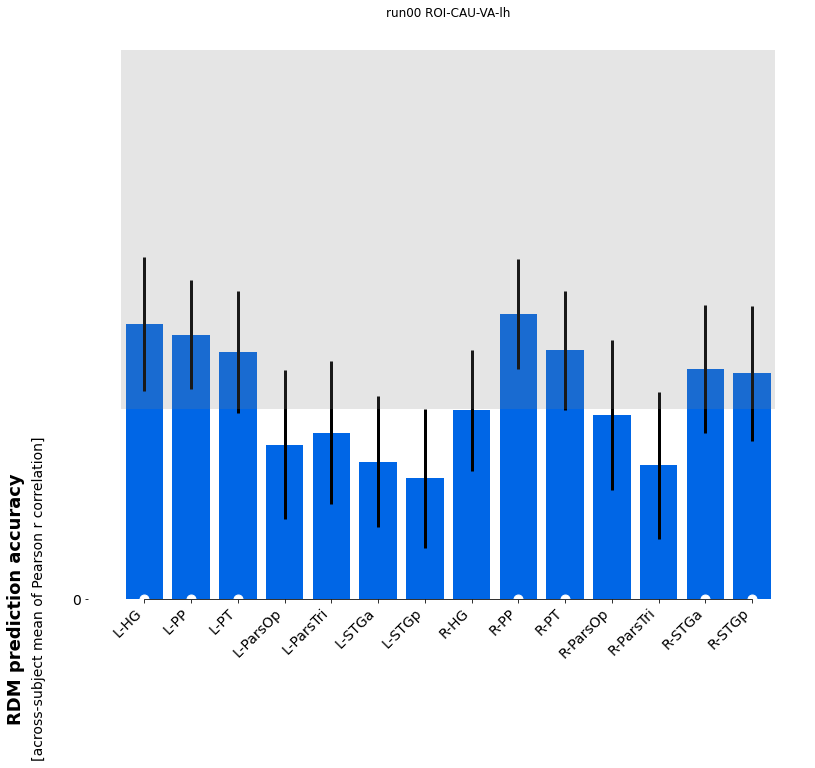

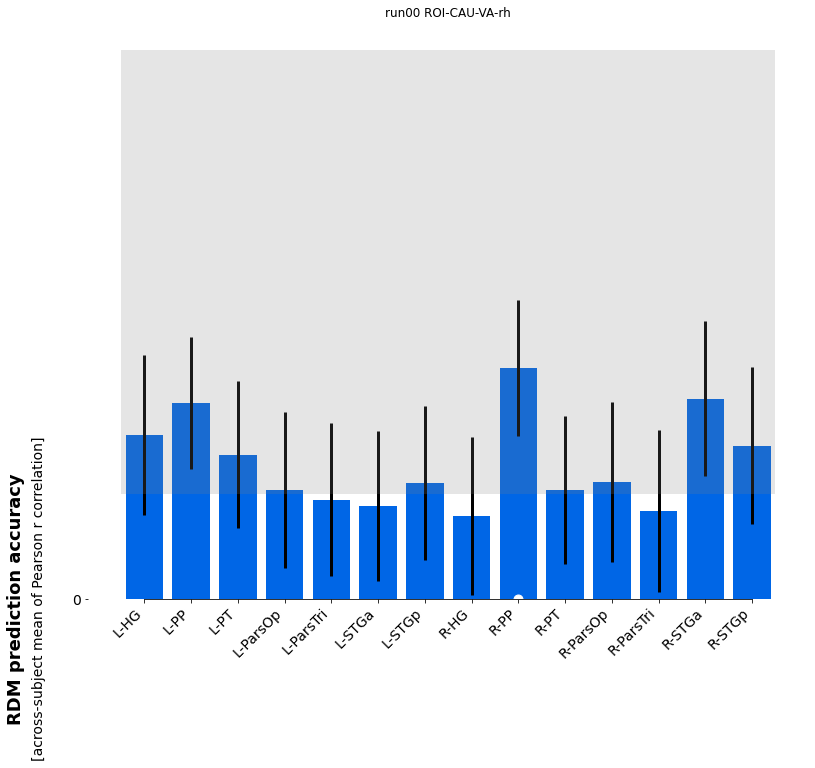

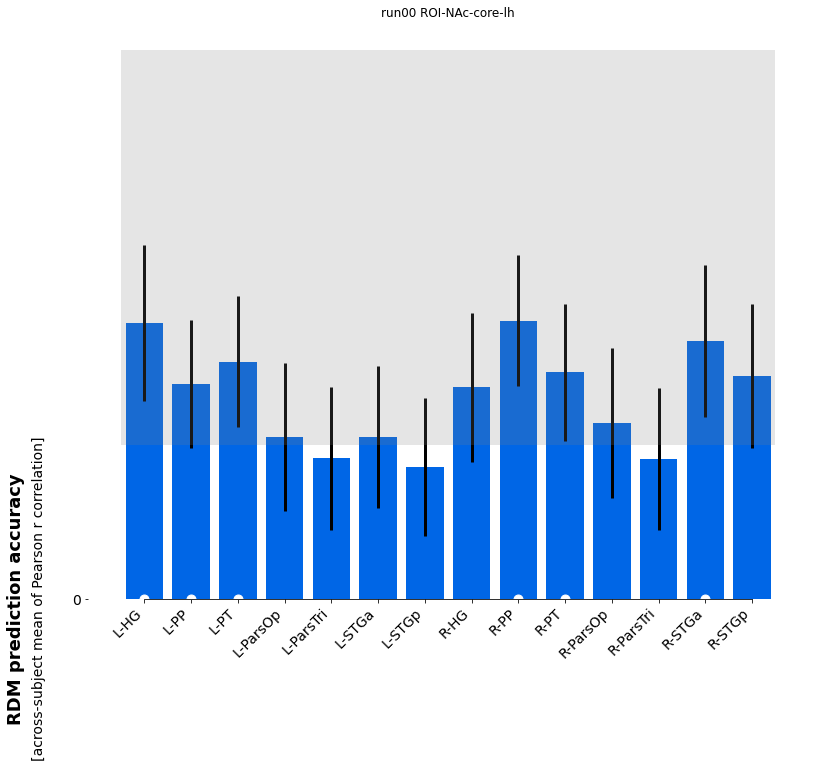

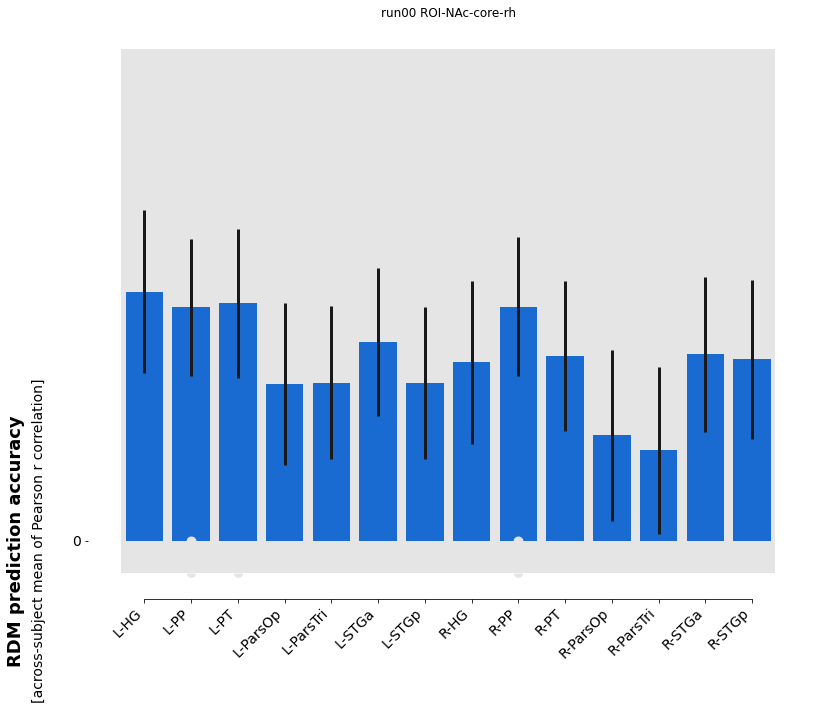

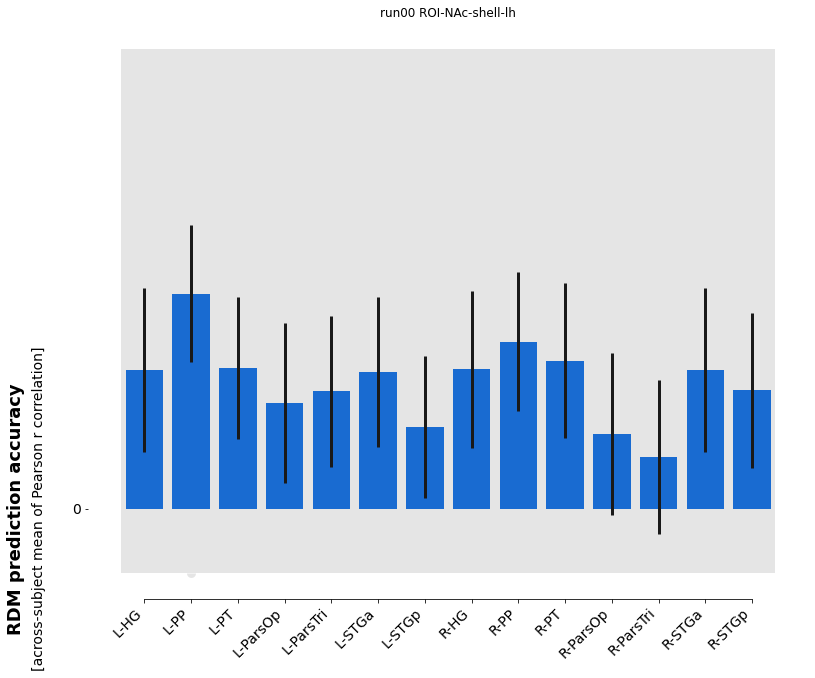

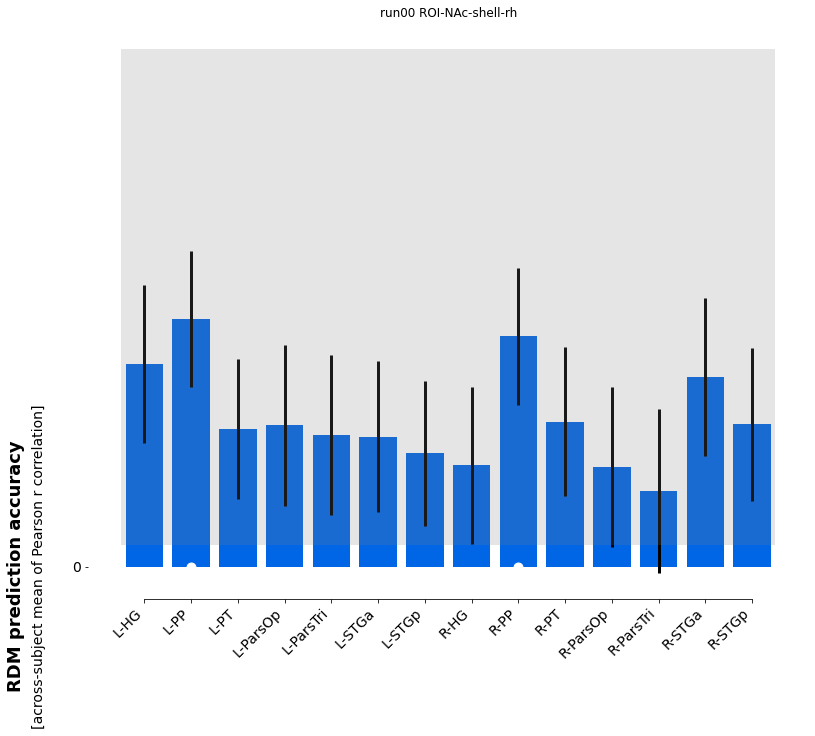

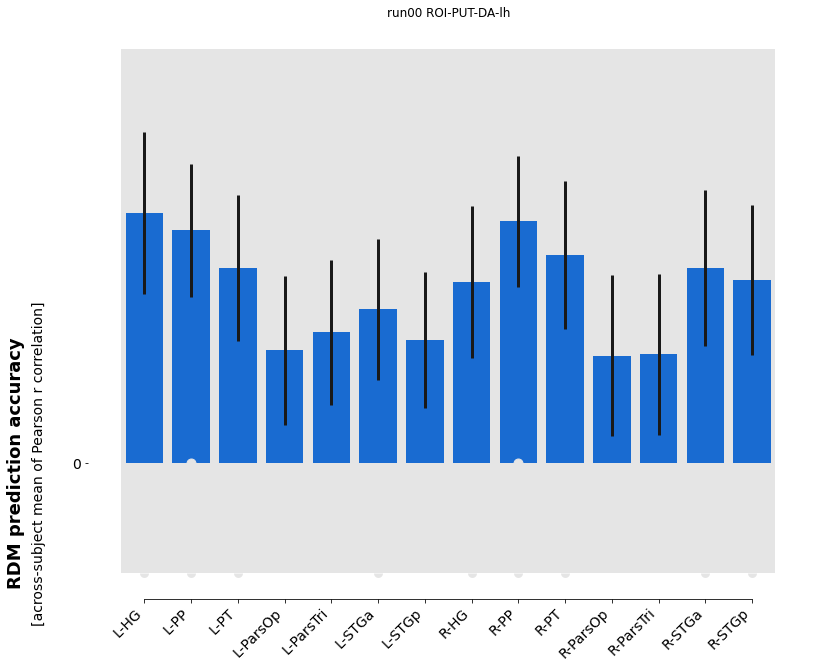

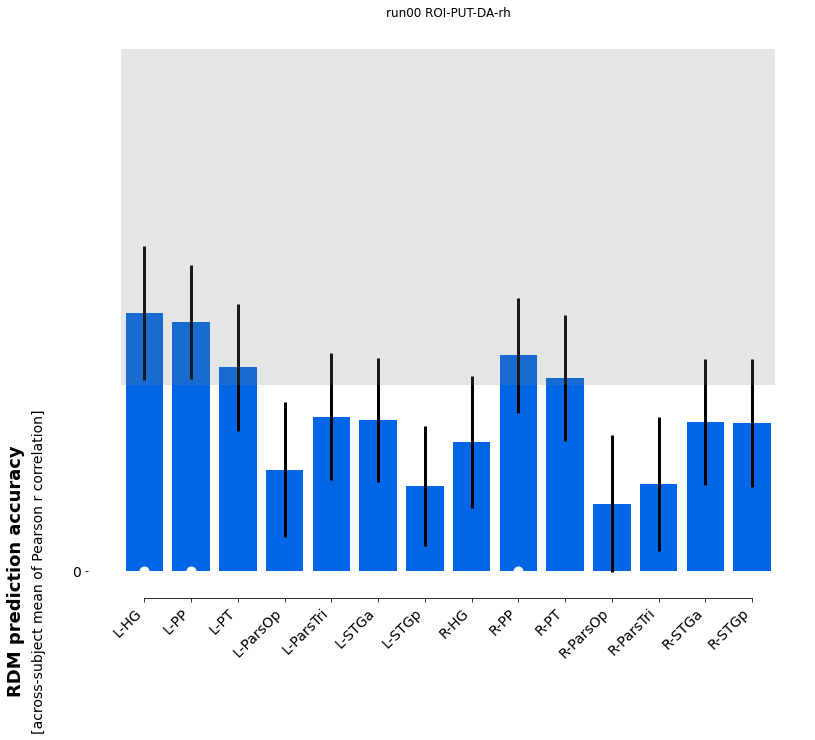

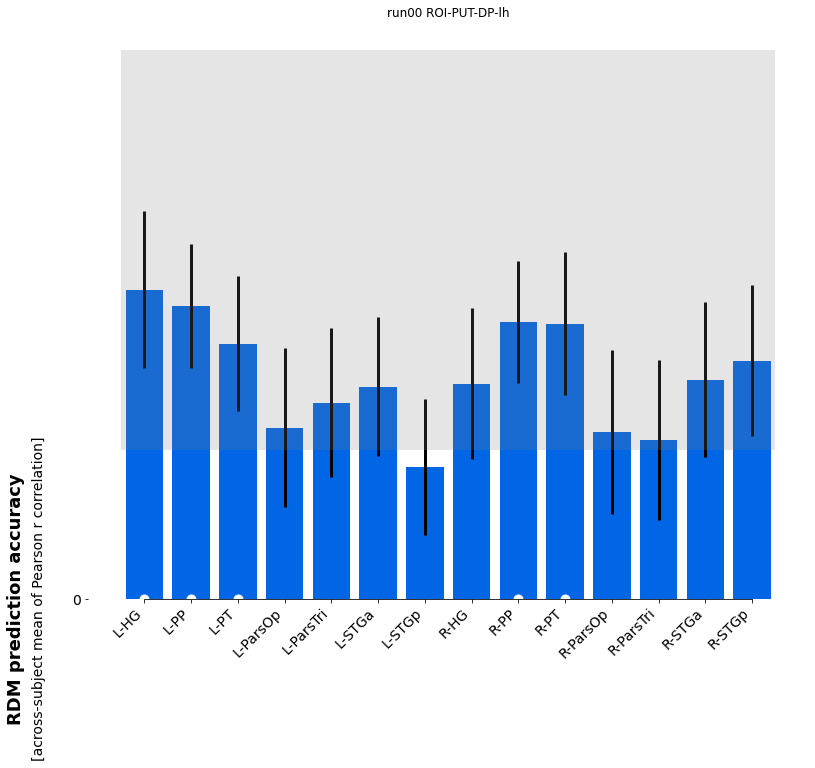

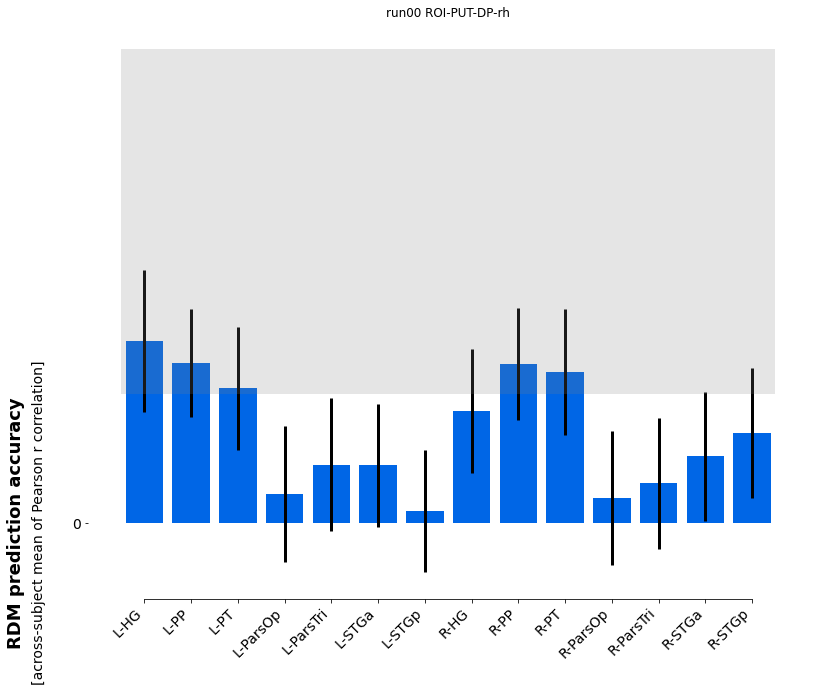

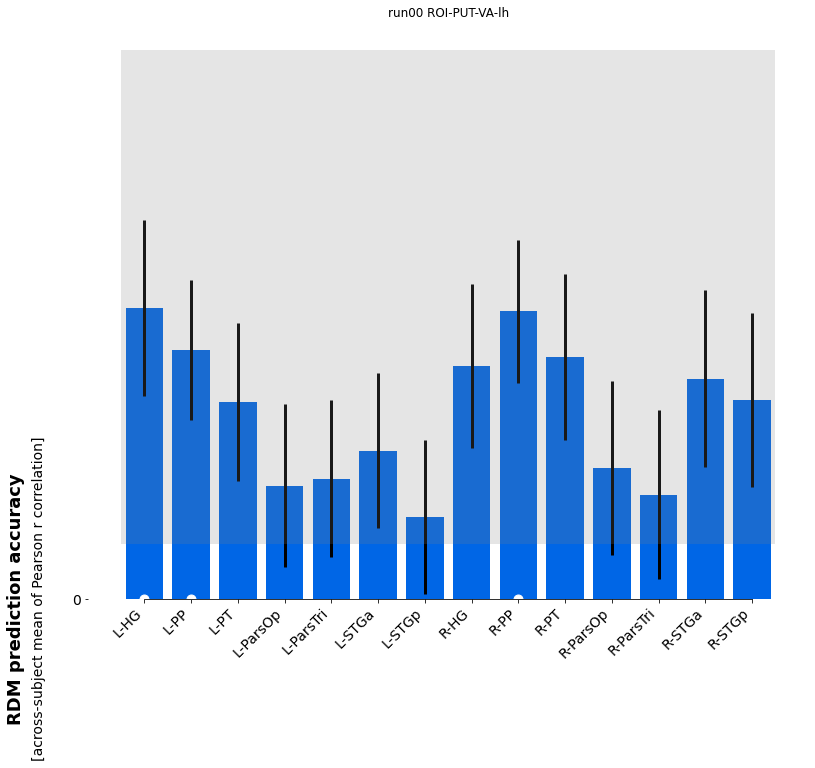

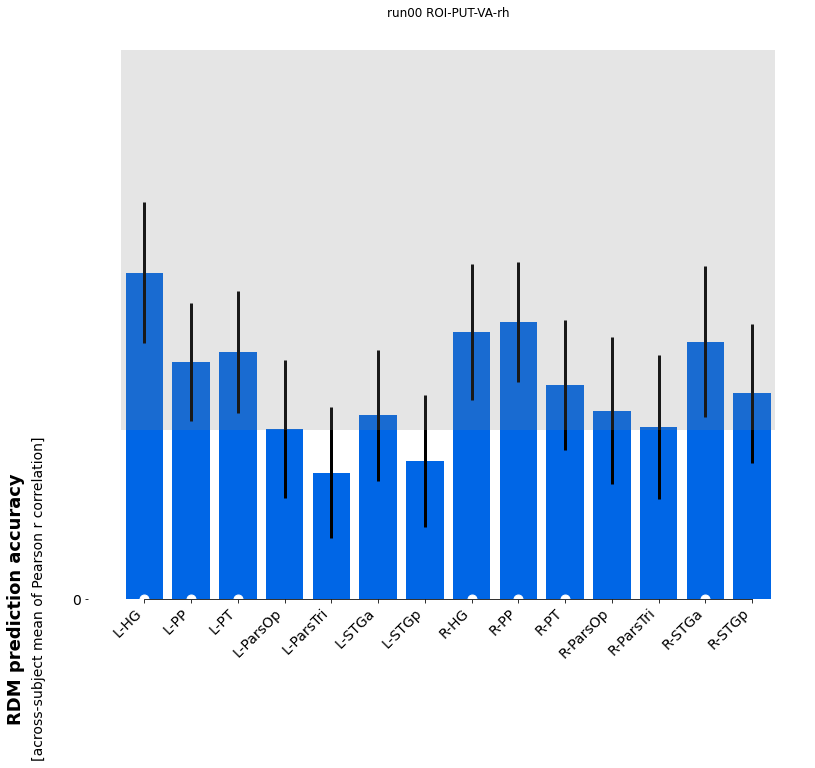

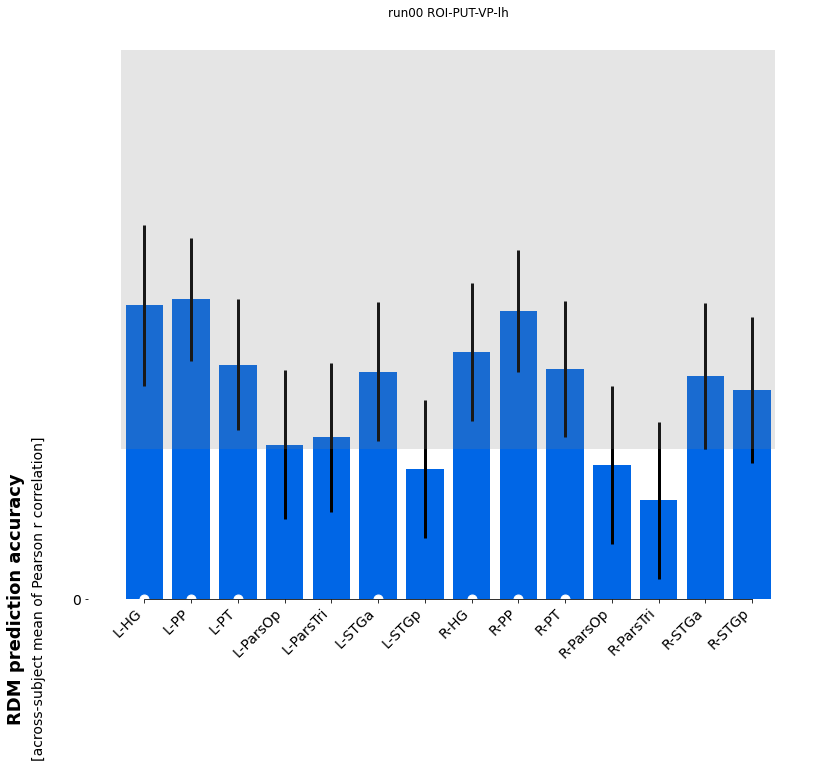

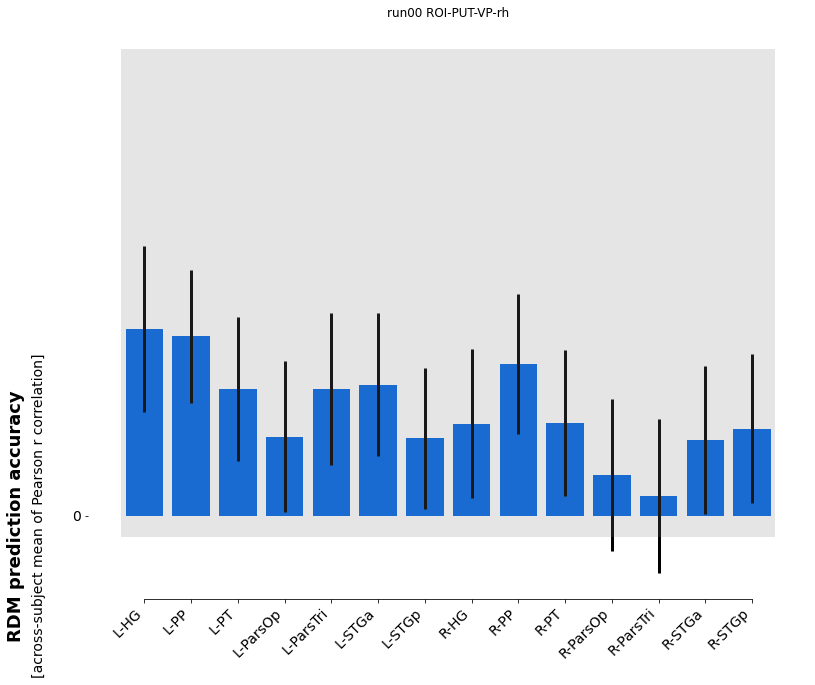

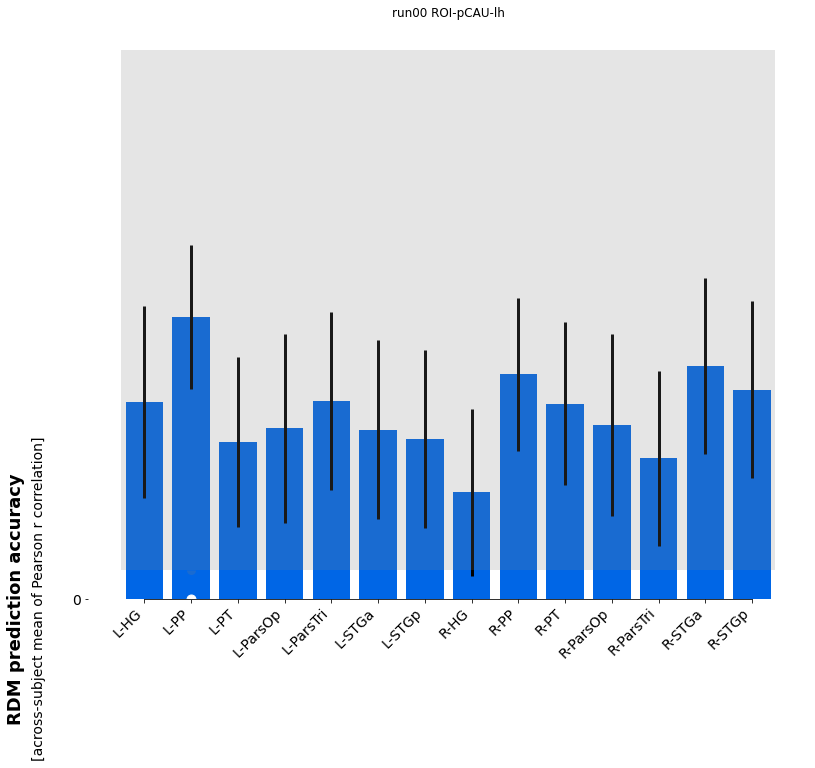

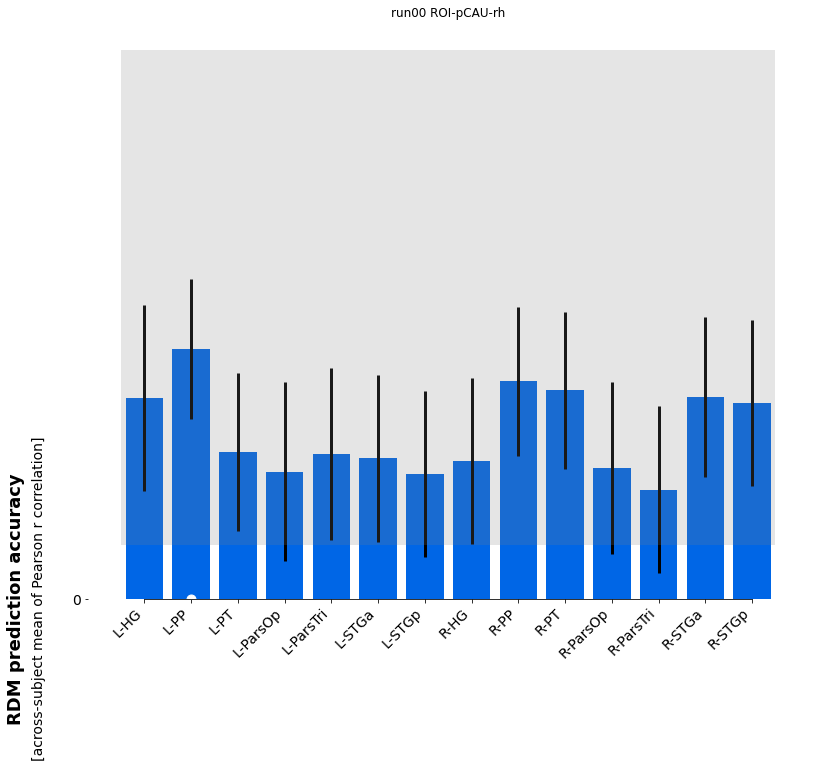

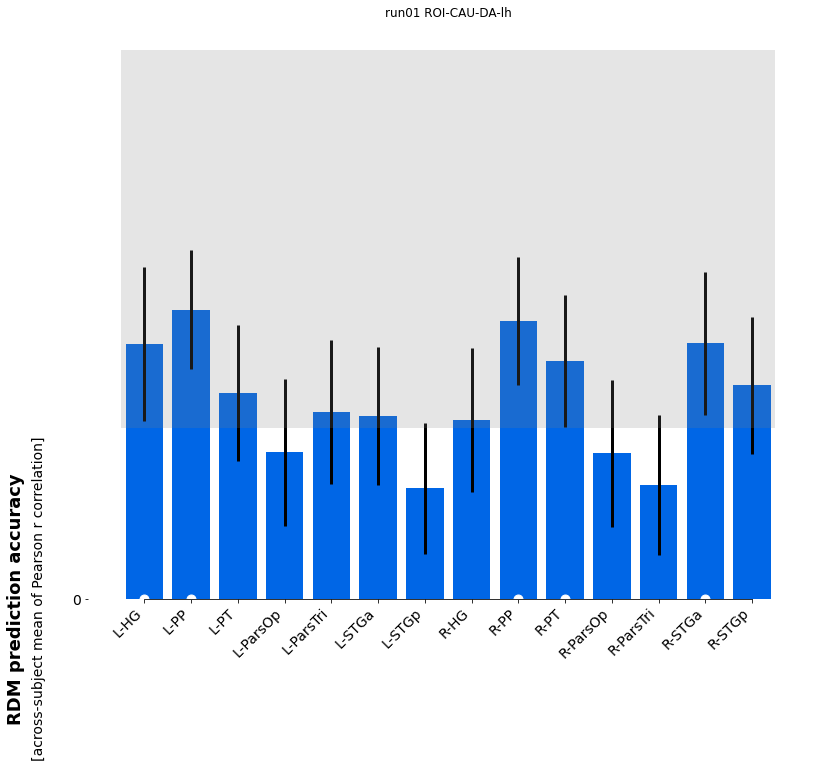

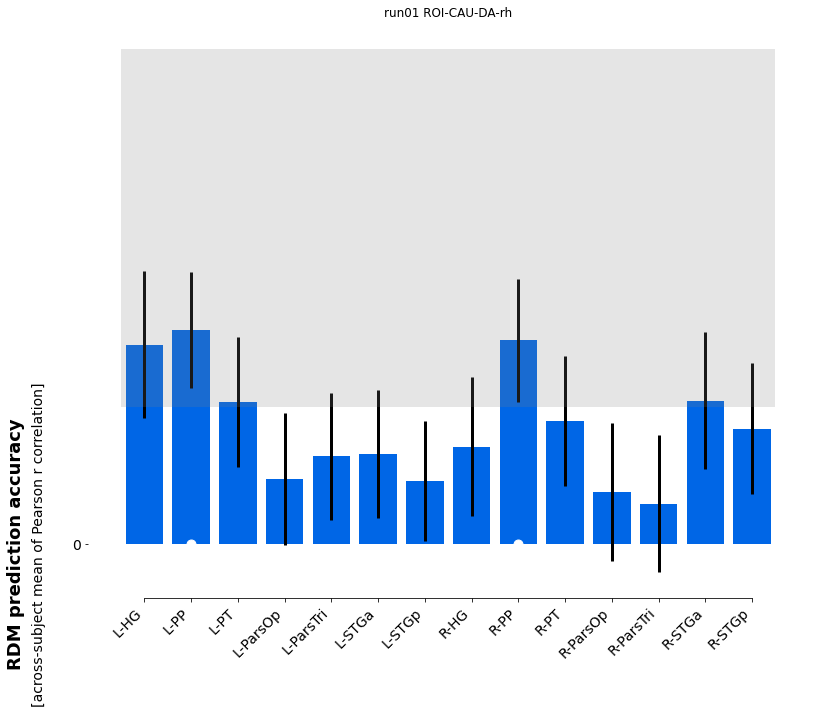

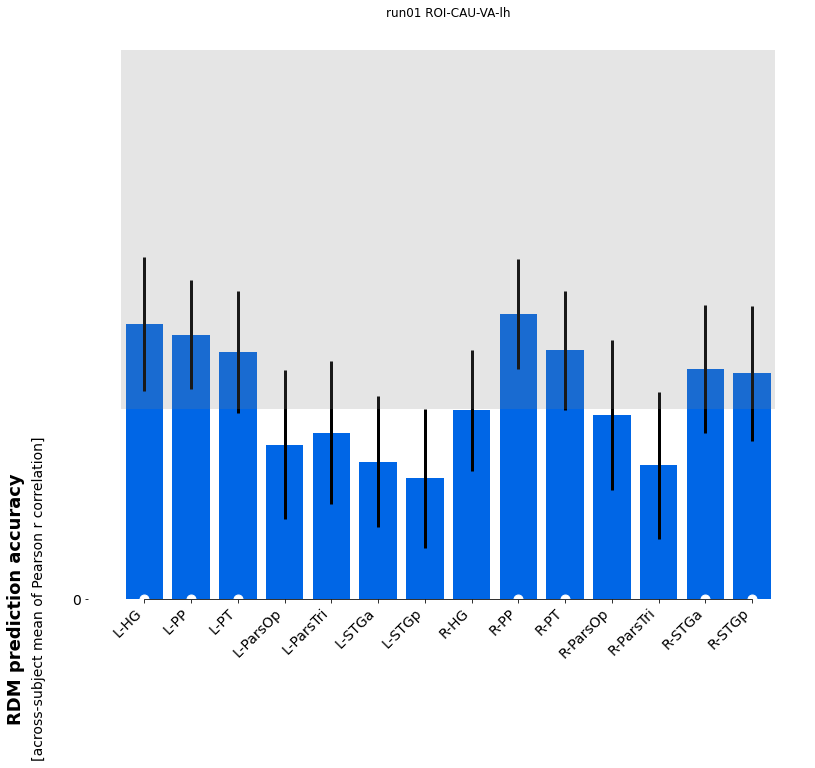

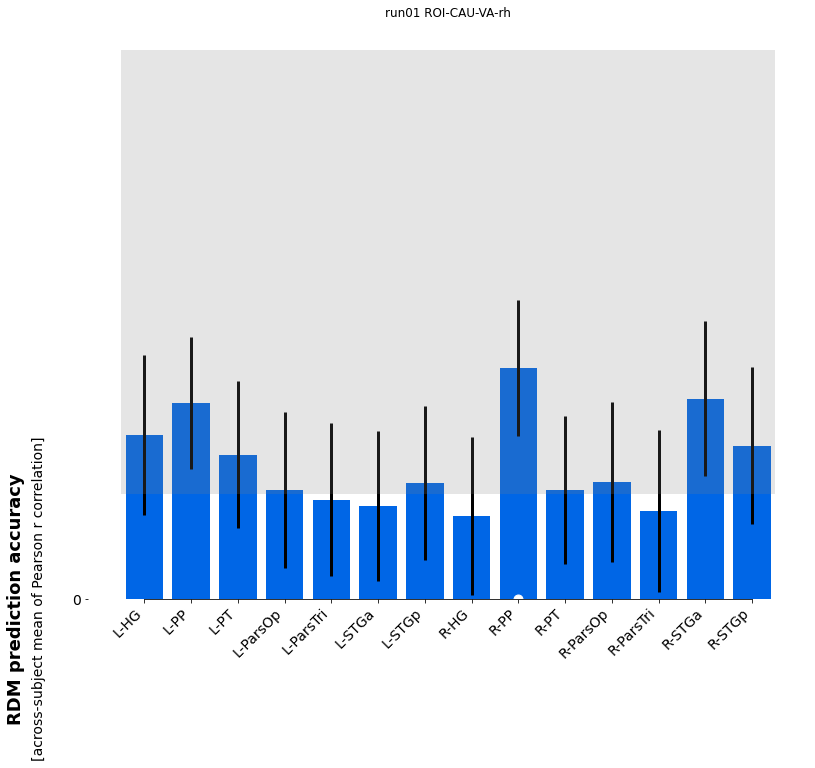

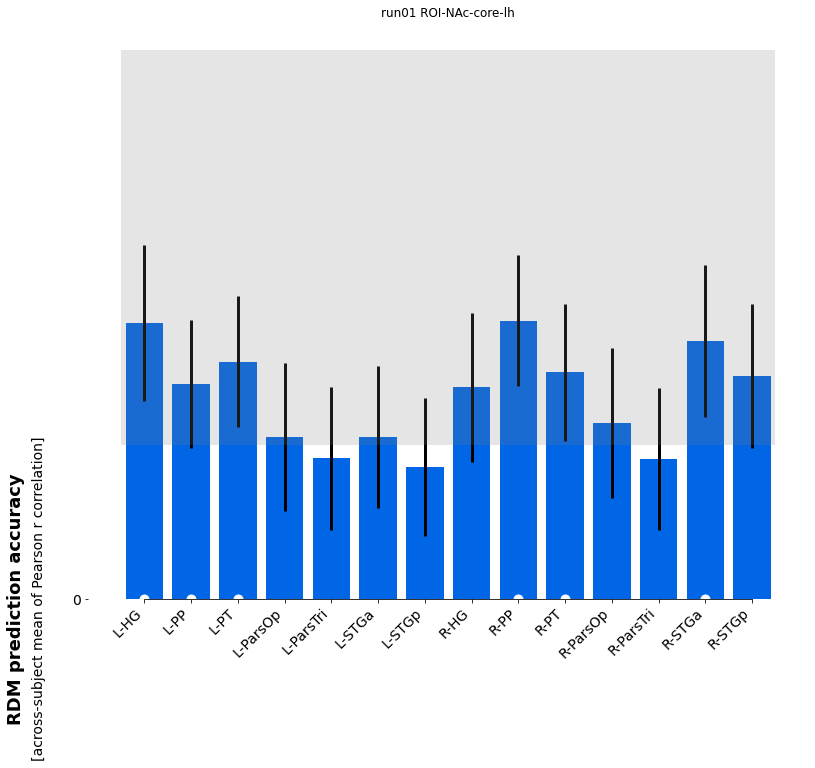

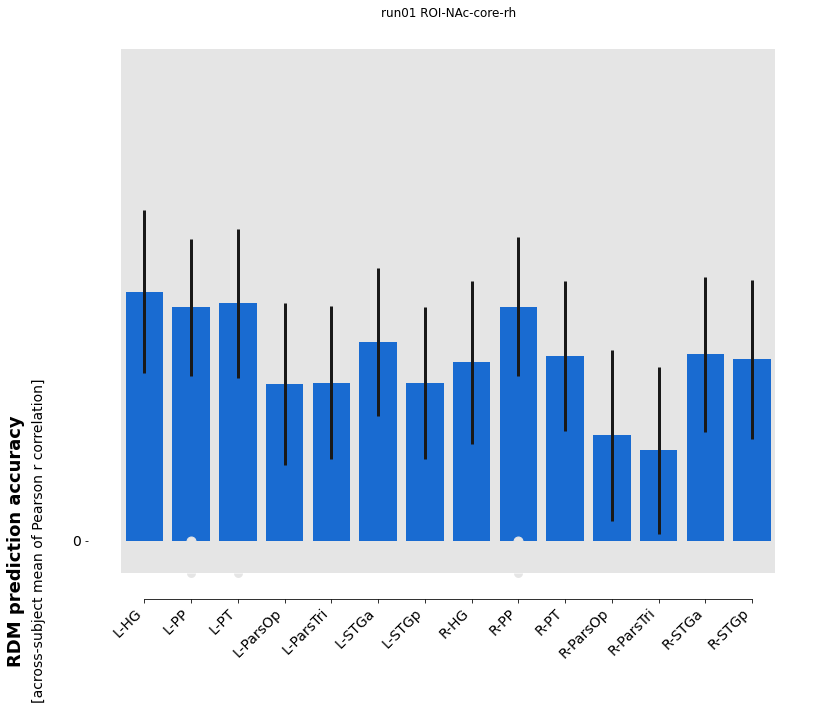

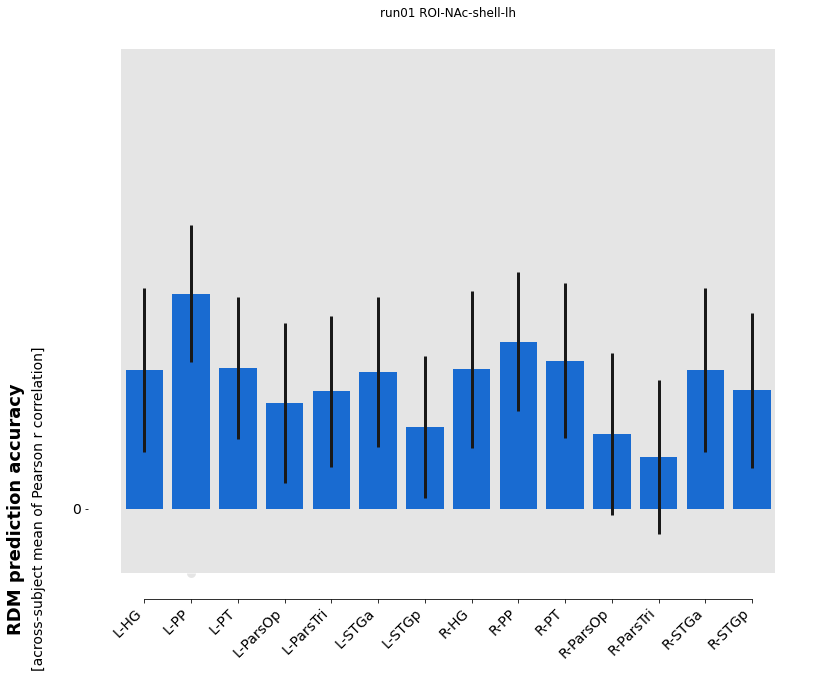

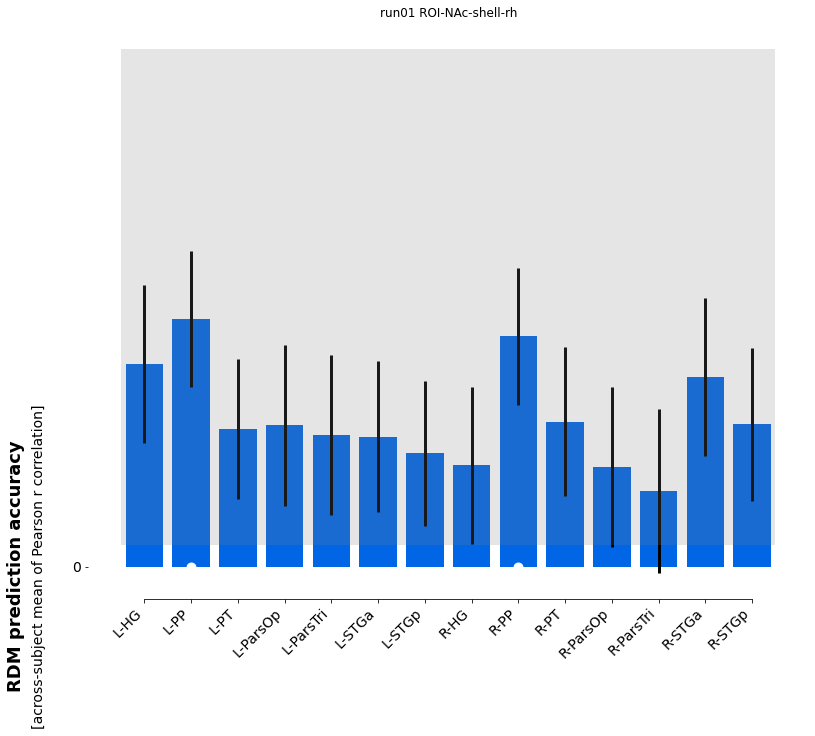

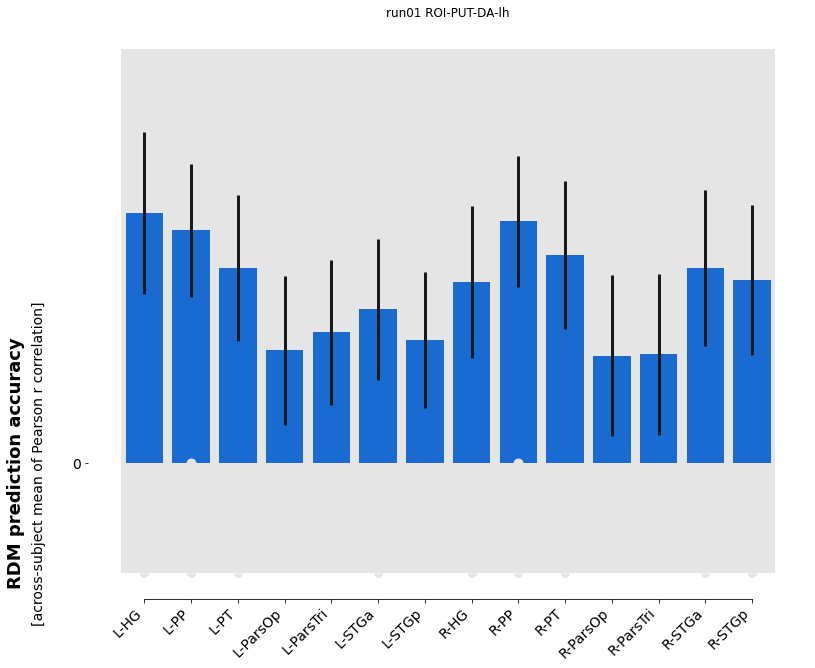

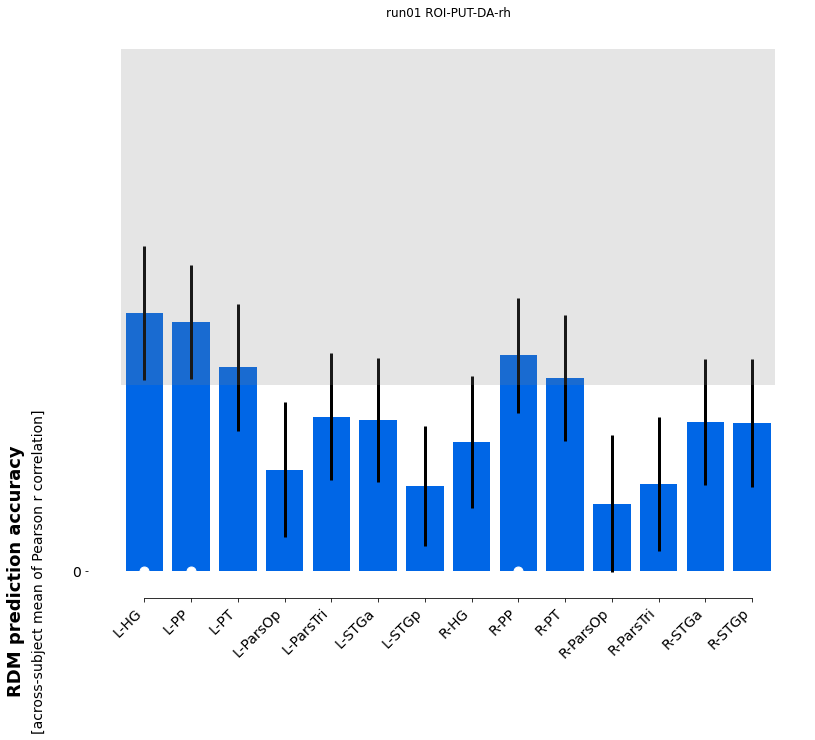

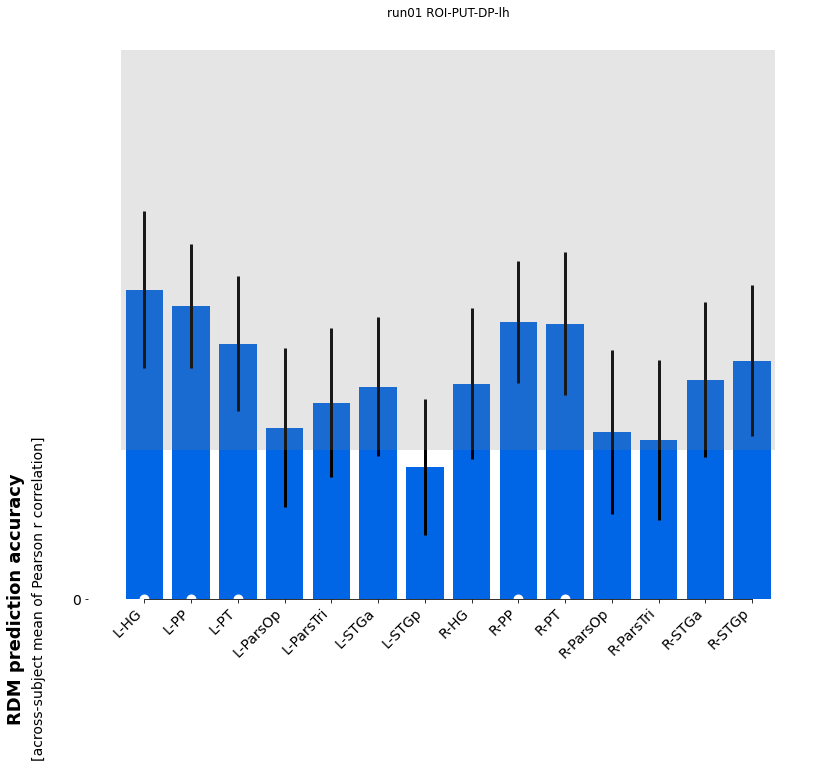

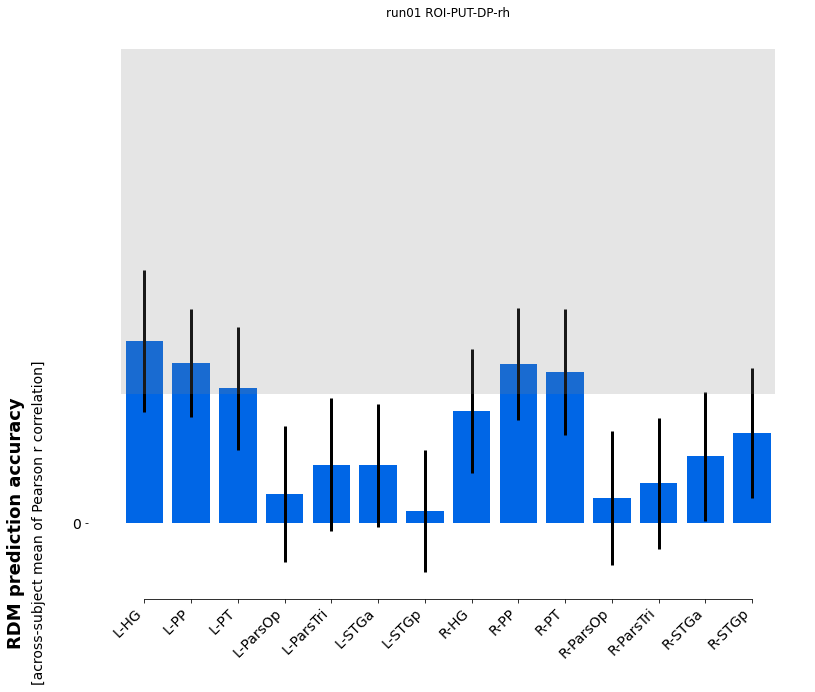

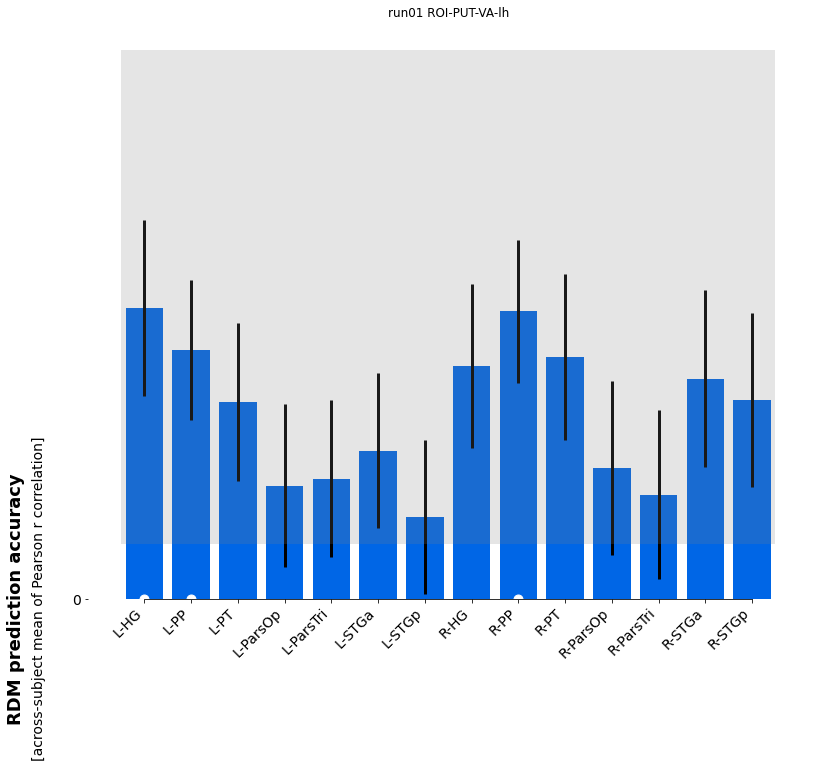

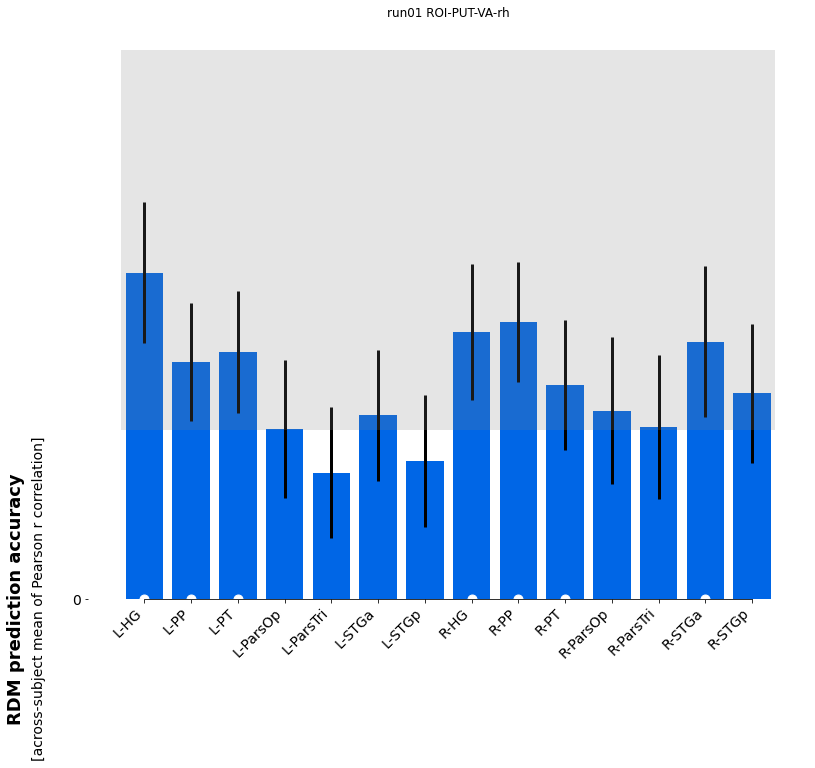

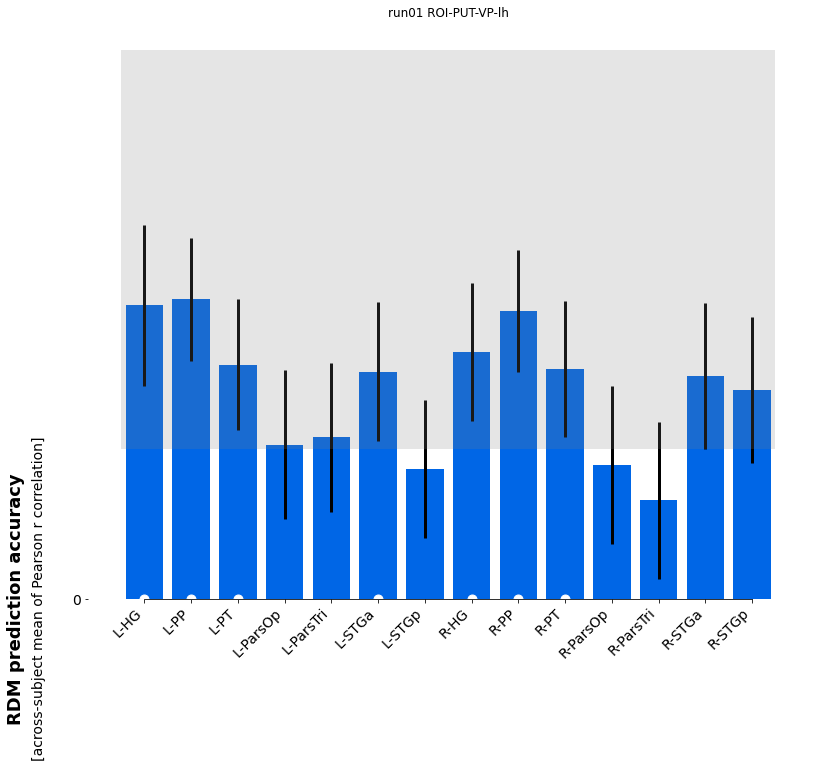

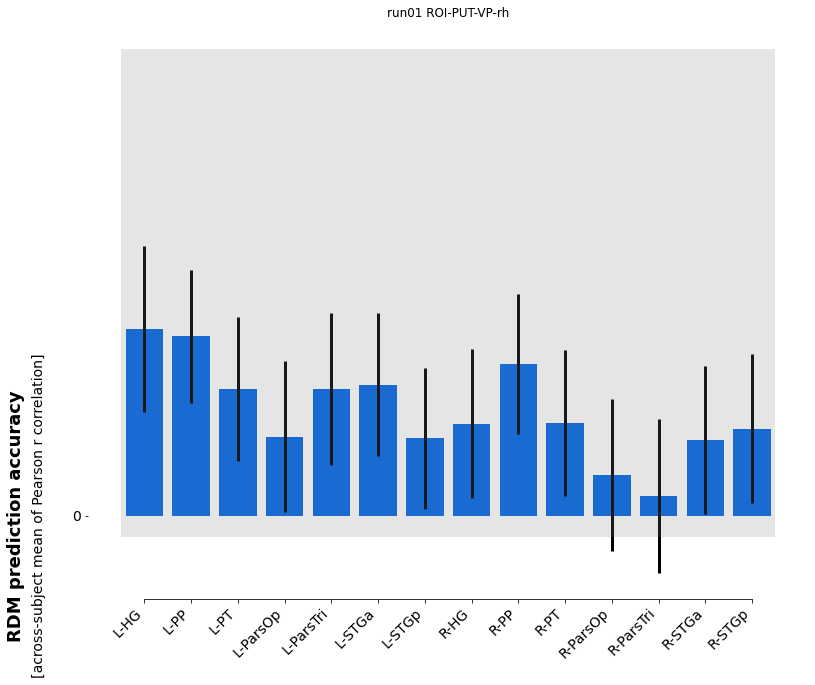

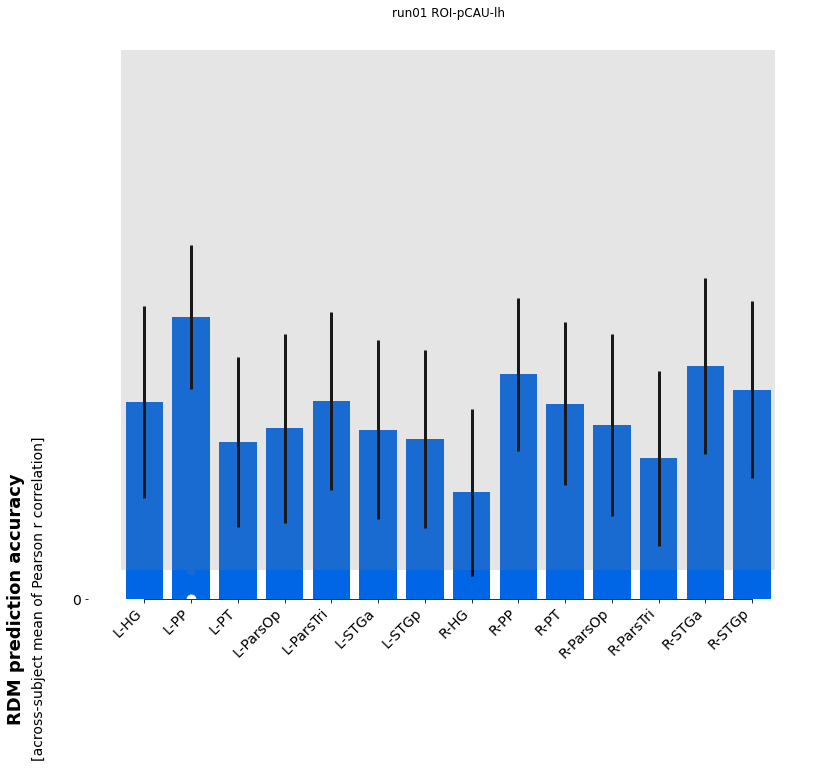

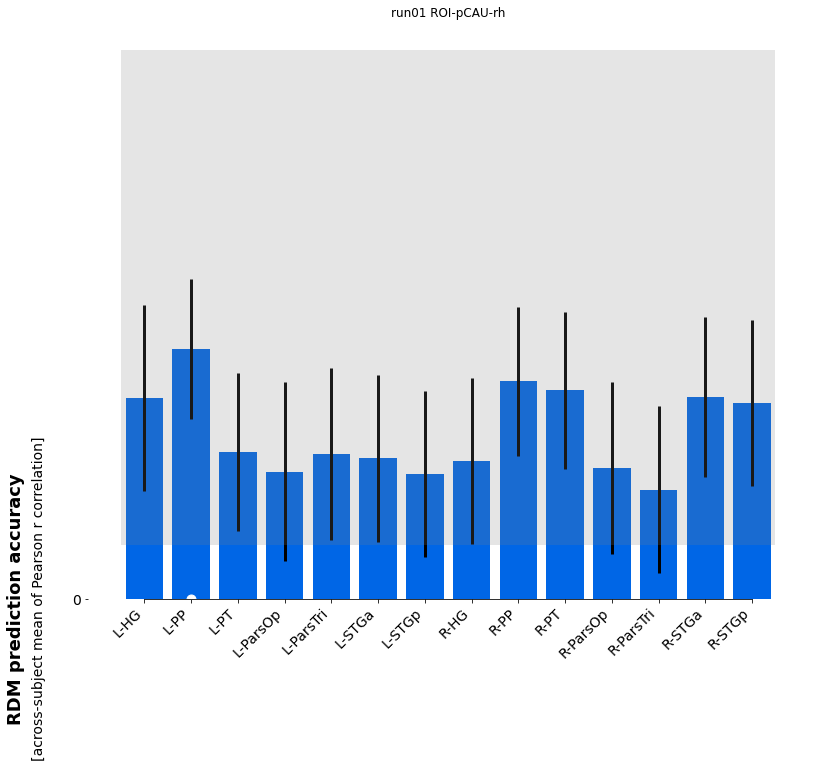

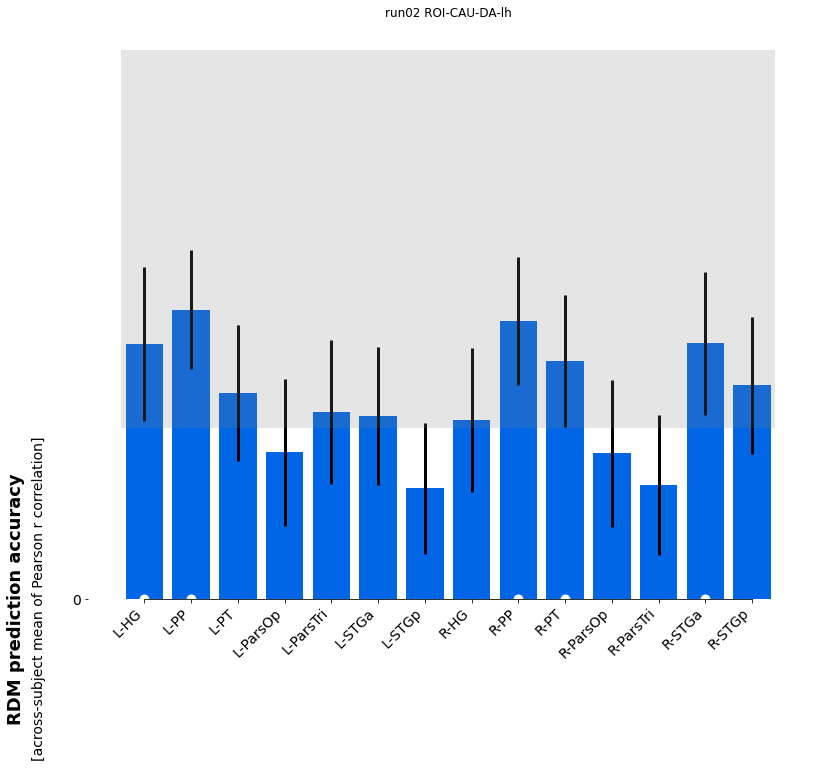

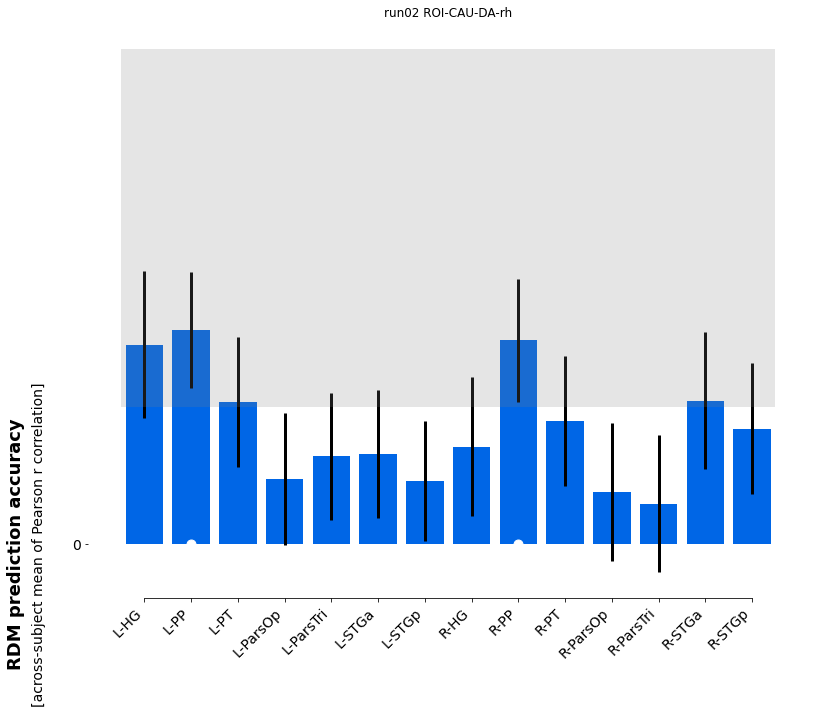

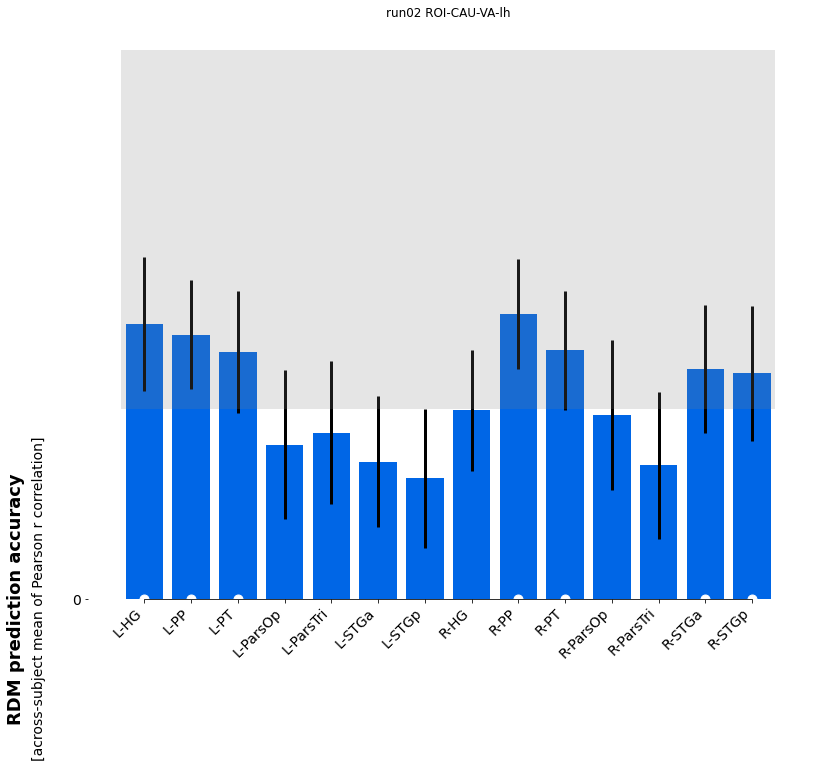

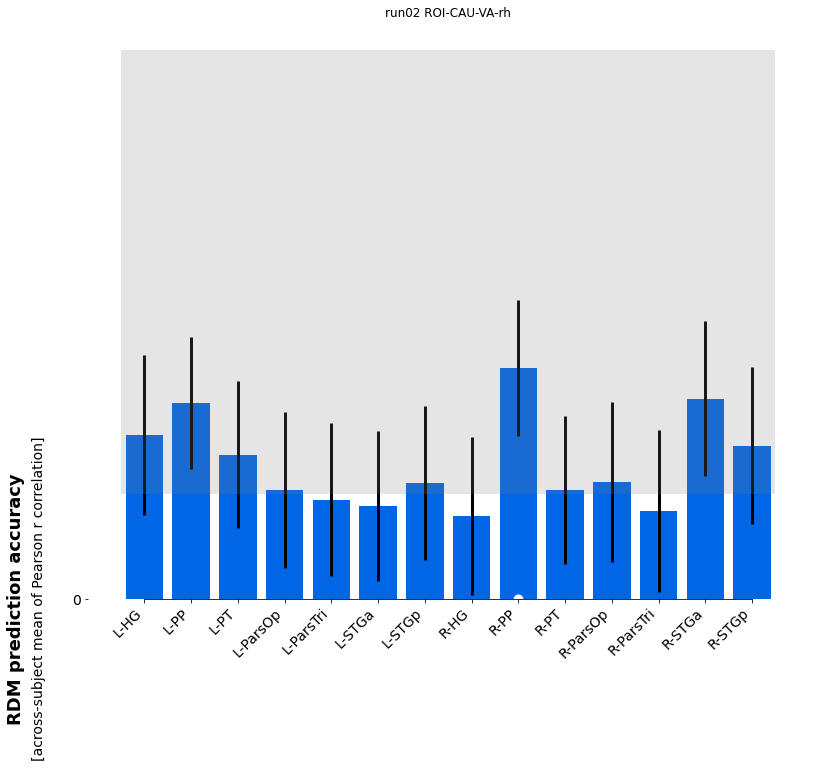

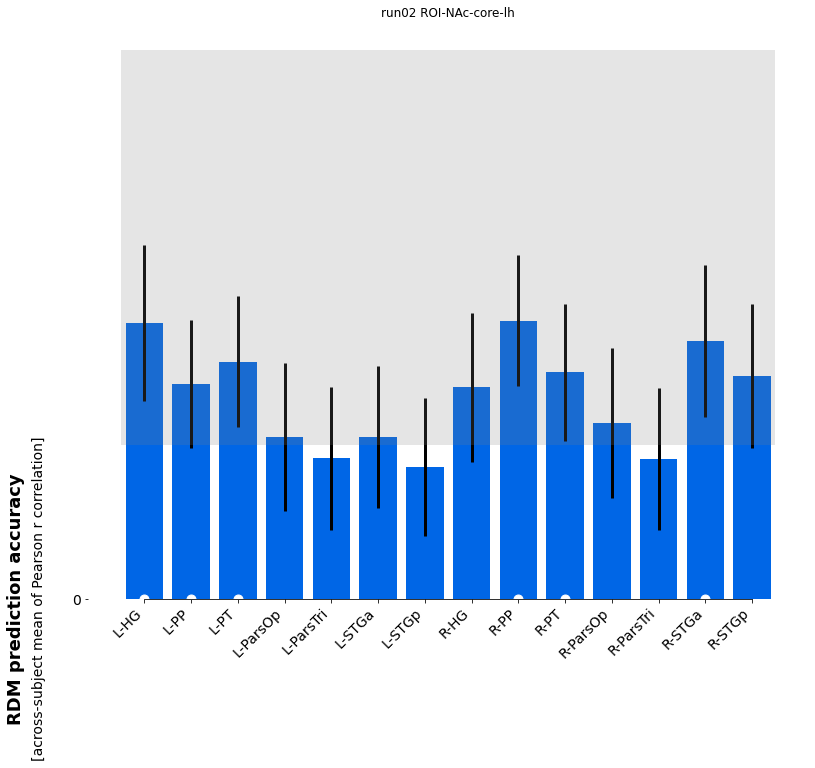

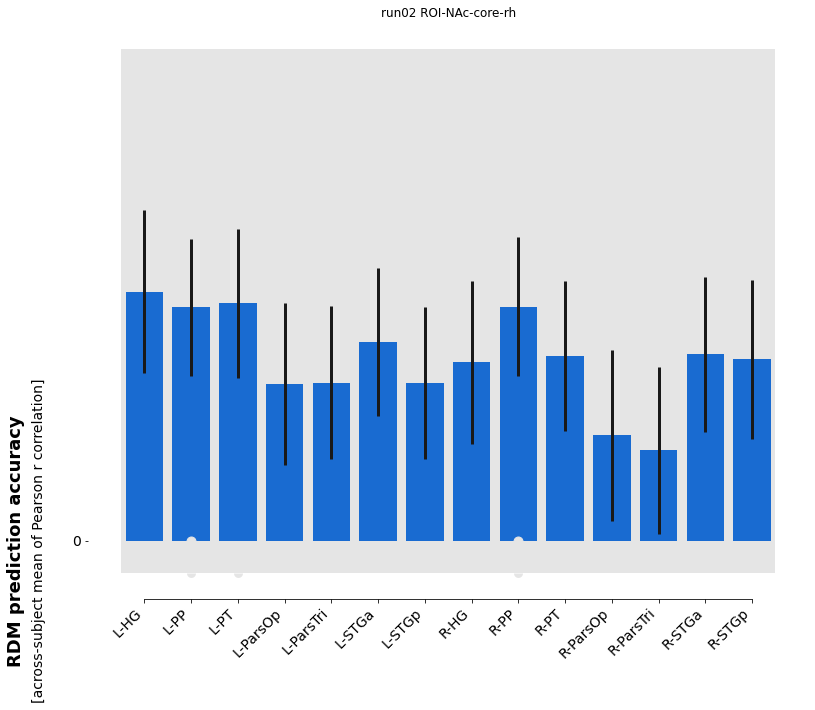

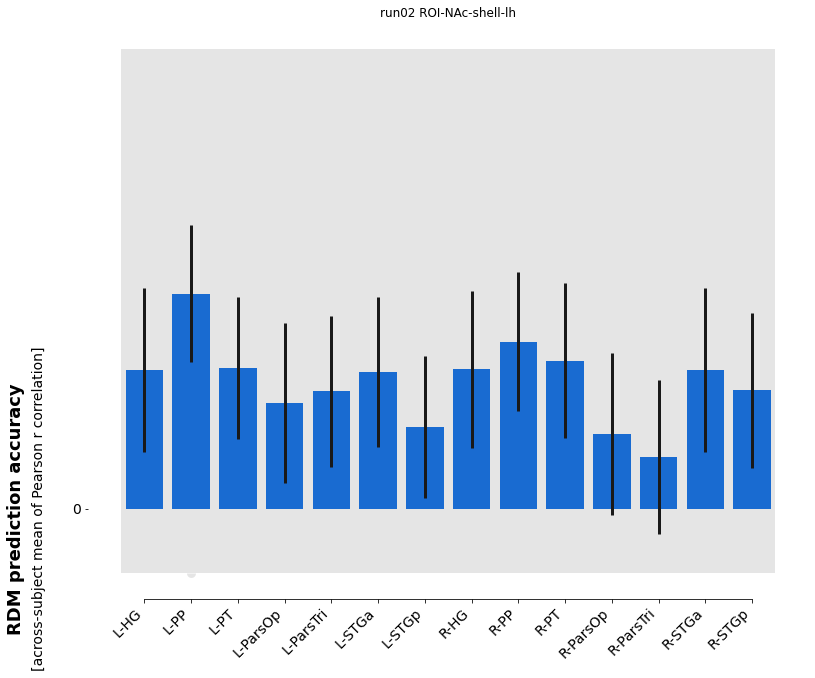

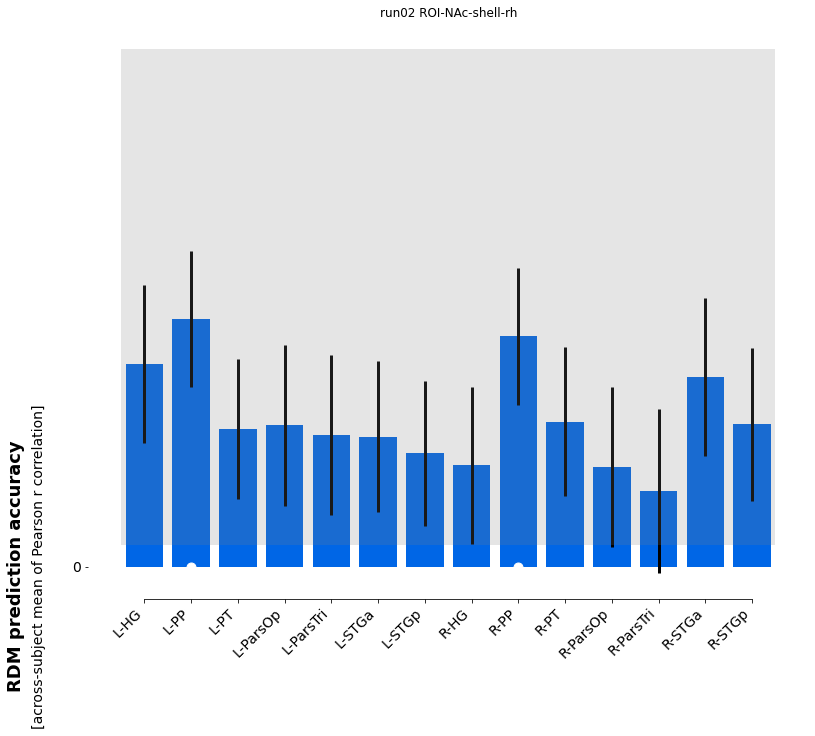

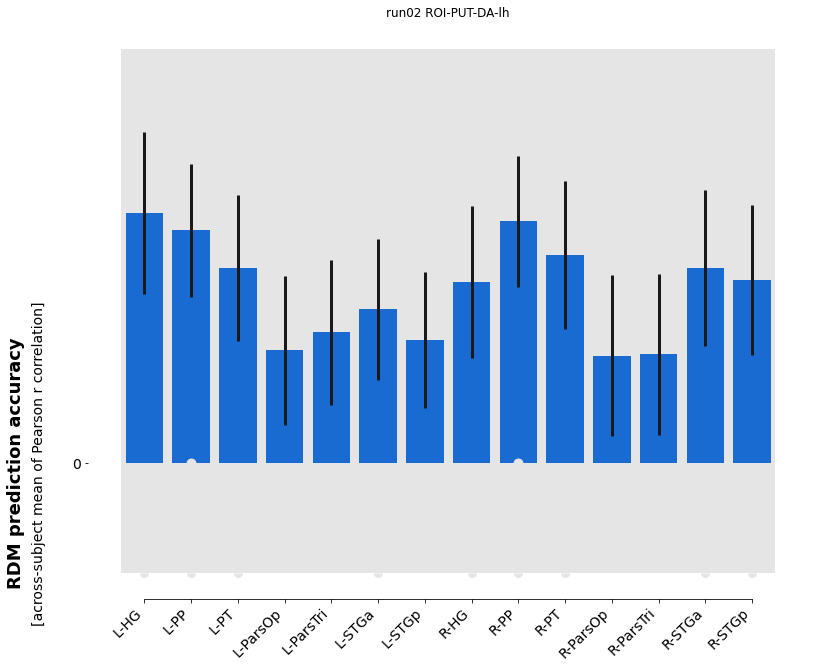

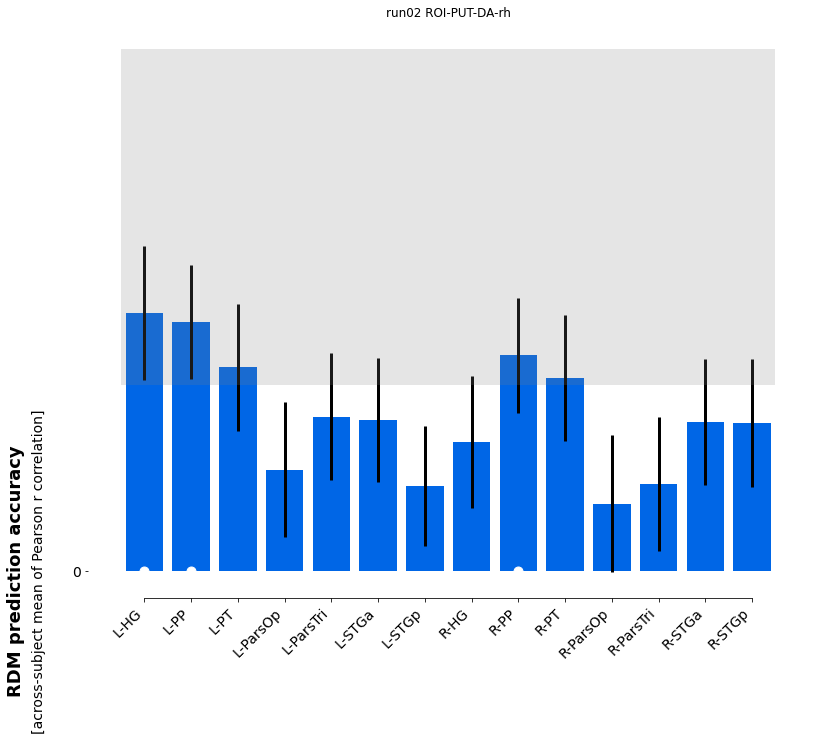

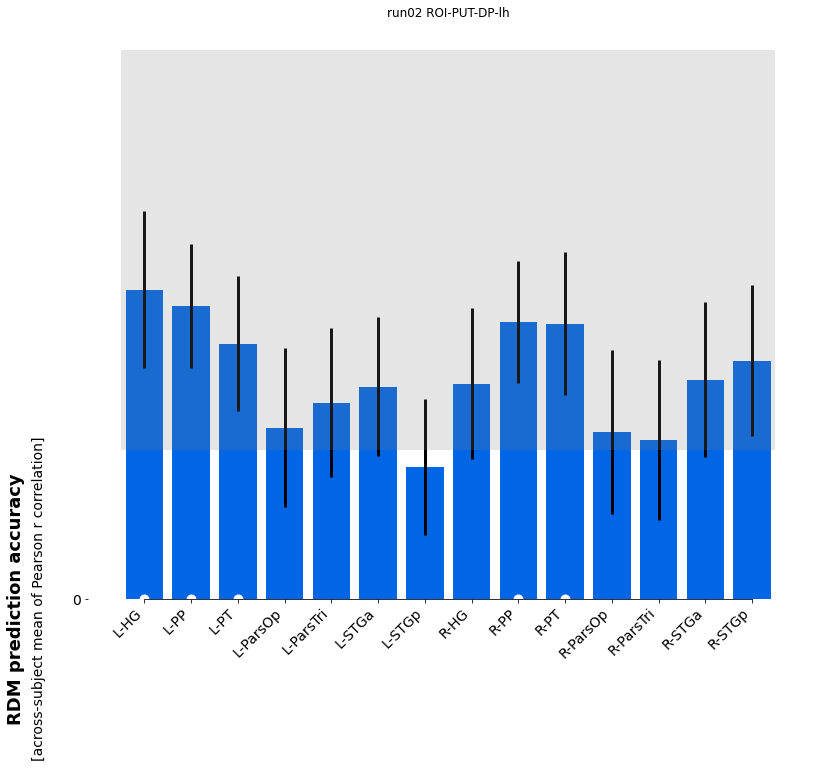

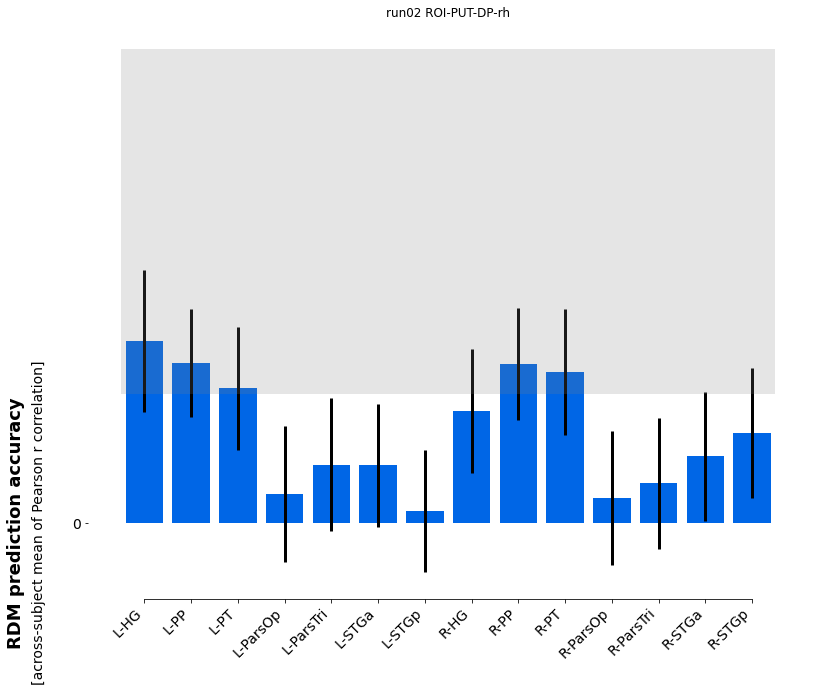

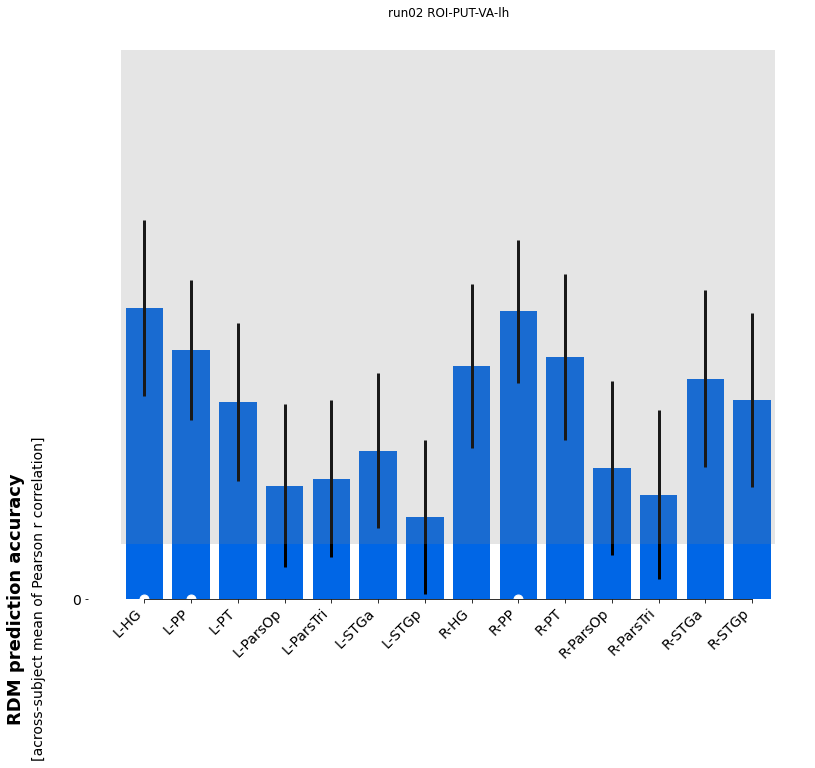

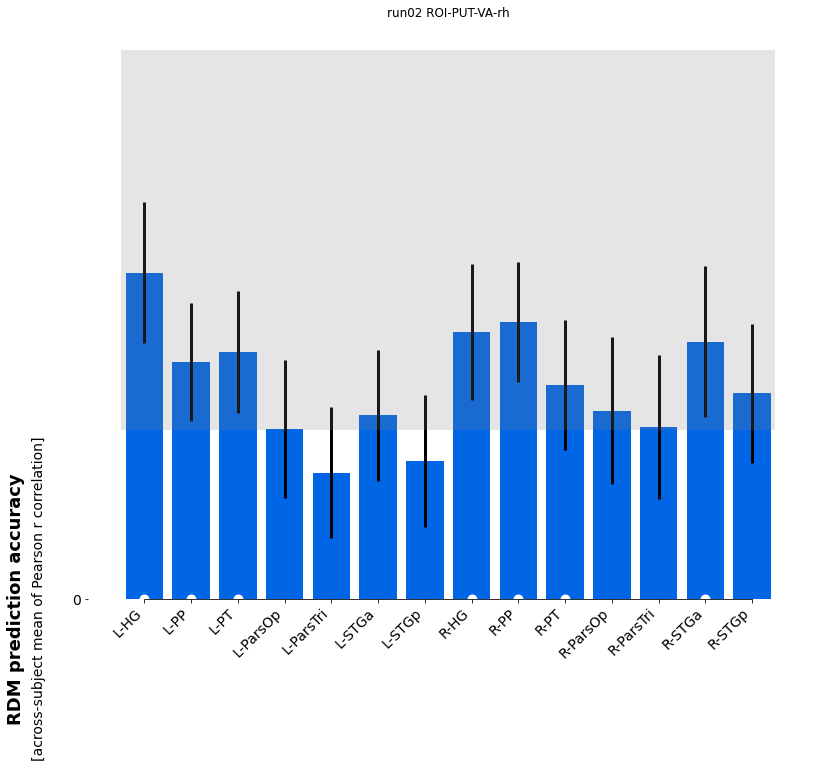

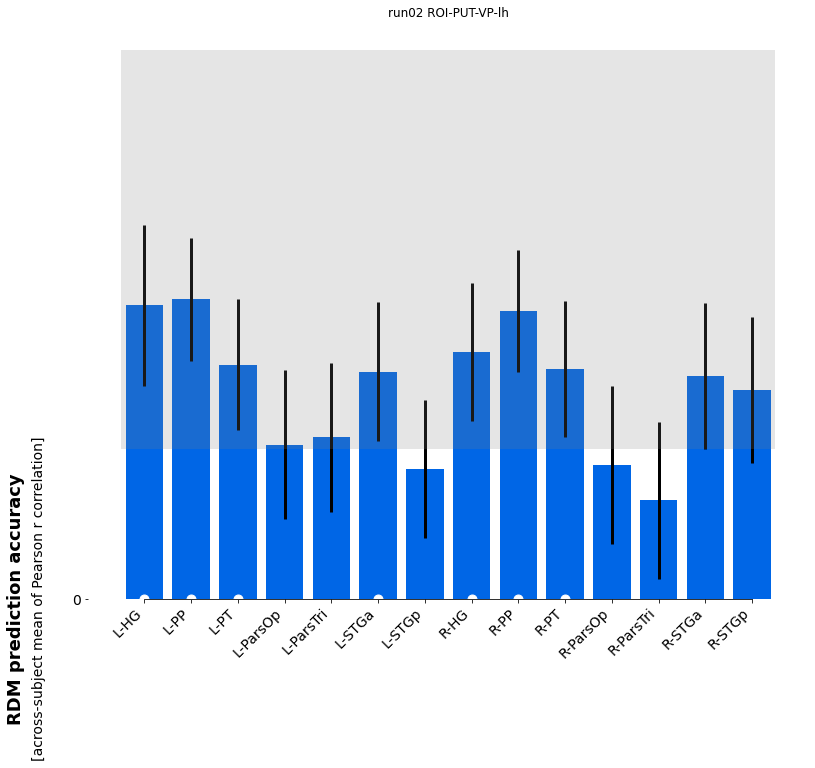

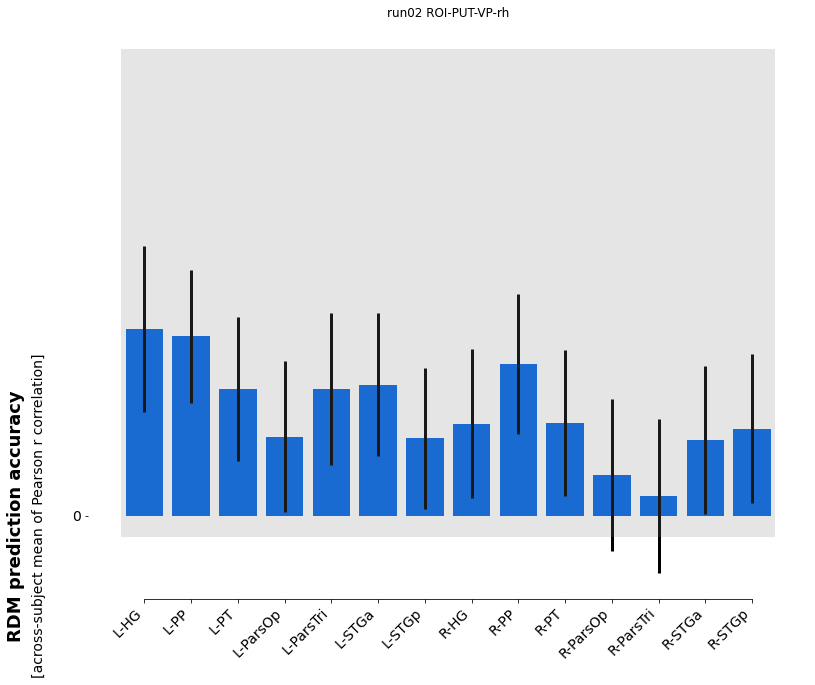

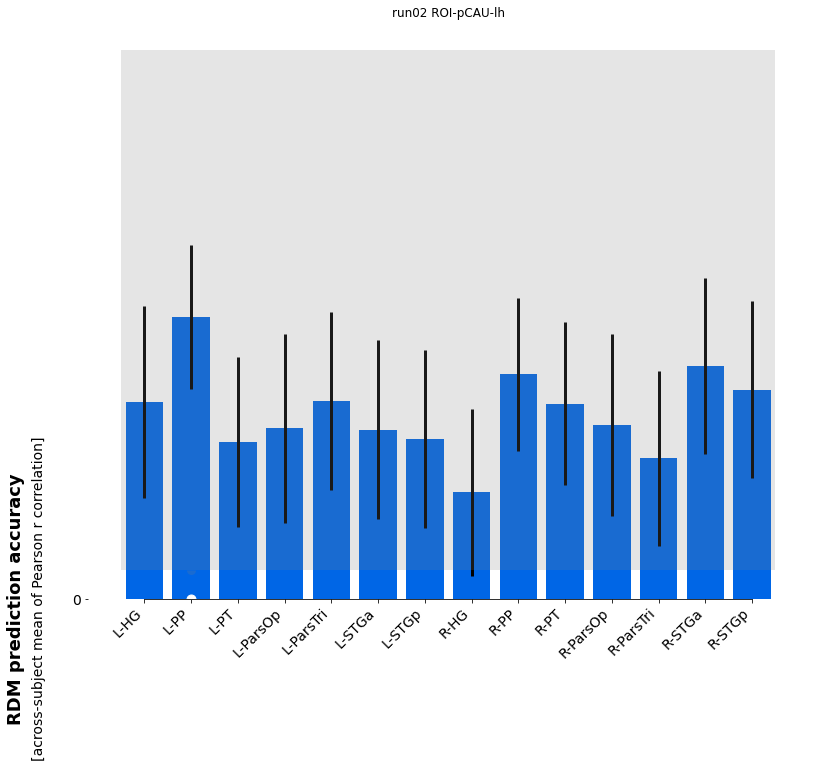

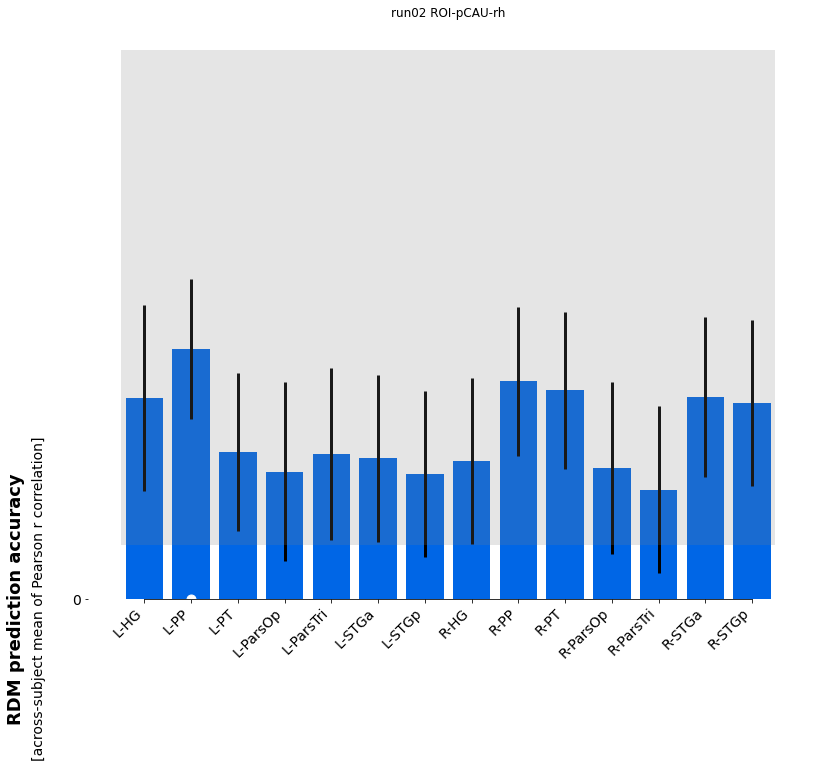

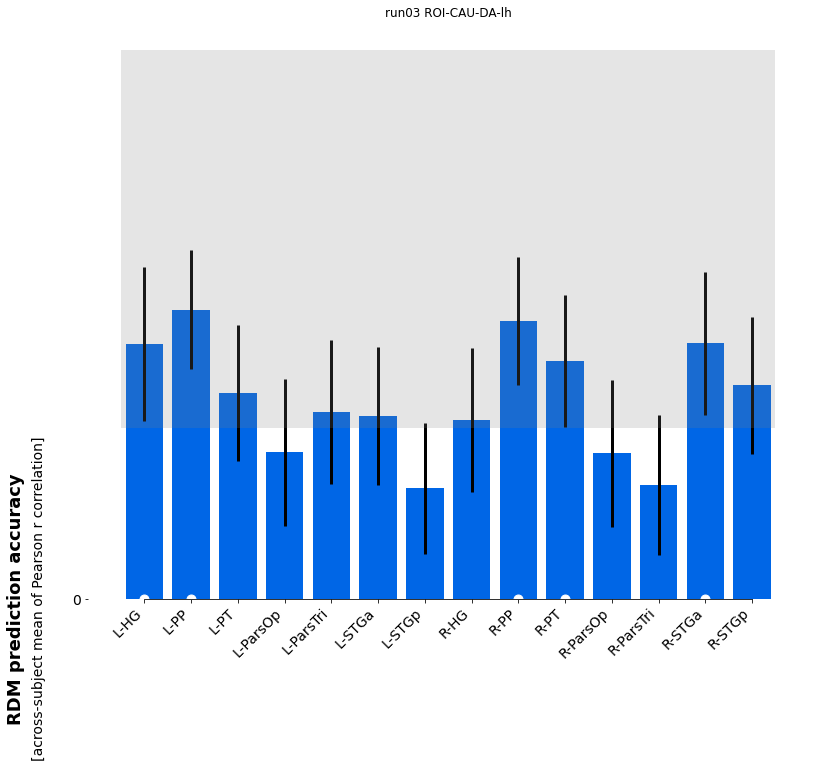

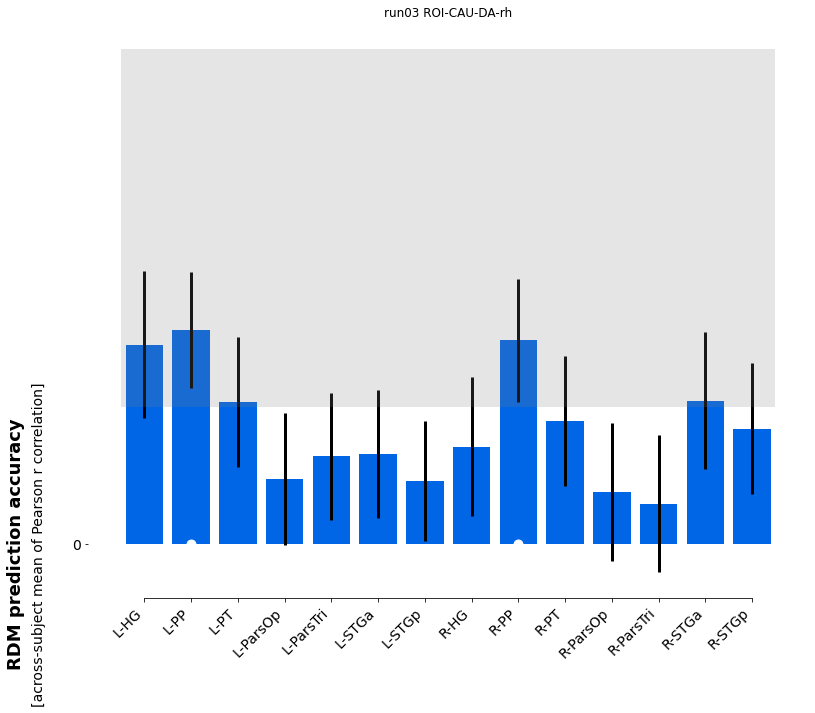

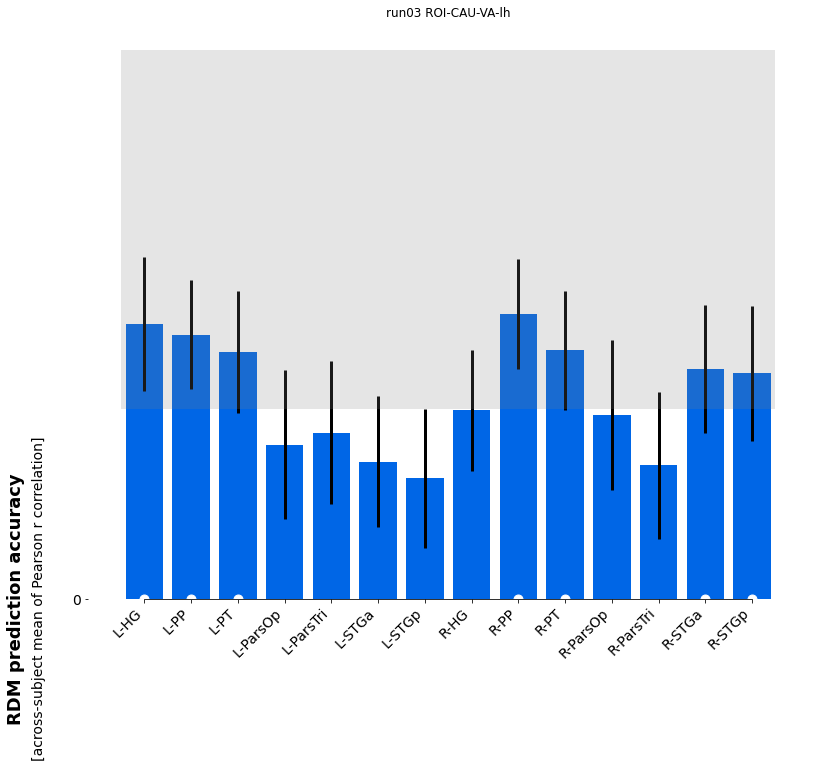

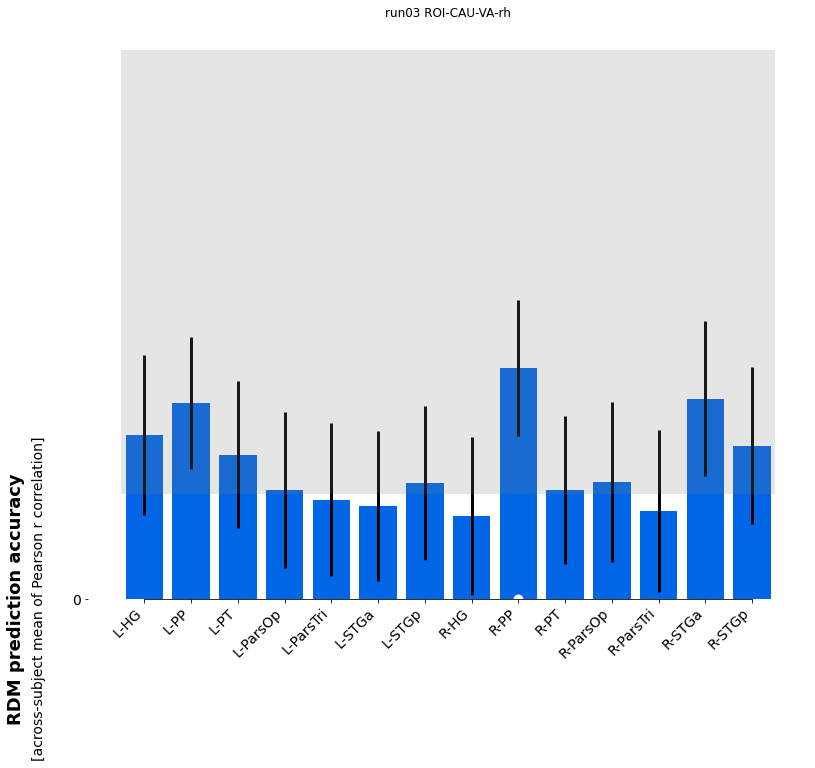

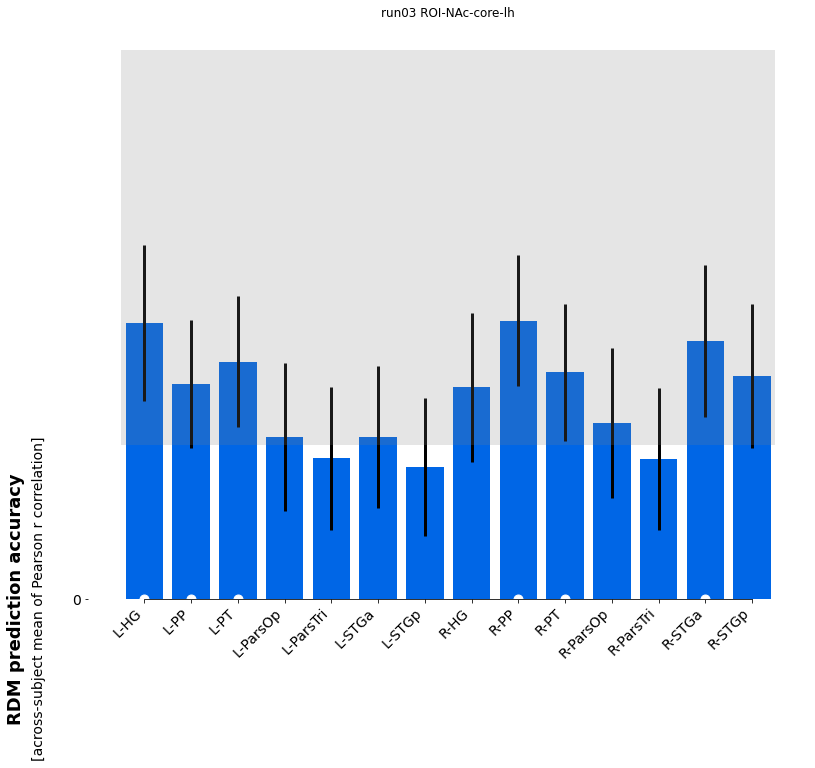

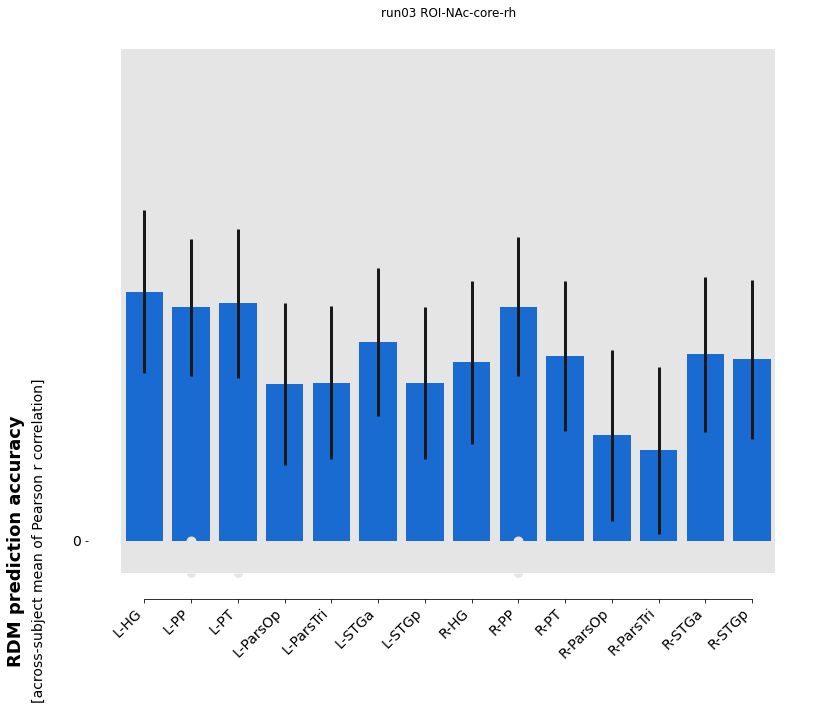

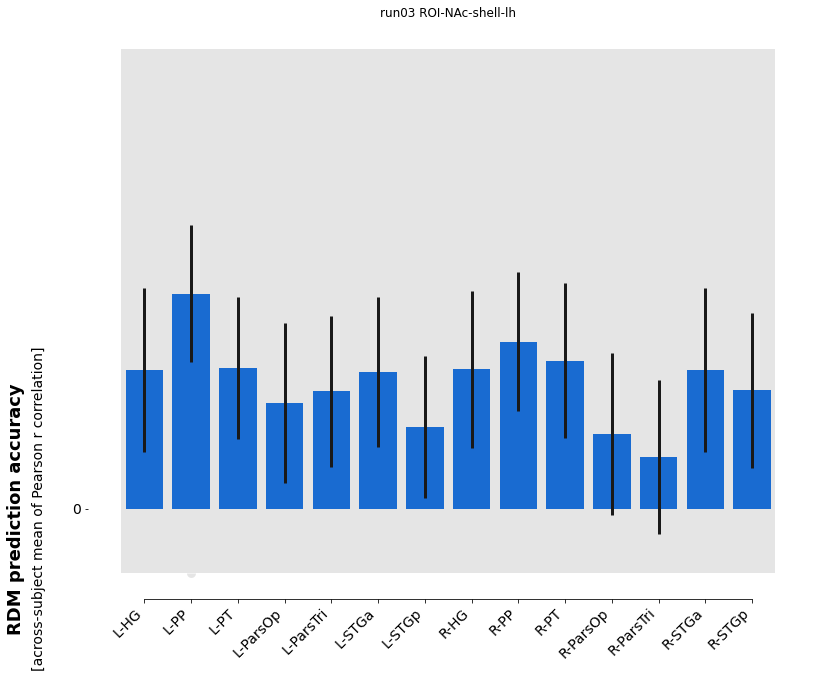

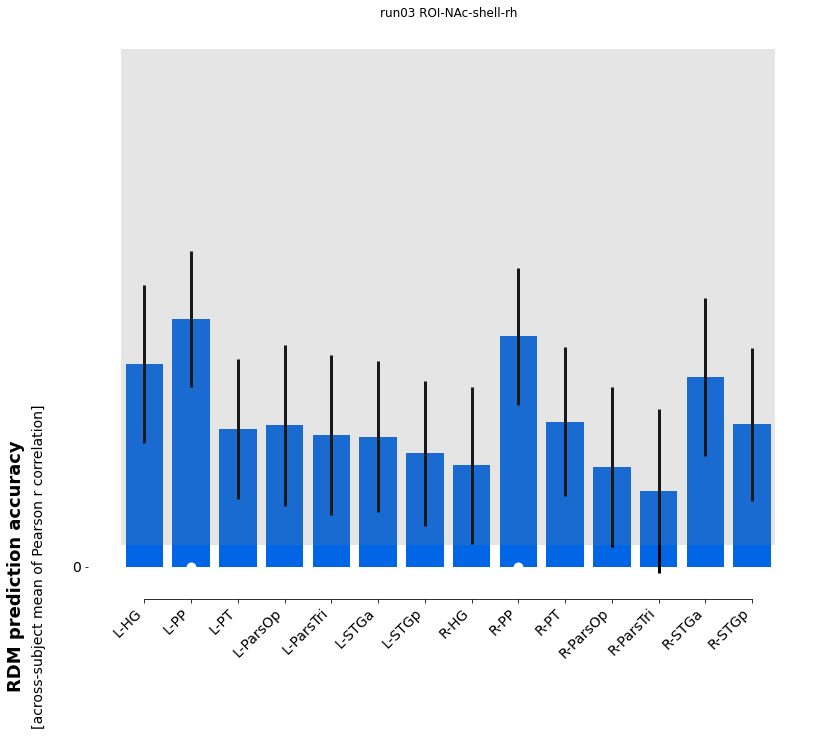

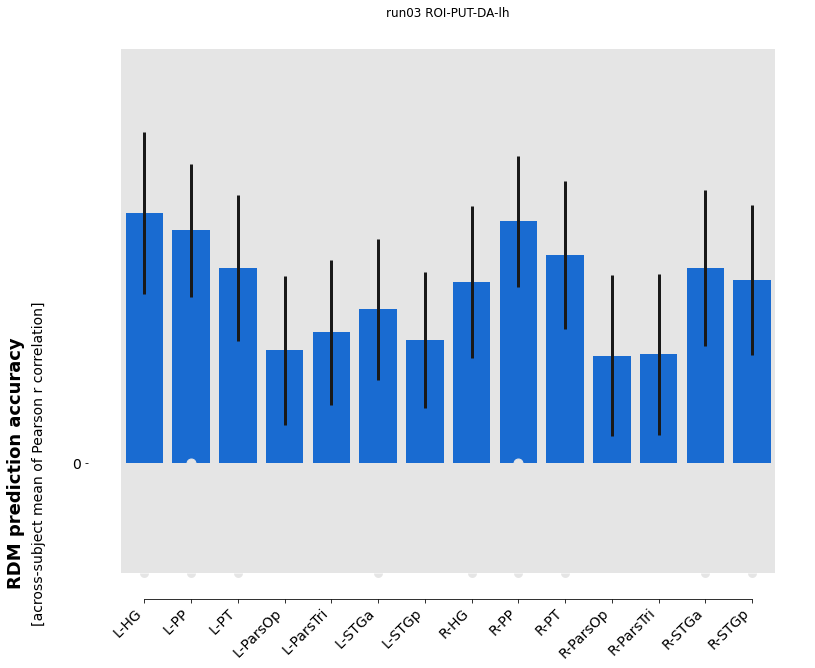

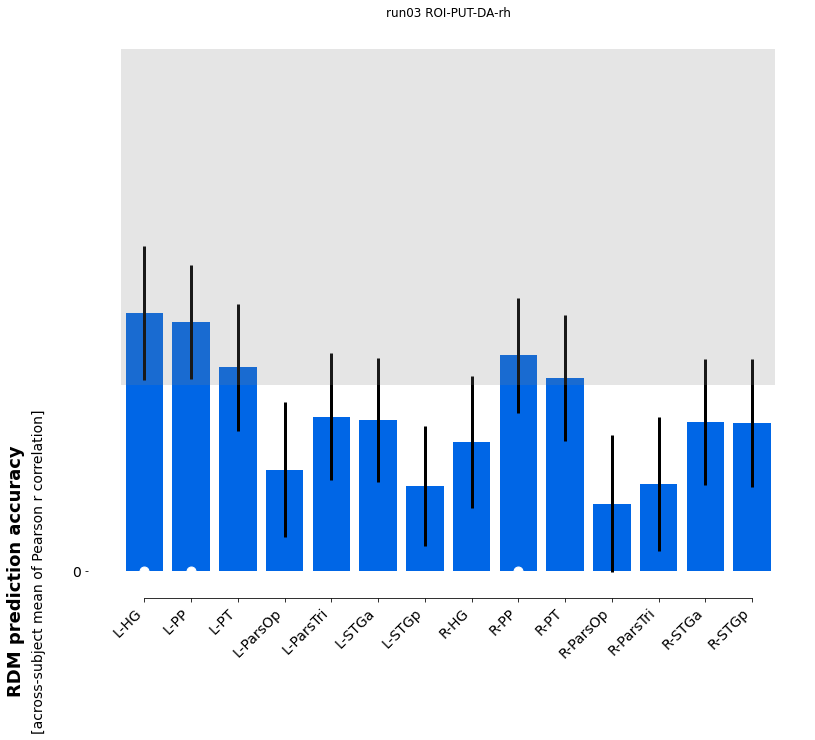

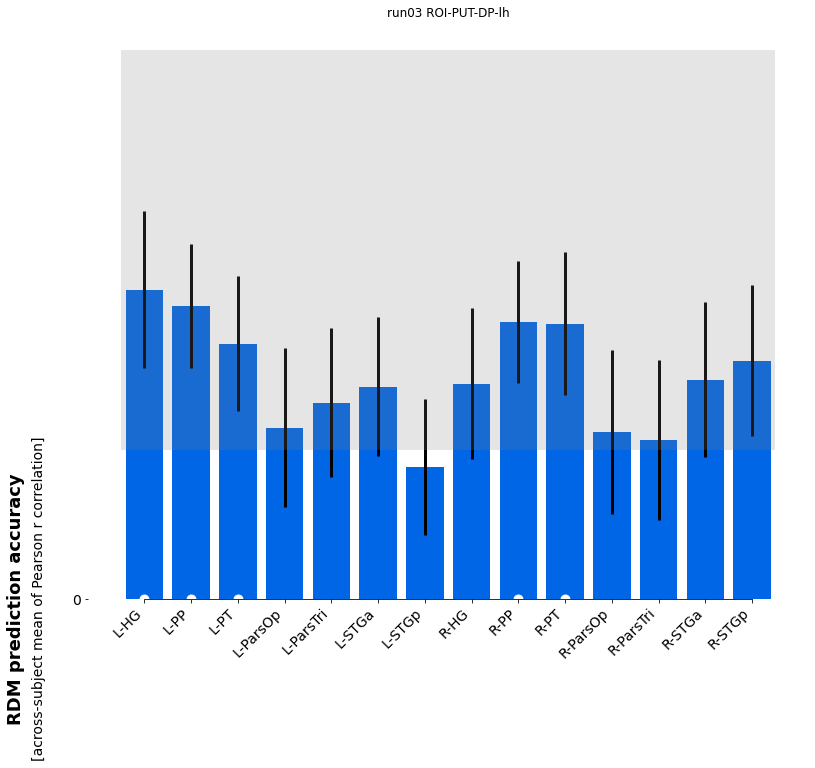

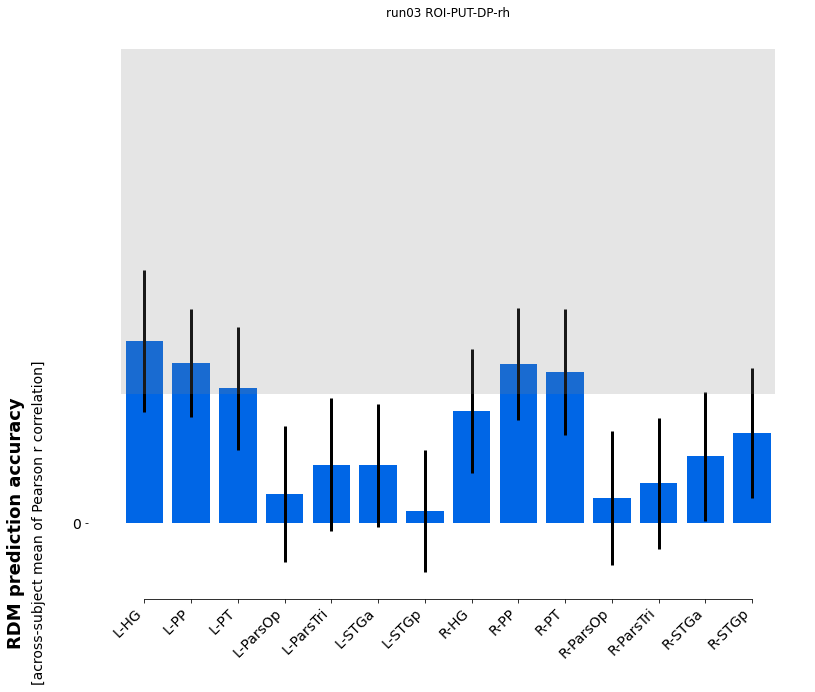

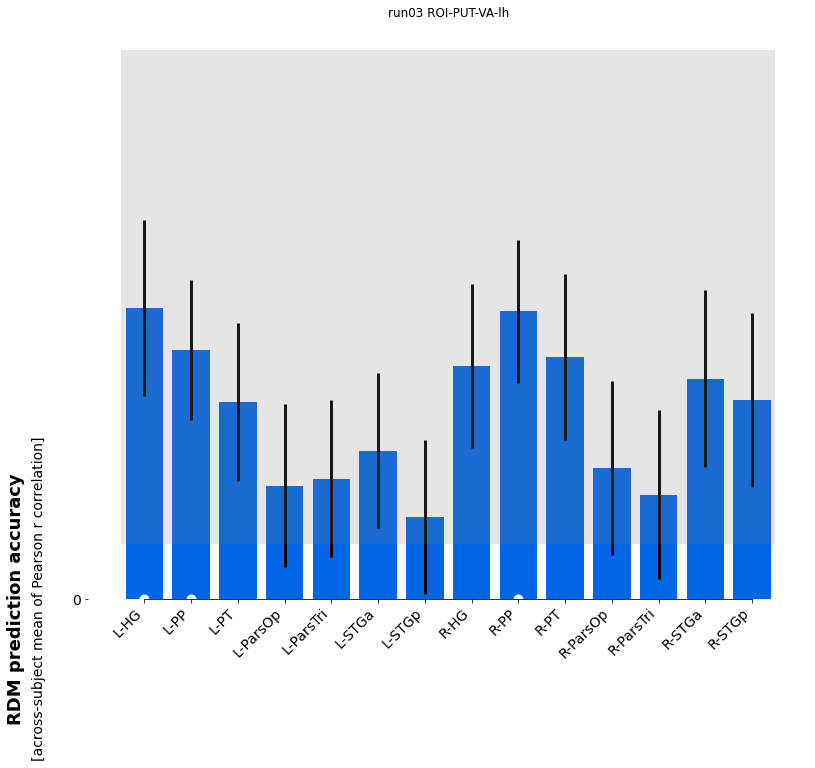

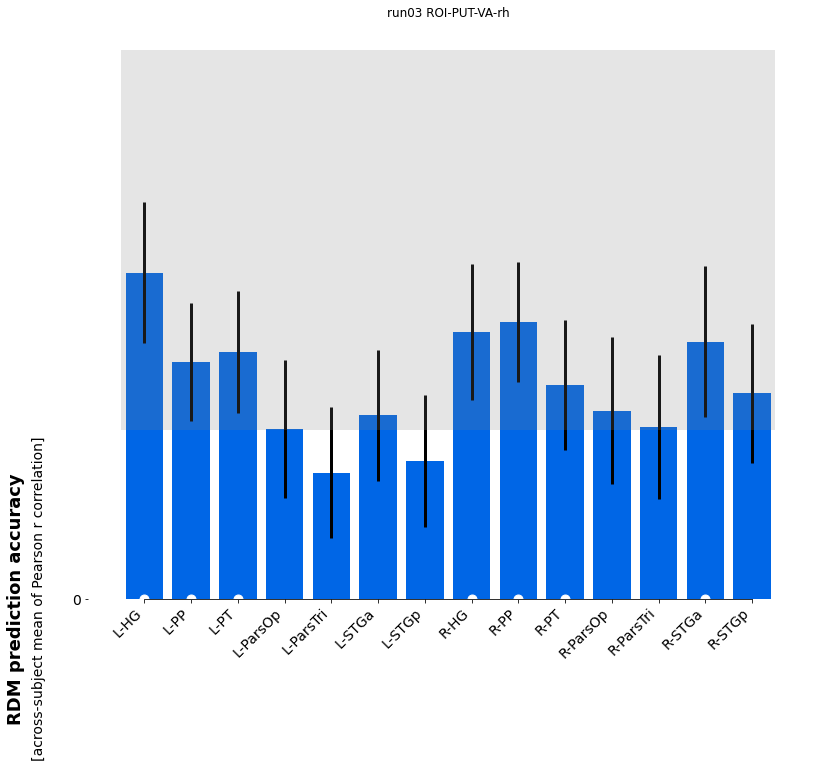

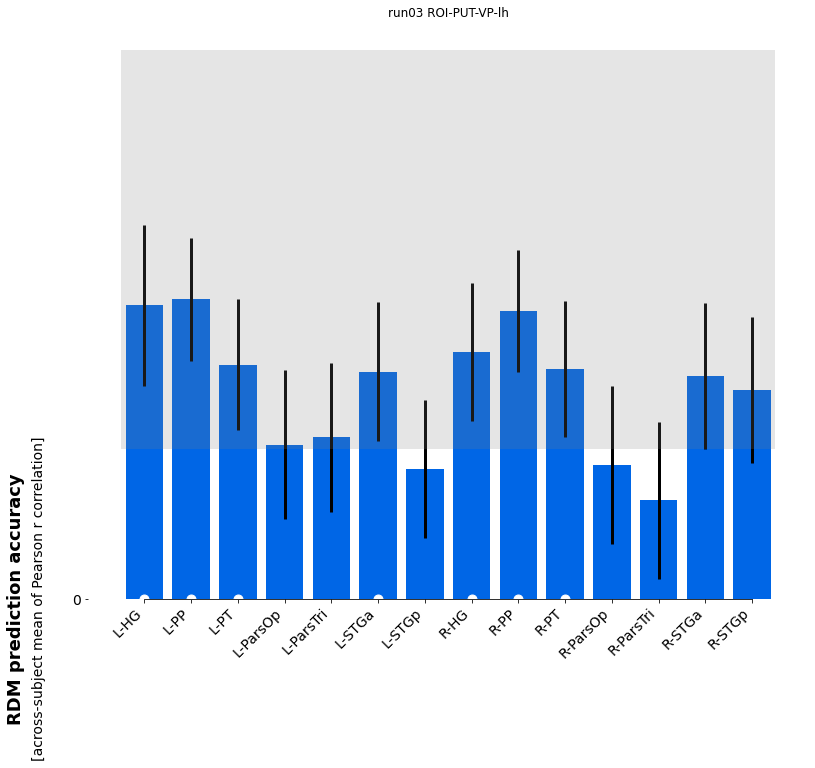

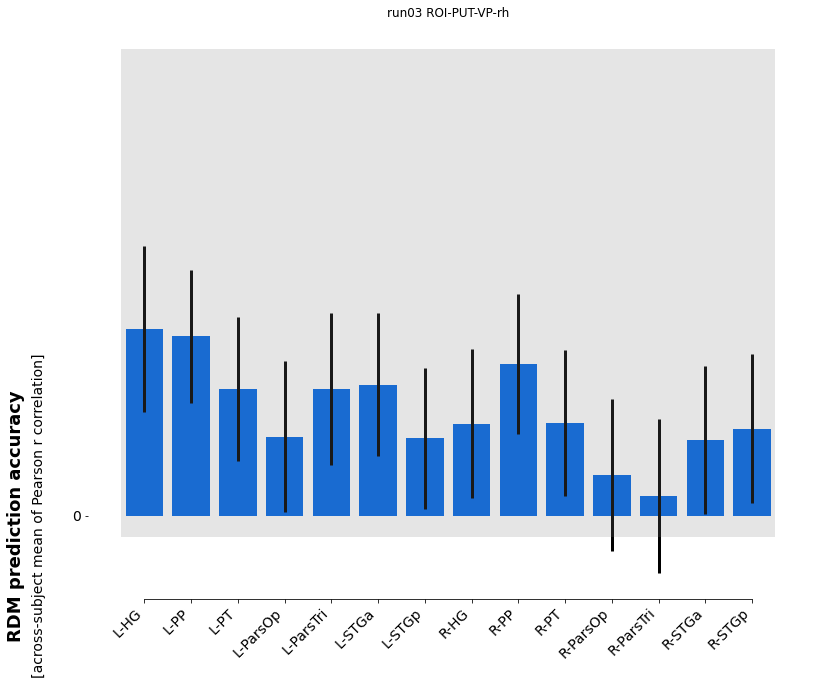

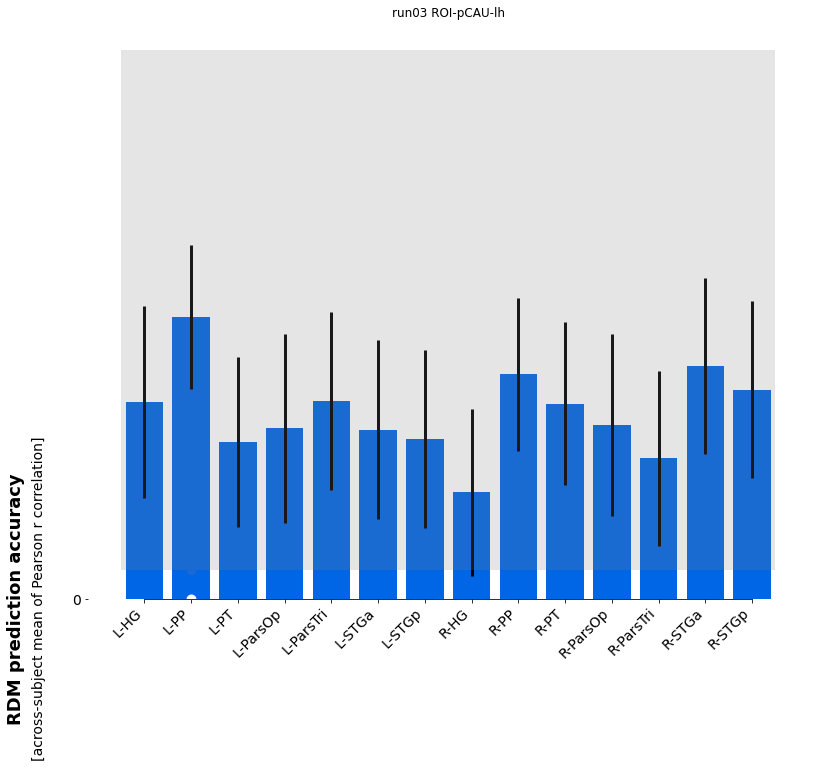

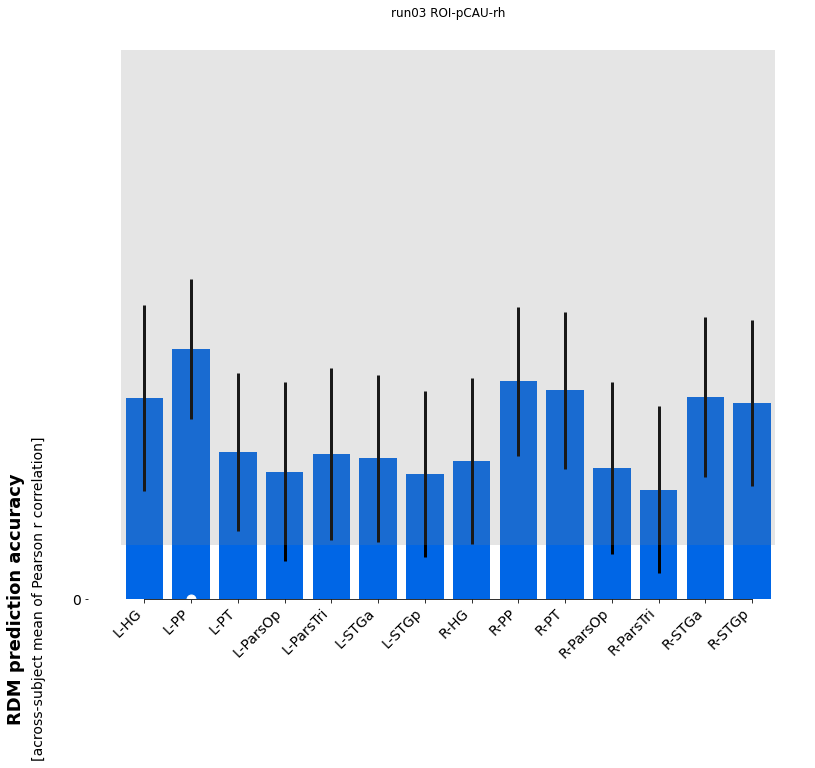

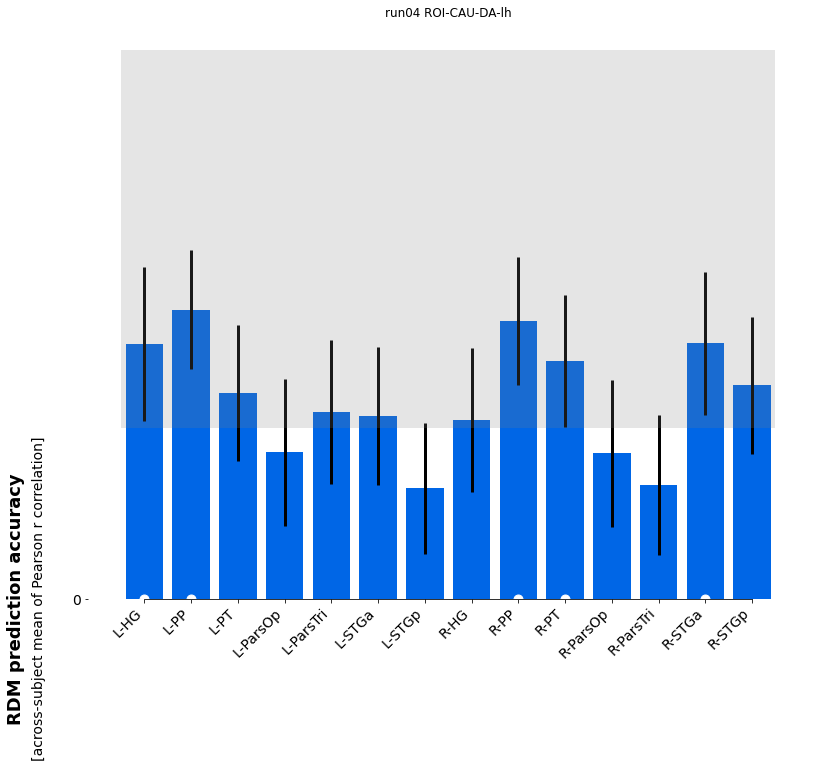

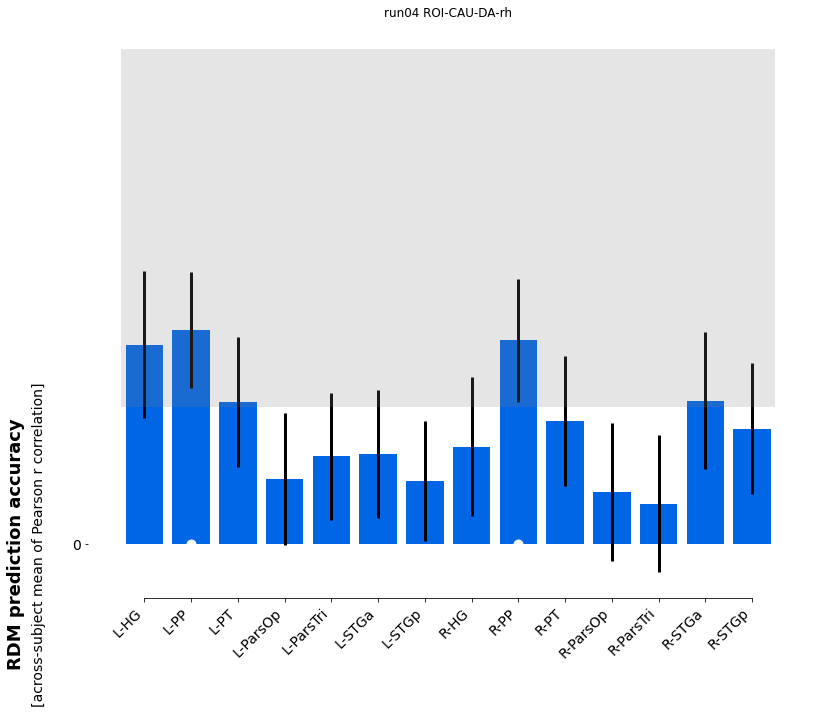

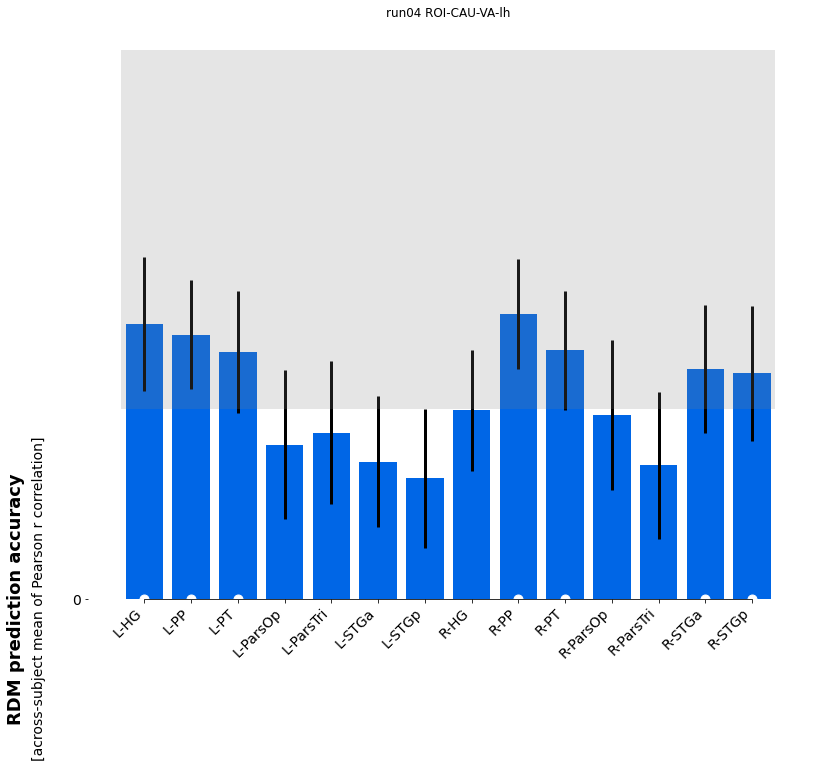

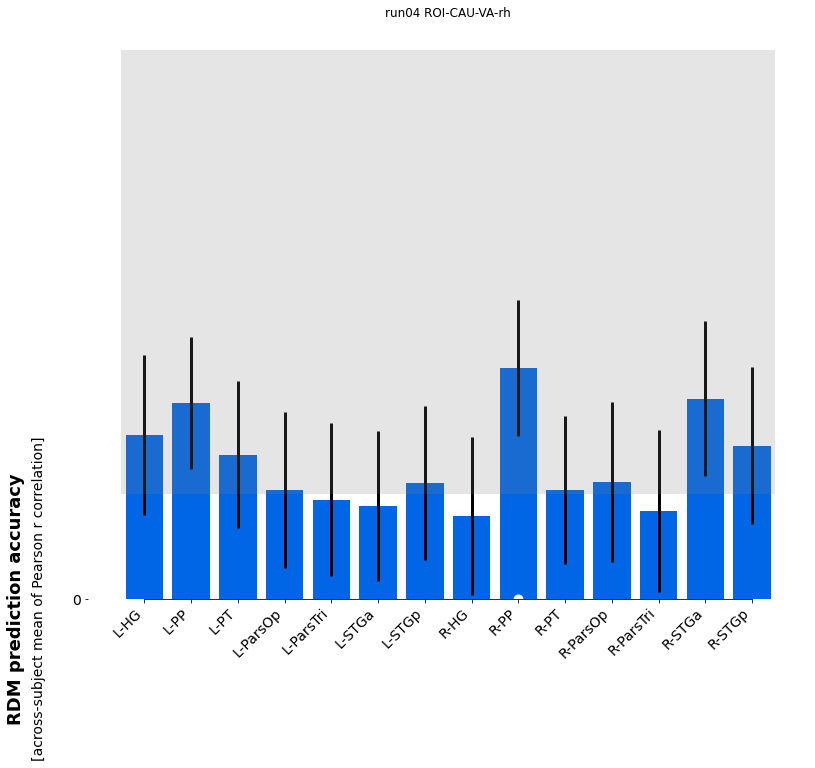

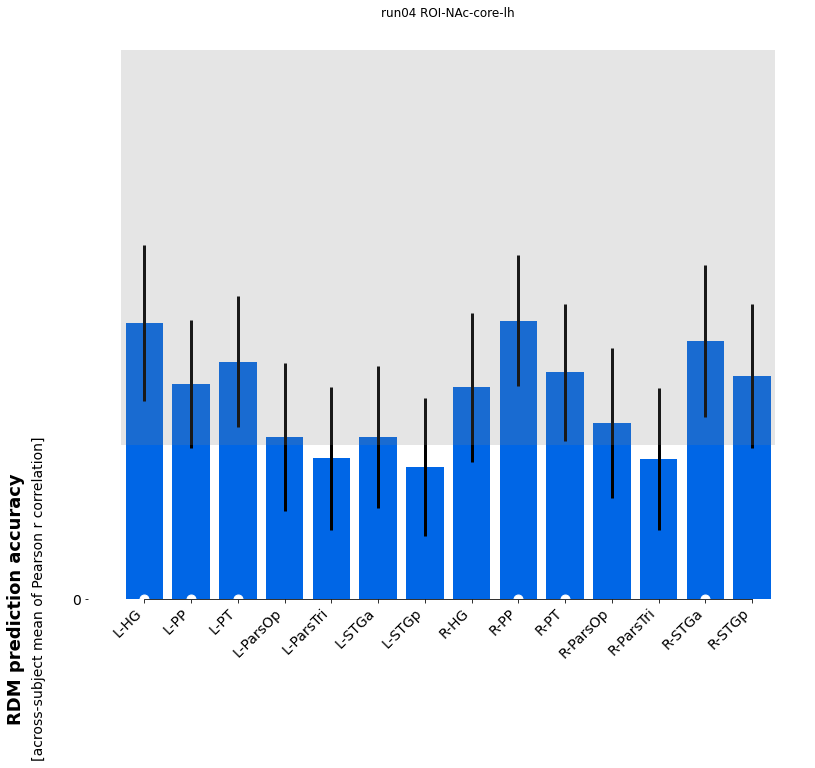

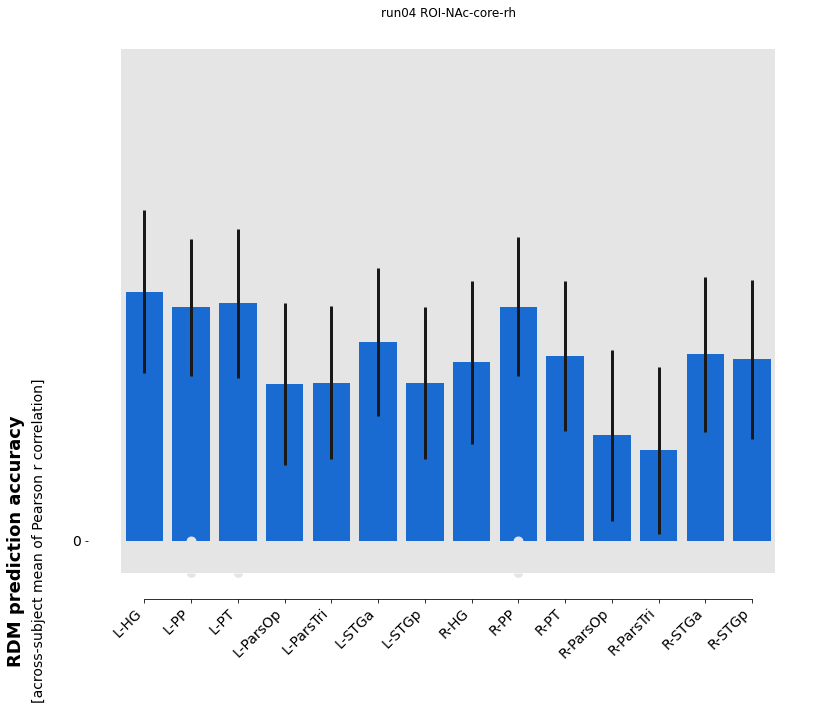

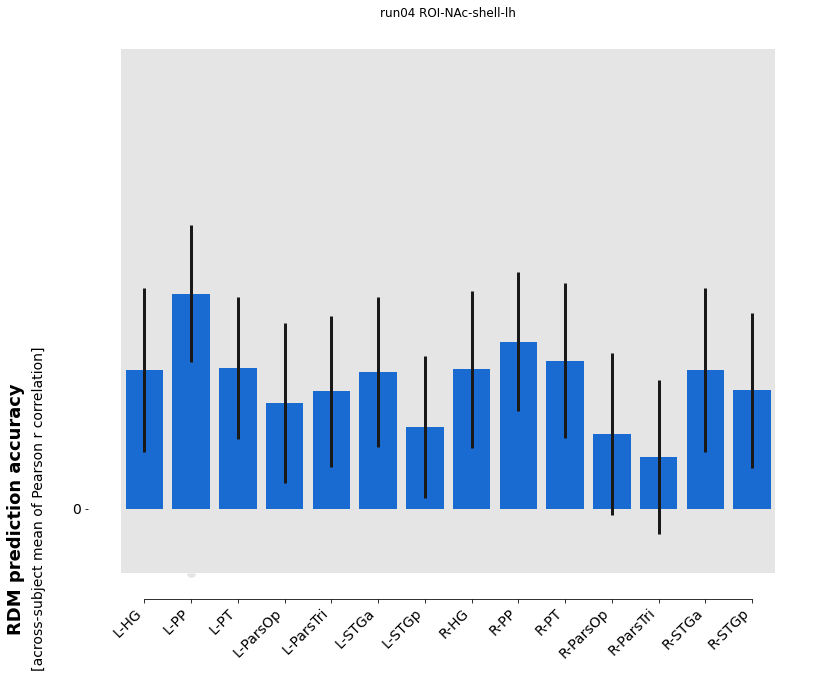

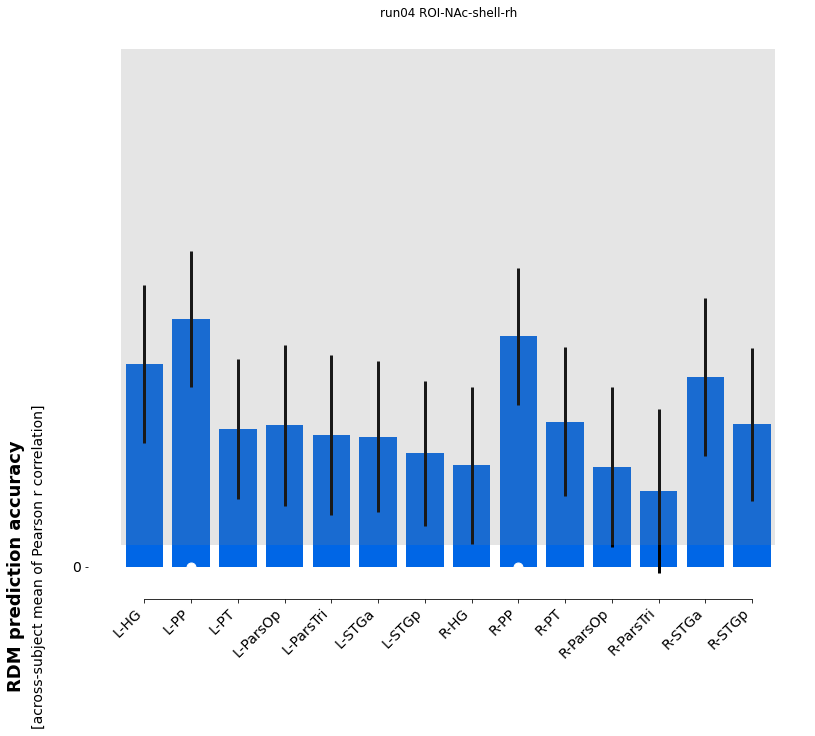

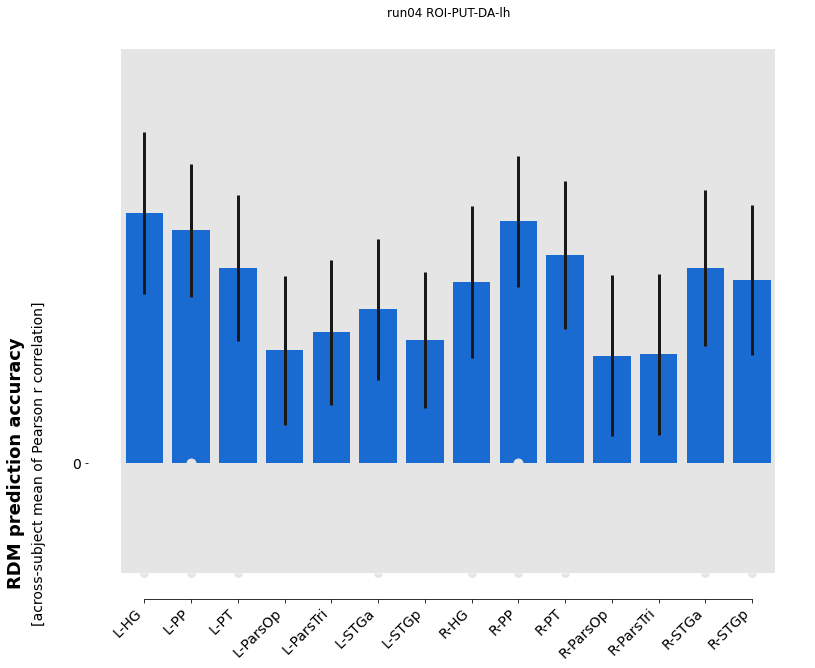

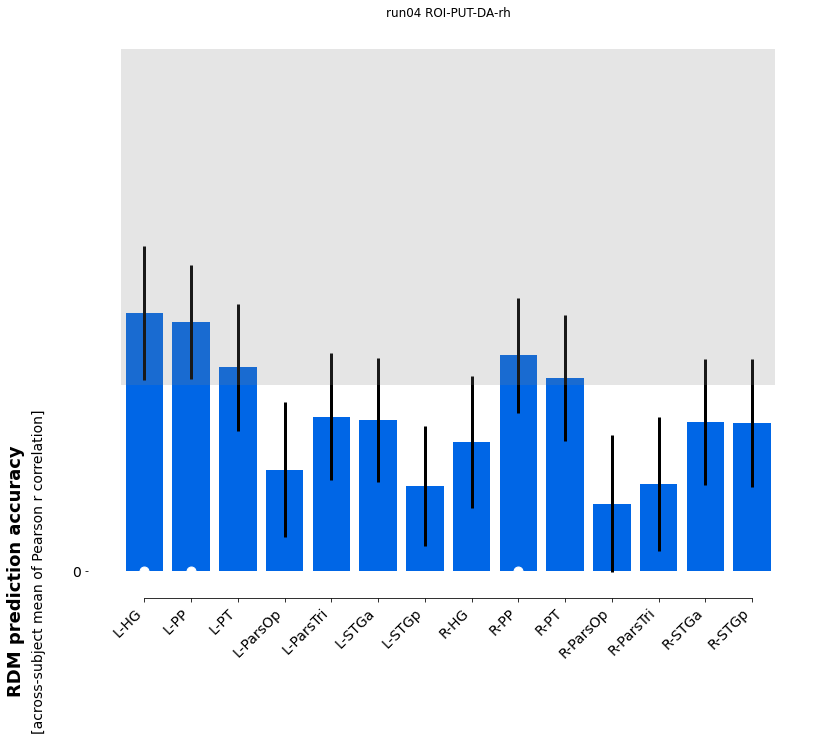

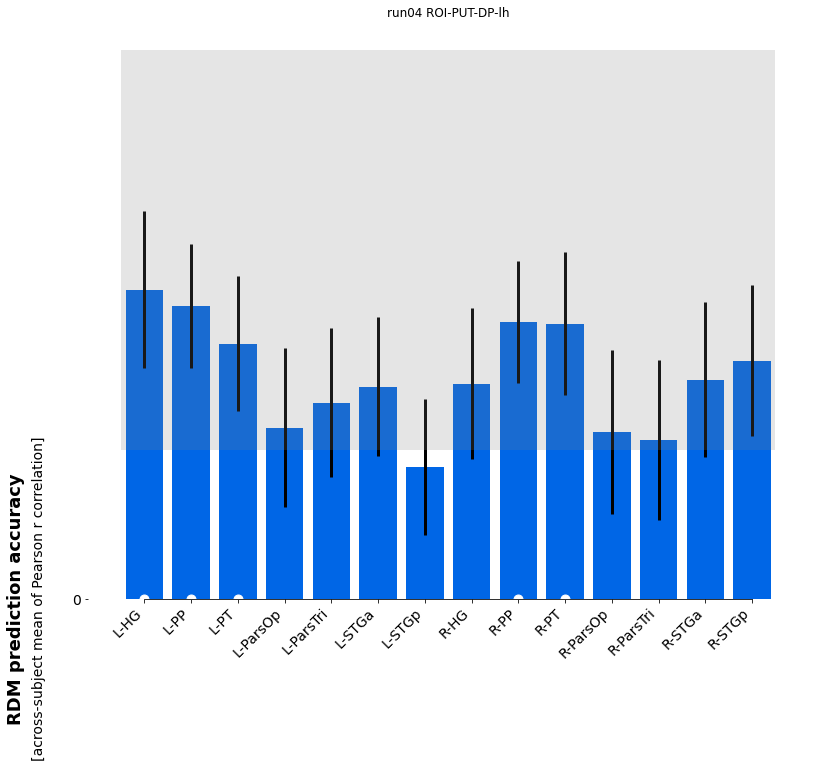

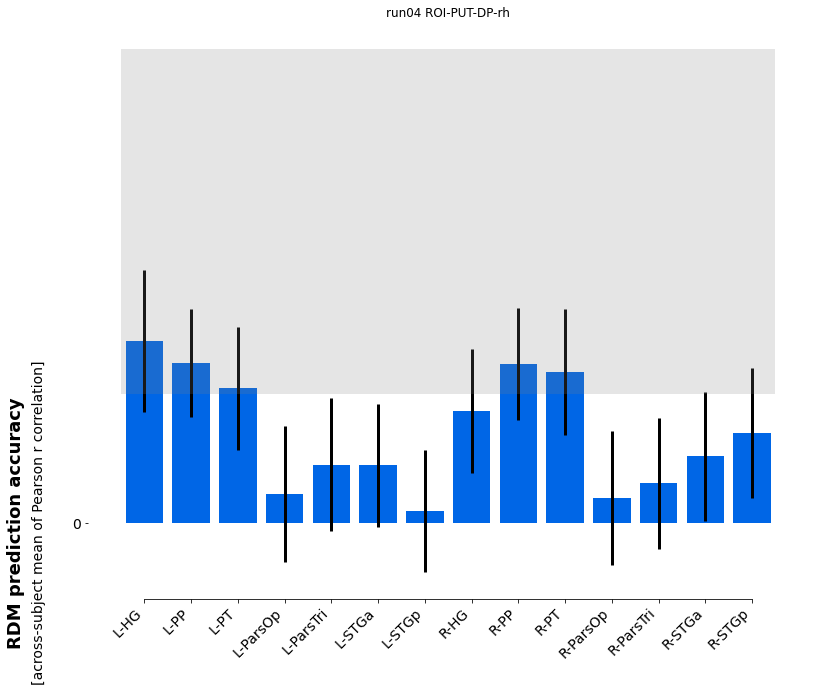

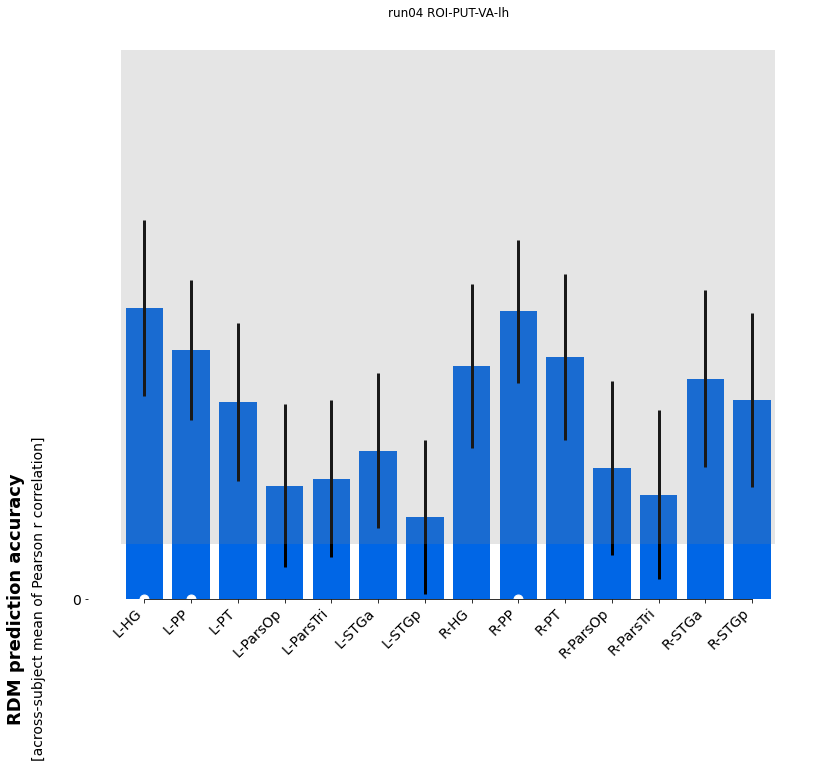

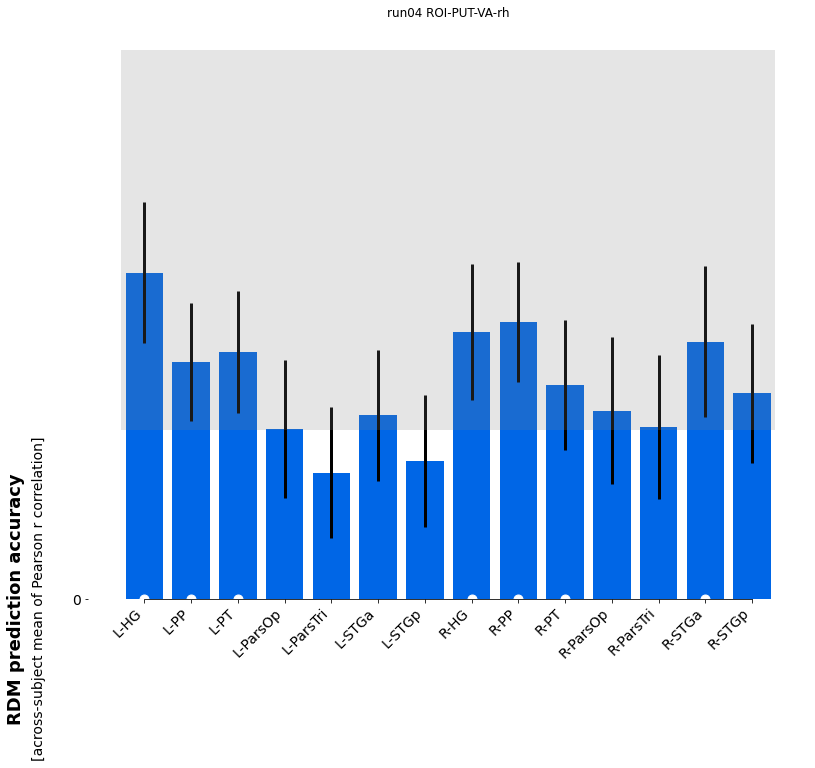

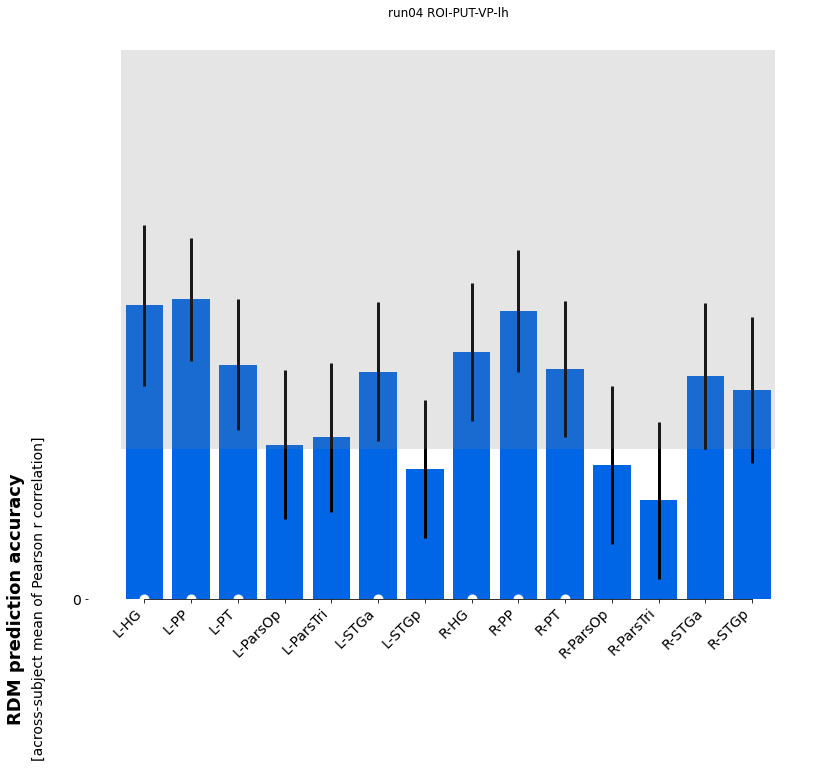

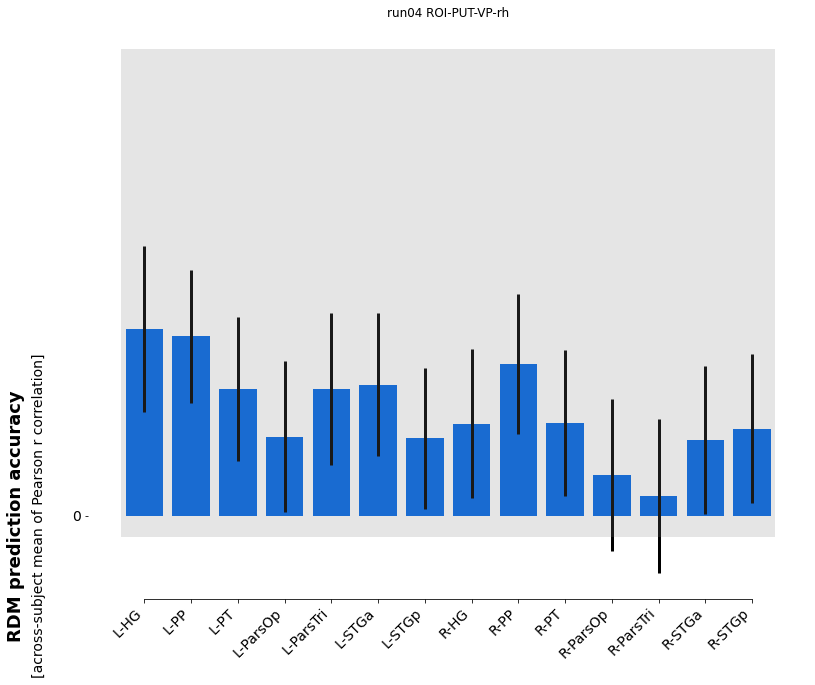

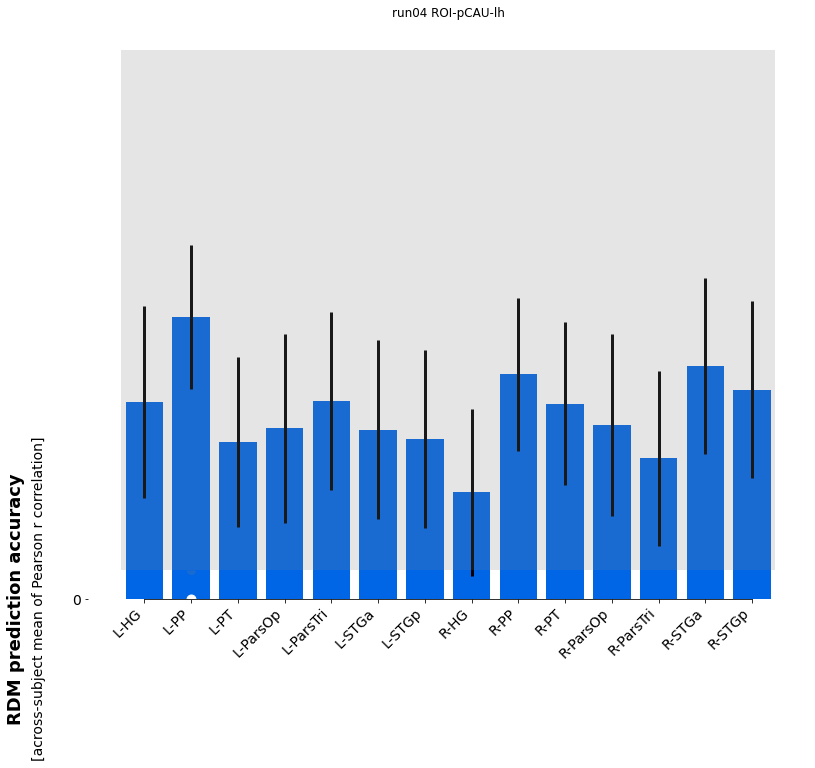

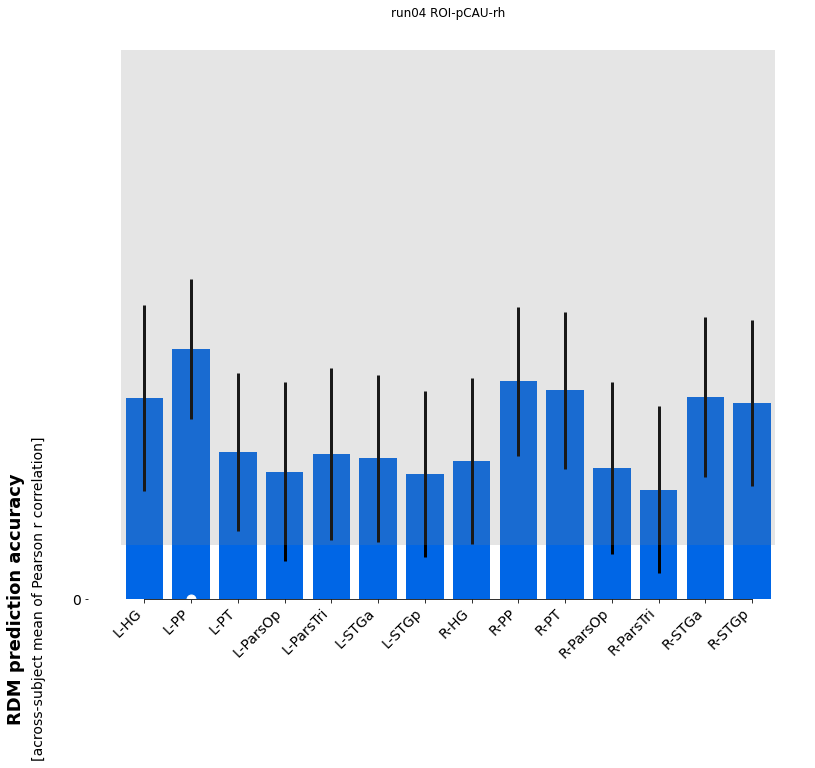

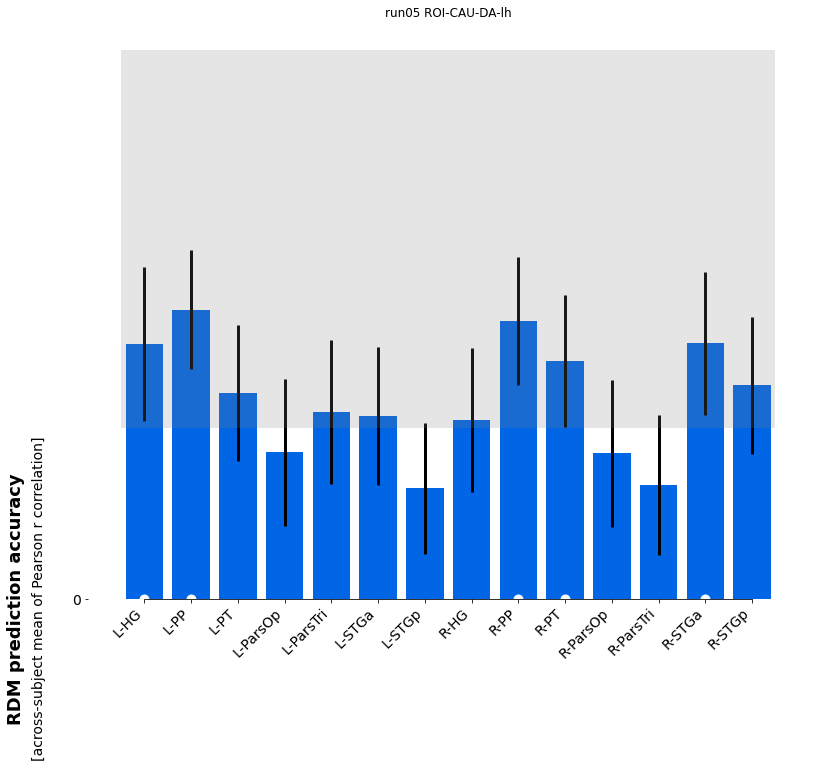

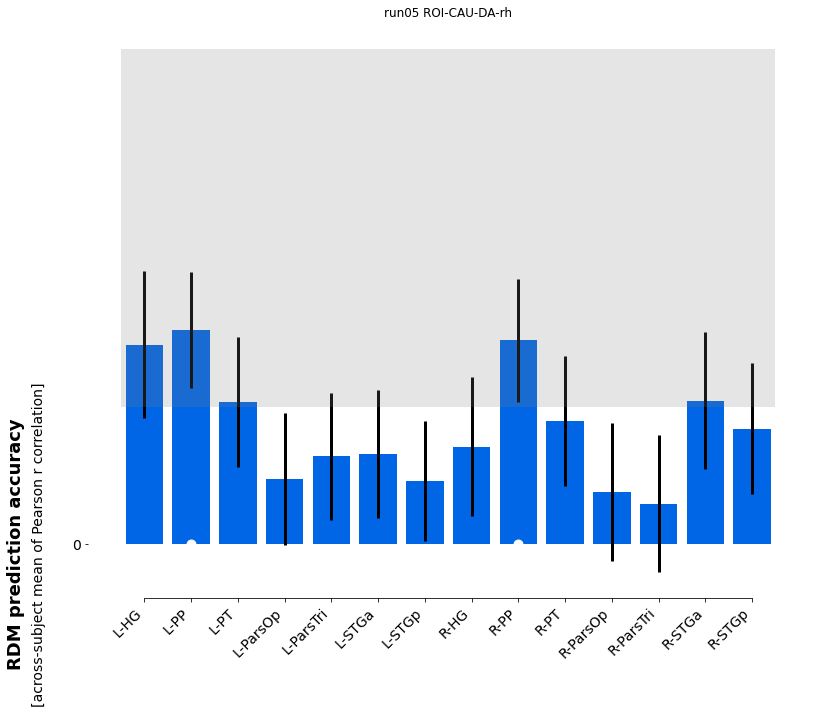

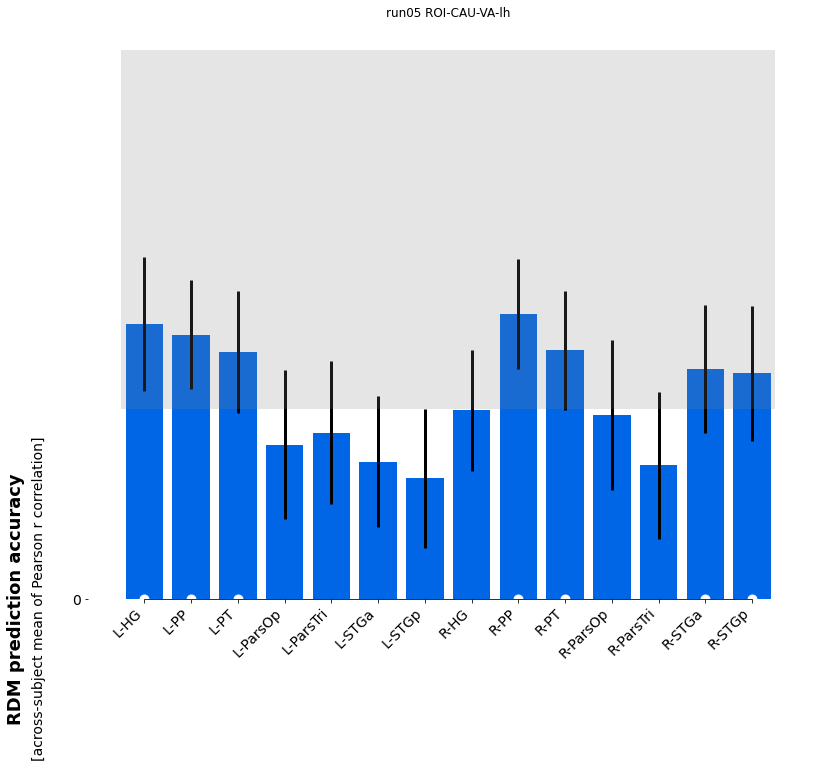

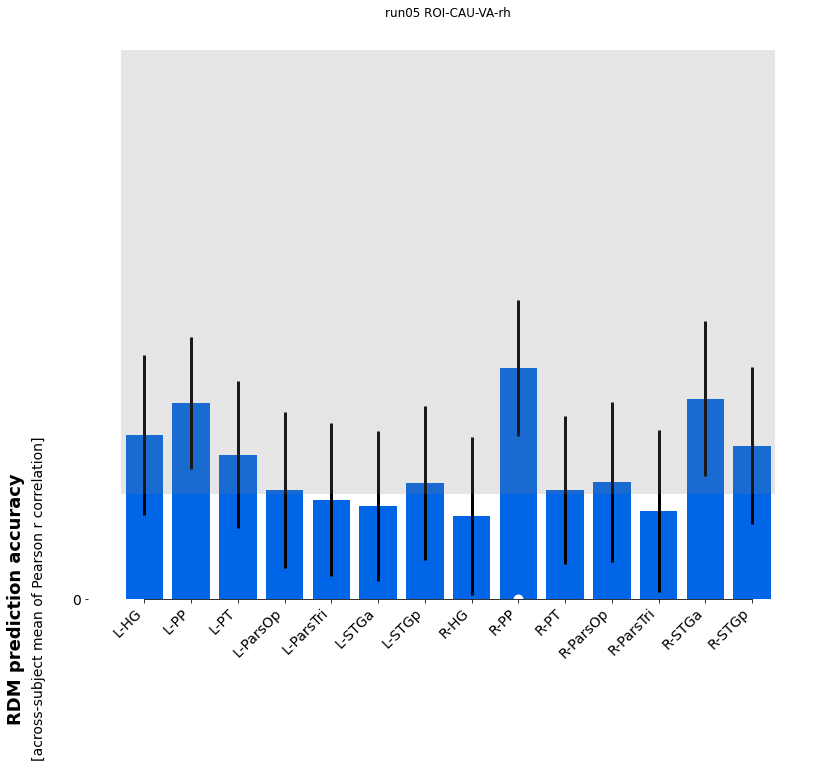

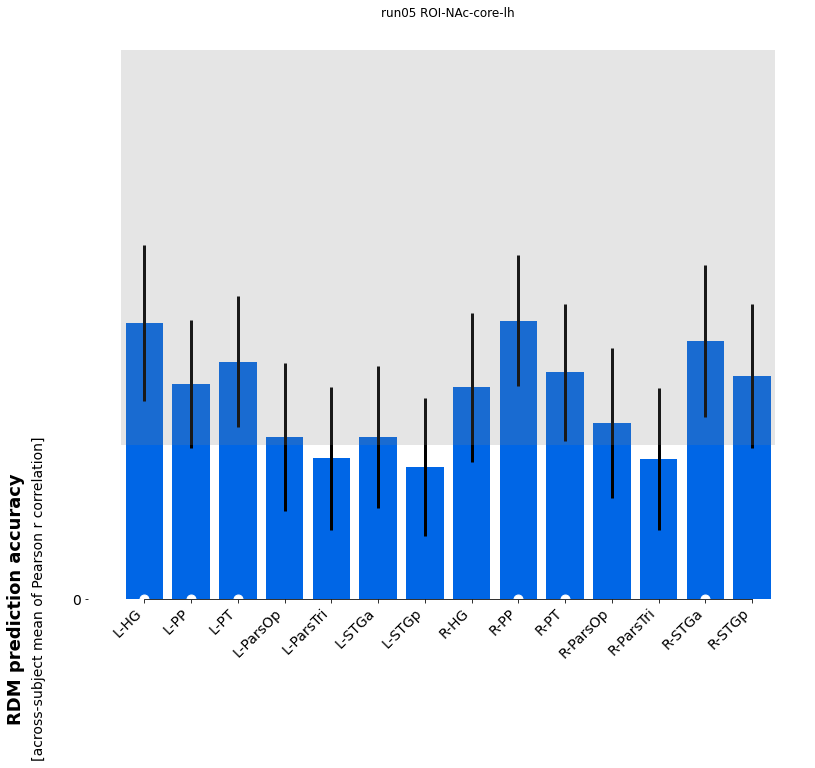

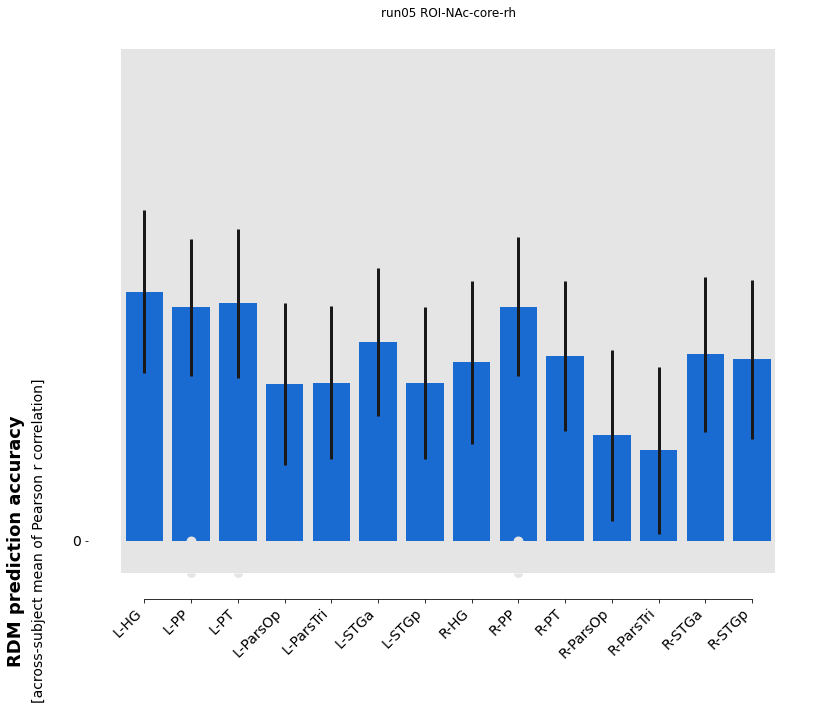

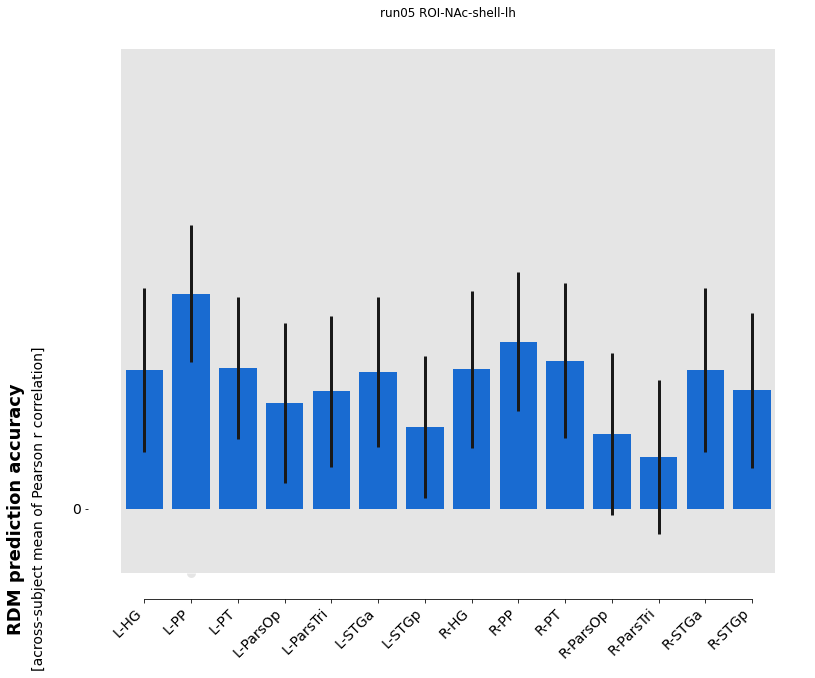

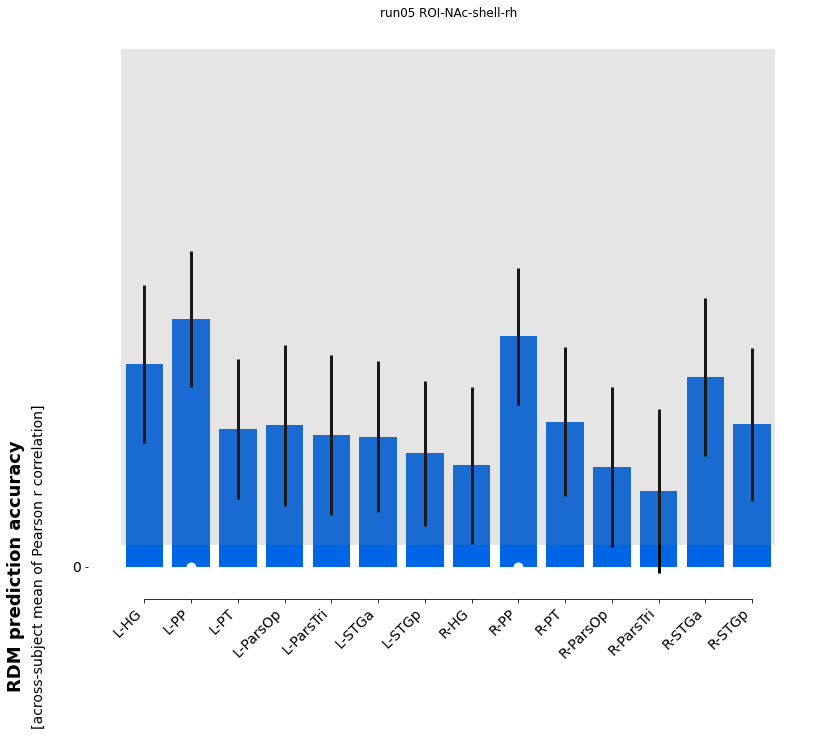

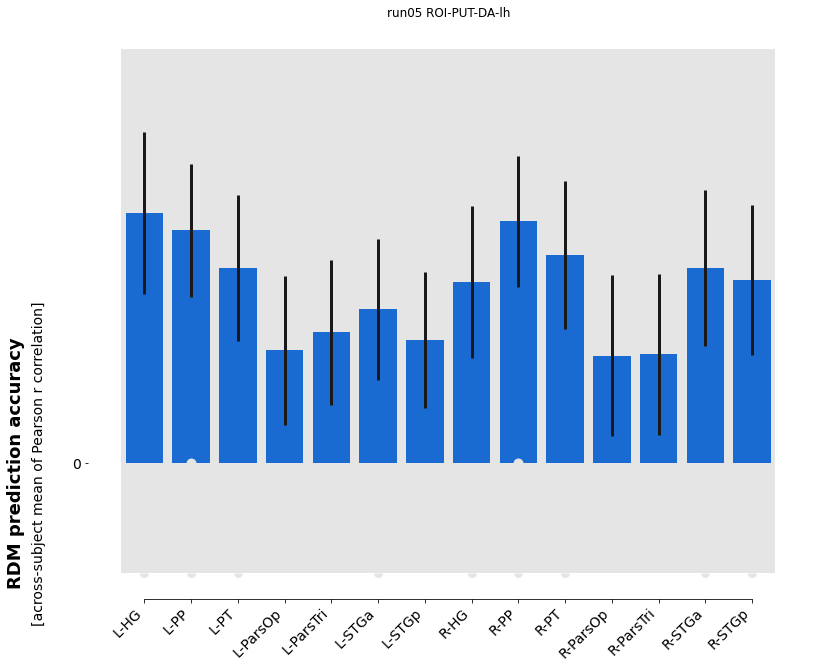

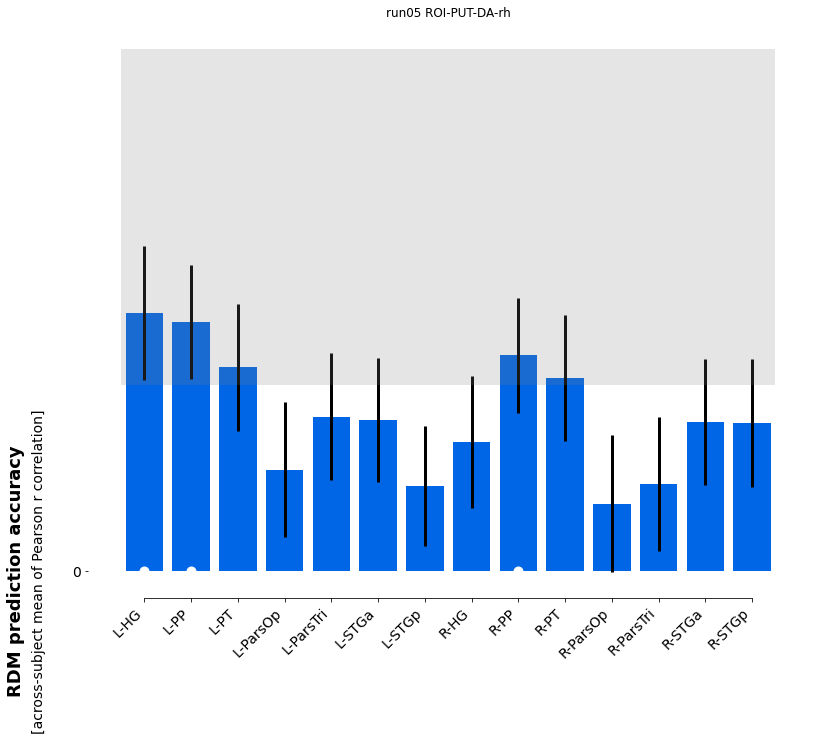

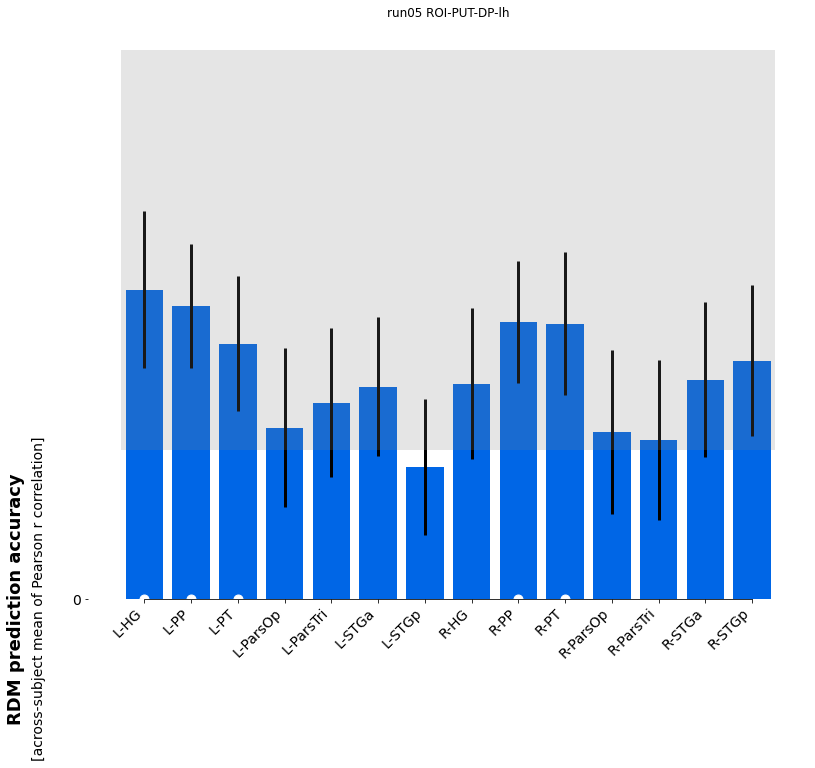

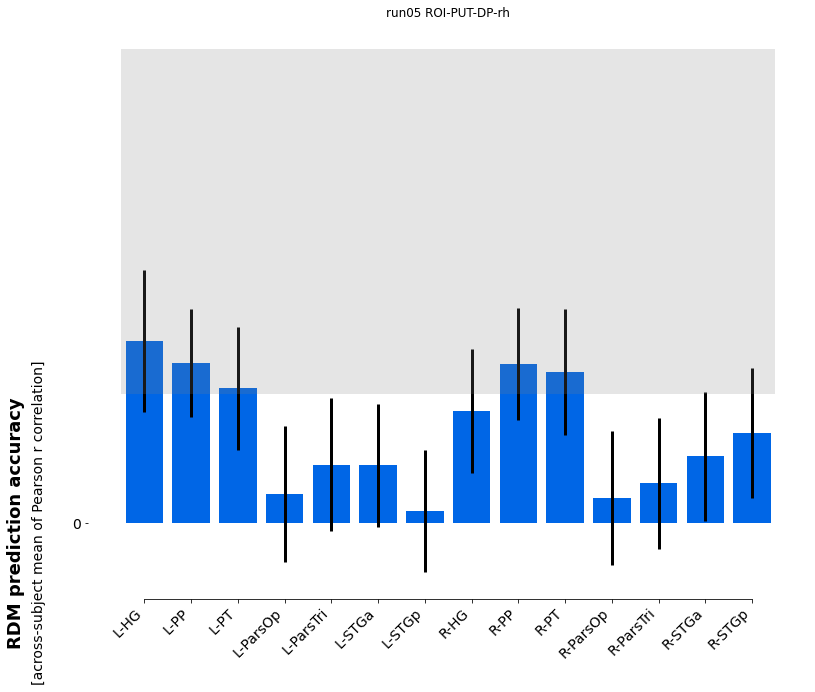

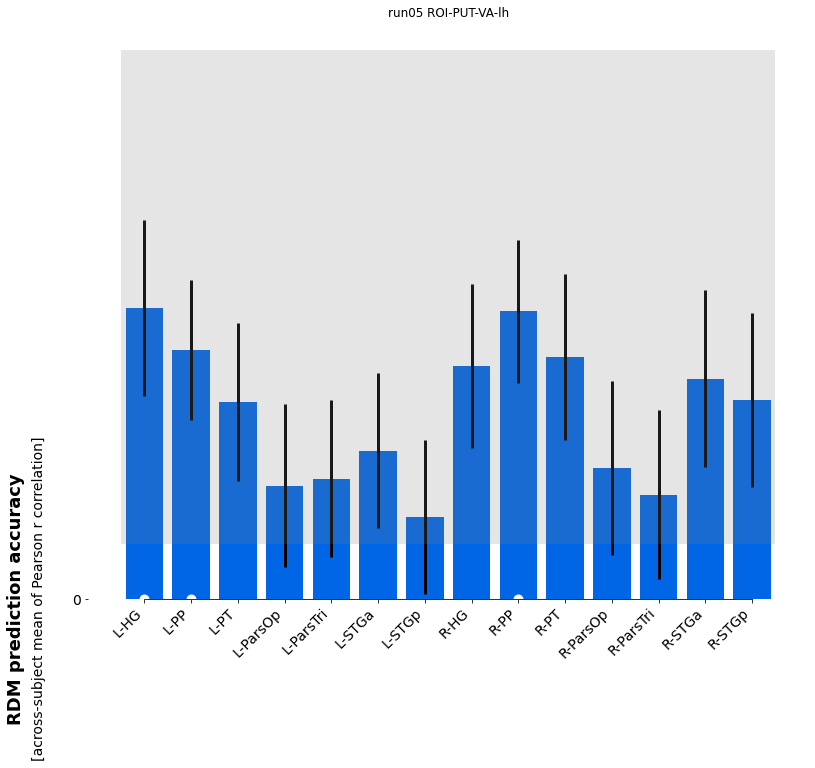

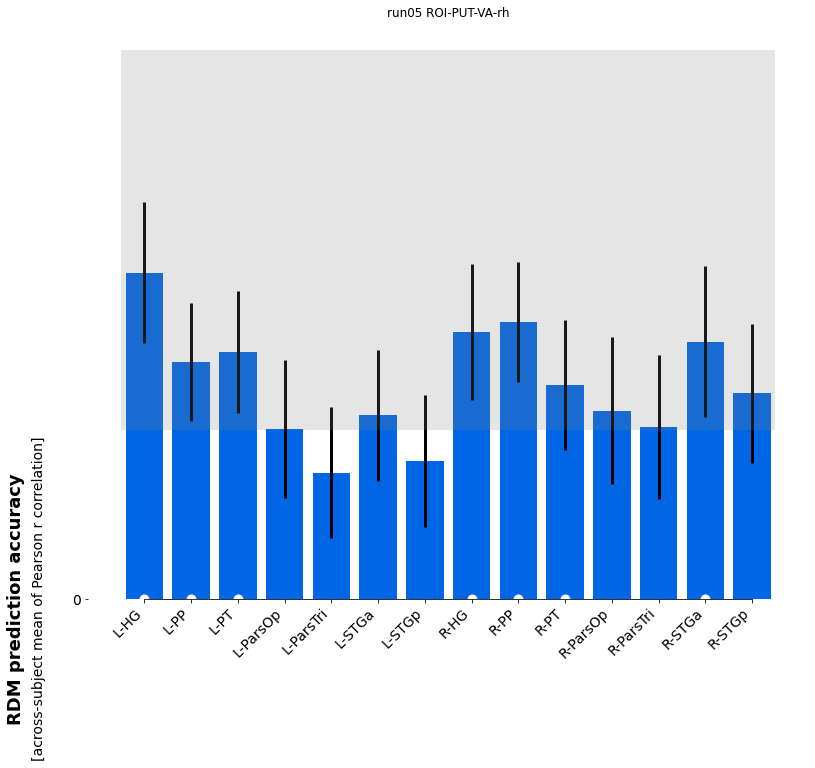

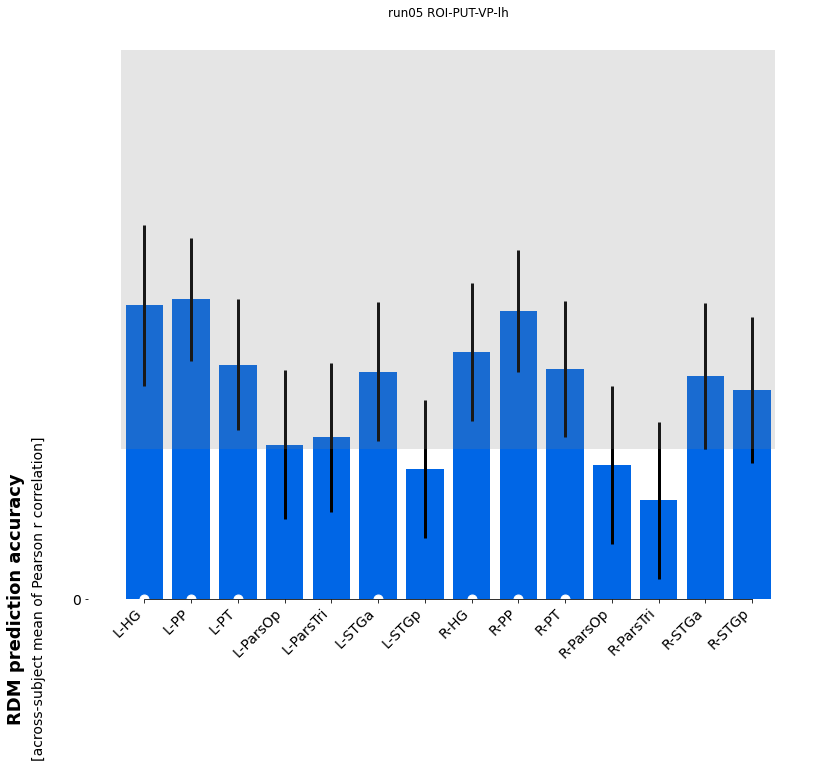

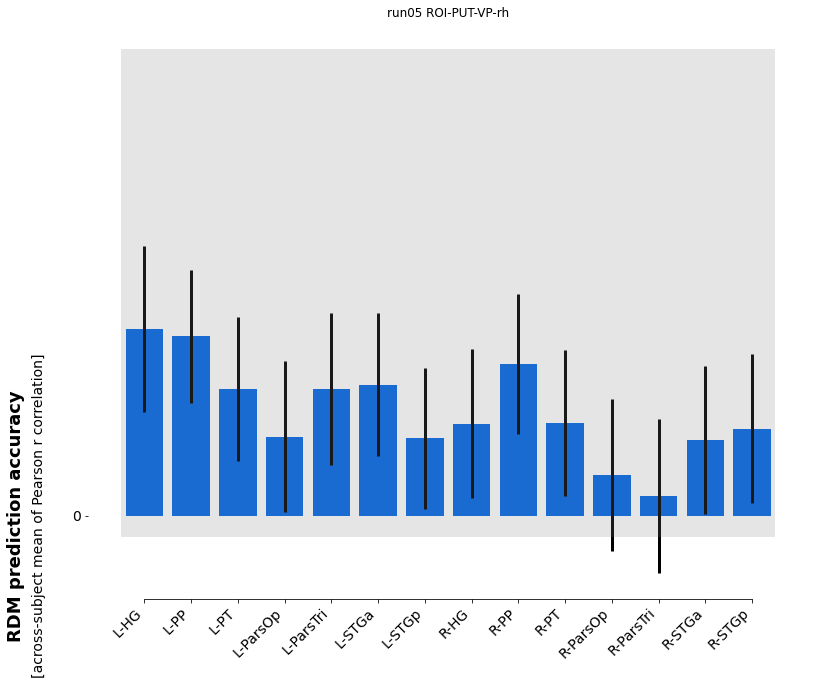

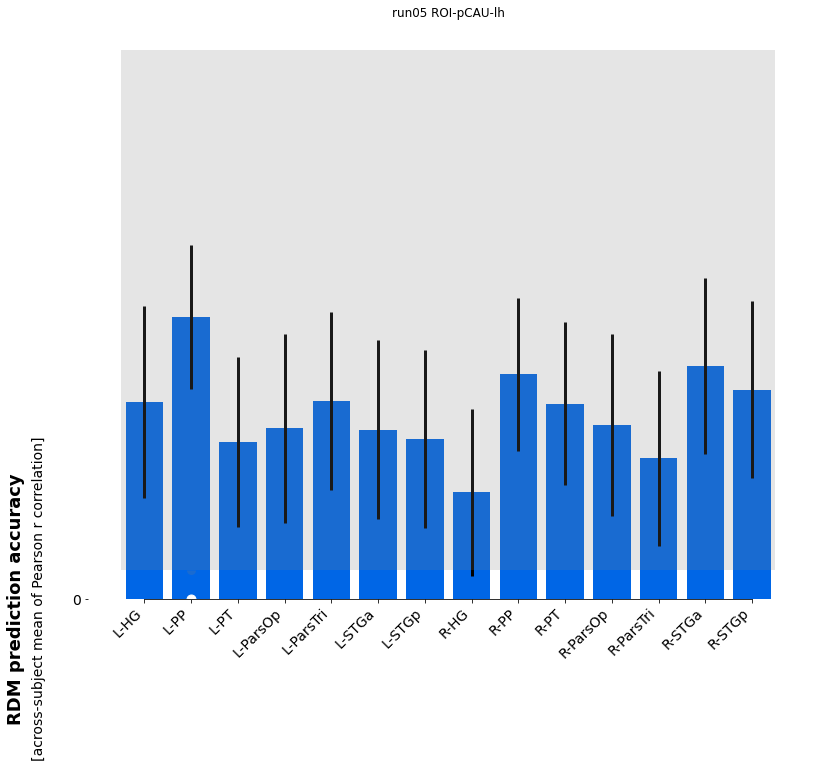

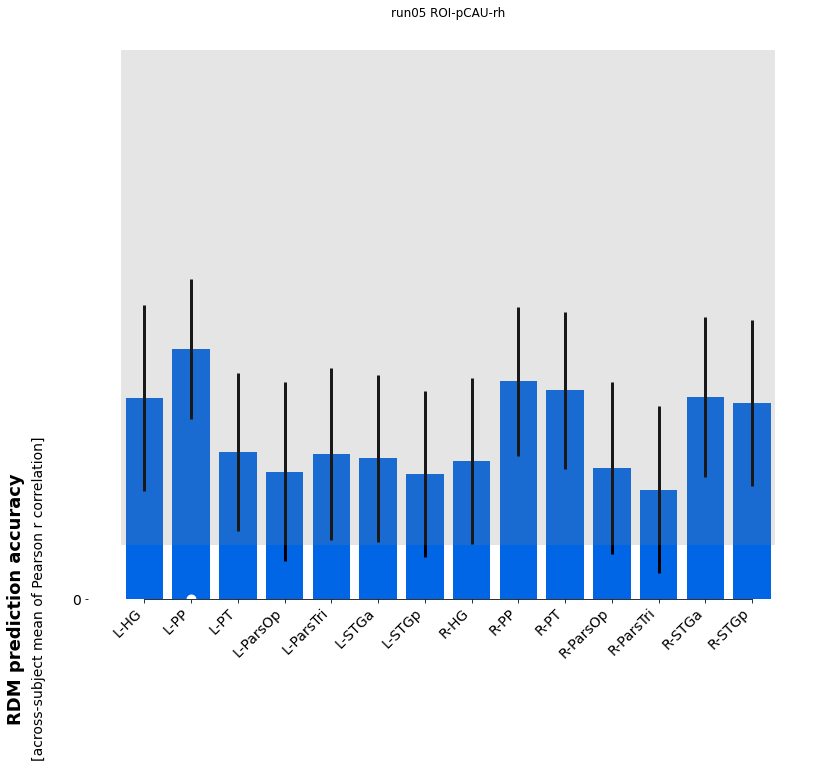

In [75]:
for runx, run in enumerate(run_list): 

    for ROI in np.unique(striatal_rdms.rdm_descriptors['ROI']):
        if 'GP' in ROI:
            continue
        print(f'{run} ROI-{ROI}')
        results_grr = rsatoolbox.inference.eval_fixed(auditory_models_dict[run], 
                                                      striatal_rdms.subset('ROI',value=ROI),  
                                                      method='corr',)
        fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr,
                                                             test_pair_comparisons='nili', #'nili', #False, # getting a bug from plot_arrow()
                                                            );
        ax1.set_title(f'{run} ROI-{ROI}');
        ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")

# statistics

In [57]:
from scipy import stats

#### By group, all runs

In [58]:
# Combining hemispheres
print('all runs')
#for group_id in np.unique(group_rdms.rdm_descriptors['group']):
group_id = 'non-Mandarin'

group_long_df = laterality_df.where(laterality_df.participant_group==group_id).dropna()

for model_id in ['Tone']: #model_names:
    print(f'\n{model_id}')
    model_df = group_long_df.where(group_long_df.model==model_id).dropna()

    roi_list = []
    p_vals = []
    t_stats = []

    for roi in np.unique(model_df.ROI): # roi_list_ordered: # np.unique(group_rdms.rdm_descriptors['ROI']):
        #print(roi)
        groi_data = model_df.where(model_df.ROI==roi).dropna()['corr']
        res = stats.ttest_1samp(groi_data, popmean=0)

        p_vals.append(res.pvalue)
        t_stats.append(res.statistic)
        roi_list.append(roi)
        #print(res.pvalue)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')


all runs

Tone
**t = 3.46 FDR-corr p = 0.0010 uncorr p = 0.0010 region = HG
**t = 5.03 FDR-corr p = 0.0000 uncorr p = 0.0000 region = PP
**t = 6.19 FDR-corr p = 0.0000 uncorr p = 0.0000 region = PT
**t = 6.04 FDR-corr p = 0.0000 uncorr p = 0.0000 region = ParsOp
**t = 5.53 FDR-corr p = 0.0000 uncorr p = 0.0000 region = ParsTri
**t = 5.31 FDR-corr p = 0.0000 uncorr p = 0.0000 region = STGa
**t = 7.57 FDR-corr p = 0.0000 uncorr p = 0.0000 region = STGp


In [59]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = roi_list

res_df

,Region of interest,t-statistic,p-value
0,HG,3.465,0.001
1,PP,5.032,0.000
2,PT,6.186,0.000
3,ParsOp,6.038,0.000
4,ParsTri,5.526,0.000
5,STGa,5.308,0.000
6,STGp,7.571,0.000


In [60]:
# Combining subdivisions
print('all runs')
group_id = 'non-Mandarin'

group_long_df = laterality_df.where(laterality_df.participant_group==group_id).dropna()

for model_id in model_names:
    print(f'\n{model_id}')
    model_df = group_long_df.where(group_long_df.model==model_id).dropna()

    roi_list = []
    p_vals = []
    t_stats = []

    groi_data = model_df.dropna()['corr']
    res = stats.ttest_1samp(groi_data, popmean=0)

    p_vals.append(res.pvalue)
    t_stats.append(res.statistic)
    roi_list.append(roi)
    #print(res.pvalue)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.20f}',
              f'uncorr p = {p_vals[rx]:.06f}, all cortical regions')


all runs

Tone
**t = 14.64 FDR-corr p = 0.00000000000000000000 uncorr p = 0.000000, all cortical regions

Talker
  t = 0.42 FDR-corr p = 0.67789706995132725798 uncorr p = 0.677897, all cortical regions


In [61]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['t-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)

res_df

,t-statistic,p-value
0,0.416,0.678


In [62]:
print('all runs')
#for group_id in np.unique(group_rdms.rdm_descriptors['group']):

group_long_df = model_long_df.where(model_long_df.participant_group==group_id)

for model_id in model_names:
    print(f'\n{model_id}')
    model_df = group_long_df.where(group_long_df.model==model_id)

    roi_list = []
    p_vals = []
    t_stats = []

    for roi in roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
        if 'GP' not in roi:
            groi_data = model_df.where(model_df.ROI==roi).dropna()['corr']
            res = stats.ttest_1samp(groi_data, popmean=0)

            p_vals.append(res.pvalue)
            t_stats.append(res.statistic)
            roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')


all runs

Tone
**t = 2.75 FDR-corr p = 0.0109 uncorr p = 0.0101 region = L-HG
**t = 4.05 FDR-corr p = 0.0007 uncorr p = 0.0003 region = L-PT
**t = 3.53 FDR-corr p = 0.0019 uncorr p = 0.0014 region = L-PP
**t = 5.39 FDR-corr p = 0.0001 uncorr p = 0.0000 region = L-STGp
**t = 3.35 FDR-corr p = 0.0026 uncorr p = 0.0023 region = L-STGa
**t = 4.58 FDR-corr p = 0.0003 uncorr p = 0.0001 region = L-ParsOp
**t = 4.40 FDR-corr p = 0.0004 uncorr p = 0.0001 region = L-ParsTri
**t = 2.13 FDR-corr p = 0.0419 uncorr p = 0.0419 region = R-HG
**t = 4.66 FDR-corr p = 0.0003 uncorr p = 0.0001 region = R-PT
**t = 3.60 FDR-corr p = 0.0018 uncorr p = 0.0012 region = R-PP
**t = 5.25 FDR-corr p = 0.0001 uncorr p = 0.0000 region = R-STGp
**t = 4.19 FDR-corr p = 0.0006 uncorr p = 0.0002 region = R-STGa
**t = 3.98 FDR-corr p = 0.0007 uncorr p = 0.0004 region = R-ParsOp
**t = 3.40 FDR-corr p = 0.0025 uncorr p = 0.0020 region = R-ParsTri

Talker
  t = -0.04 FDR-corr p = 0.9652 uncorr p = 0.9652 region = L-HG
  t =

In [63]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = roi_list

res_df

,Region of interest,t-statistic,p-value
0,L-HG,-0.044,0.965
1,L-PT,0.700,0.965
2,L-PP,-0.179,0.965
3,L-STGp,-0.092,0.965
4,L-STGa,-0.799,0.965
5,L-ParsOp,0.434,0.965
6,L-ParsTri,0.186,0.965
7,R-HG,0.189,0.965
8,R-PT,0.579,0.965
9,R-PP,-0.046,0.965


#### By group, separate stages

In [64]:
group_id = 'non-Mandarin'
group_long_df = model_long_df.where(model_long_df.participant_group==group_id)

for model_id in model_names:
    print(f'\n{model_id}')
    for runcombo in ['early','middle', 'final']:
        rc_df = group_long_df.where(group_long_df.stage==runcombo).where(group_long_df.model==model_id)
        print(f'\n{runcombo} runs')

        roi_list = []
        p_vals = []
        t_stats = []

        for roi in roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
            if 'GP' not in roi:
                groi_data = rc_df.where(rc_df.ROI==roi).dropna()['corr']
                res = stats.ttest_1samp(groi_data, popmean=0)

                p_vals.append(res.pvalue)
                t_stats.append(res.statistic)
                roi_list.append(roi)
        p_vals_adj = stats.false_discovery_control(p_vals)

        for rx, roi in enumerate(roi_list):
            if p_vals_adj[rx] < 0.05:
                ast = '**'
            elif p_vals[rx] < 0.05:
                ast = ' *'
            else:
                ast = '  '
            print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')



Tone

early runs
  t = 0.92 FDR-corr p = 0.4130 uncorr p = 0.3835 region = L-HG
  t = 1.13 FDR-corr p = 0.3367 uncorr p = 0.2858 region = L-PT
  t = 1.45 FDR-corr p = 0.3027 uncorr p = 0.1820 region = L-PP
  t = 2.19 FDR-corr p = 0.3027 uncorr p = 0.0563 region = L-STGp
  t = 1.40 FDR-corr p = 0.3027 uncorr p = 0.1946 region = L-STGa
  t = 1.44 FDR-corr p = 0.3027 uncorr p = 0.1846 region = L-ParsOp
  t = 1.95 FDR-corr p = 0.3027 uncorr p = 0.0828 region = L-ParsTri
  t = -0.62 FDR-corr p = 0.5479 uncorr p = 0.5479 region = R-HG
  t = 1.55 FDR-corr p = 0.3027 uncorr p = 0.1561 region = R-PT
  t = 1.13 FDR-corr p = 0.3367 uncorr p = 0.2886 region = R-PP
  t = 1.79 FDR-corr p = 0.3027 uncorr p = 0.1072 region = R-STGp
  t = 1.91 FDR-corr p = 0.3027 uncorr p = 0.0888 region = R-STGa
  t = 1.69 FDR-corr p = 0.3027 uncorr p = 0.1246 region = R-ParsOp
  t = 1.22 FDR-corr p = 0.3367 uncorr p = 0.2519 region = R-ParsTri

middle runs
  t = 2.22 FDR-corr p = 0.0828 uncorr p = 0.0533 region = L-

In [65]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = np.unique(roi_df_long.region)

res_df

NameError: name 'roi_df_long' is not defined

In [80]:
group_id = 'non-Mandarin'
group_long_df = laterality_df.where(laterality_df.participant_group==group_id)

for model_id in model_names:
    print(f'\n{model_id}')
    for runcombo in ['early','middle','final']:
        rc_df = group_long_df.where(group_long_df.stage==runcombo).where(group_long_df.model==model_id).dropna()
        print(f'\n{runcombo} runs')

        roi_list = []
        p_vals = []
        t_stats = []

        for roi in np.unique(rc_df.ROI): # roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
            groi_data = rc_df.where(rc_df.ROI==roi).dropna()['corr']
            res = stats.ttest_1samp(groi_data, popmean=0)

            p_vals.append(res.pvalue)
            t_stats.append(res.statistic)
            roi_list.append(roi)
        p_vals_adj = stats.false_discovery_control(p_vals)

        for rx, roi in enumerate(roi_list):
            if p_vals_adj[rx] < 0.05:
                ast = '**'
            elif p_vals[rx] < 0.05:
                ast = ' *'
            else:
                ast = '  '
            print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')



Tone

early runs
  t = 0.23 FDR-corr p = 0.8218 uncorr p = 0.8218 region = HG
  t = 1.78 FDR-corr p = 0.1054 uncorr p = 0.0903 region = PP
  t = 1.92 FDR-corr p = 0.0988 uncorr p = 0.0705 region = PT
 *t = 2.26 FDR-corr p = 0.0630 uncorr p = 0.0360 region = ParsOp
 *t = 2.31 FDR-corr p = 0.0630 uncorr p = 0.0325 region = ParsTri
 *t = 2.29 FDR-corr p = 0.0630 uncorr p = 0.0333 region = STGa
 *t = 2.88 FDR-corr p = 0.0630 uncorr p = 0.0095 region = STGp

middle runs
**t = 2.77 FDR-corr p = 0.0123 uncorr p = 0.0123 region = HG
**t = 4.21 FDR-corr p = 0.0011 uncorr p = 0.0005 region = PP
**t = 4.72 FDR-corr p = 0.0005 uncorr p = 0.0002 region = PT
**t = 4.09 FDR-corr p = 0.0011 uncorr p = 0.0006 region = ParsOp
**t = 3.37 FDR-corr p = 0.0038 uncorr p = 0.0033 region = ParsTri
**t = 3.50 FDR-corr p = 0.0034 uncorr p = 0.0024 region = STGa
**t = 5.97 FDR-corr p = 0.0001 uncorr p = 0.0000 region = STGp

final runs
**t = 2.94 FDR-corr p = 0.0085 uncorr p = 0.0085 region = HG
**t = 3.11 FDR-c

In [77]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = np.unique(rc_df.ROI)

res_df

,Region of interest,t-statistic,p-value
0,HG,0.771,0.928
1,PP,0.734,0.928
2,PT,1.421,0.928
3,ParsOp,-0.343,0.928
4,ParsTri,0.001,0.999
5,STGa,0.263,0.928
6,STGp,-0.395,0.928


#### By group, early vs. late stages

In [68]:
# Combining subdivisions, early vs. late runs
group_id = 'non-Mandarin'
print(f'\nearly vs. late runs')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id)

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='early').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model==model_id).dropna()


    early_data = early_df['corr']
    final_data = final_df['corr']

    res = stats.ttest_rel(final_data, early_data)

    p_vals.append(res.pvalue)
    t_stats.append(res.statistic)
    roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f}, all cortical regions')



early vs. late runs

Tone
**t = 3.84 FDR-corr p = 0.0002 uncorr p = 0.0002, all cortical regions

Talker
  t = 0.39 FDR-corr p = 0.7005 uncorr p = 0.7005, all cortical regions


In [69]:
# Combining subdivisions, early vs. middle runs
group_id = 'non-Mandarin'
print(f'\nearly vs. middle runs')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id)

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='early').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='middle').where(group_long_df.model==model_id).dropna()


    early_data = early_df['corr']
    final_data = final_df['corr']

    res = stats.ttest_rel(final_data, early_data)

    p_vals.append(res.pvalue)
    t_stats.append(res.statistic)
    roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f}, all cortical regions')



early vs. middle runs

Tone
**t = 4.37 FDR-corr p = 0.0000 uncorr p = 0.0000, all cortical regions

Talker
  t = -1.17 FDR-corr p = 0.2441 uncorr p = 0.2441, all cortical regions


In [70]:
# Combining subdivisions, early vs. middle runs
group_id = 'non-Mandarin'
print(f'\nmiddle vs. final runs')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id)

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='middle').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model==model_id).dropna()


    early_data = early_df['corr']
    final_data = final_df['corr']

    res = stats.ttest_rel(final_data, early_data)

    p_vals.append(res.pvalue)
    t_stats.append(res.statistic)
    roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f}, all cortical regions')



middle vs. final runs

Tone
  t = 0.27 FDR-corr p = 0.7872 uncorr p = 0.7872, all cortical regions

Talker
  t = 1.24 FDR-corr p = 0.2166 uncorr p = 0.2166, all cortical regions


In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = np.unique(roi_df_long.region)

res_df

In [60]:
# early vs. late runs
print(f'\nearly vs. late runs')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id).dropna()

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='early').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model==model_id).dropna()


    for roi in np.unique(group_long_df.ROI):
        early_data = early_df.where(early_df.ROI==roi).dropna()['corr']
        final_data = final_df.where(final_df.ROI==roi).dropna()['corr']

        res = stats.ttest_rel(final_data, early_data)

        p_vals.append(res.pvalue)
        t_stats.append(res.statistic)
        roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(np.unique(group_long_df.ROI)):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')



early vs. late runs

Tone
  t = 1.67 FDR-corr p = 0.2617 uncorr p = 0.1122 region = HG
  t = 1.05 FDR-corr p = 0.3562 uncorr p = 0.3053 region = PP
  t = 1.89 FDR-corr p = 0.2583 uncorr p = 0.0738 region = PT
 *t = 2.37 FDR-corr p = 0.1997 uncorr p = 0.0285 region = ParsOp
  t = 1.17 FDR-corr p = 0.3562 uncorr p = 0.2577 region = ParsTri
  t = 0.90 FDR-corr p = 0.3817 uncorr p = 0.3817 region = STGa
  t = 1.15 FDR-corr p = 0.3562 uncorr p = 0.2642 region = STGp

Talker
  t = 0.38 FDR-corr p = 0.8584 uncorr p = 0.7050 region = HG
  t = 0.67 FDR-corr p = 0.8584 uncorr p = 0.5124 region = PP
  t = 0.70 FDR-corr p = 0.8584 uncorr p = 0.4903 region = PT
  t = -0.72 FDR-corr p = 0.8584 uncorr p = 0.4823 region = ParsOp
  t = 0.34 FDR-corr p = 0.8584 uncorr p = 0.7358 region = ParsTri
  t = -0.13 FDR-corr p = 0.8985 uncorr p = 0.8985 region = STGa
  t = -0.88 FDR-corr p = 0.8584 uncorr p = 0.3901 region = STGp


In [88]:
# early vs. middle runs
print(f'\nearly vs. middle runs')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id).dropna()

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='early').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='middle').where(group_long_df.model==model_id).dropna()


    for roi in np.unique(group_long_df.ROI):
        early_data = early_df.where(early_df.ROI==roi).dropna()['corr']
        final_data = final_df.where(final_df.ROI==roi).dropna()['corr']

        res = stats.ttest_rel(final_data, early_data)

        p_vals.append(res.pvalue)
        t_stats.append(res.statistic)
        roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(np.unique(group_long_df.ROI)):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')



early vs. middle runs

Tone
 *t = 2.24 FDR-corr p = 0.0874 uncorr p = 0.0375 region = HG
  t = 1.18 FDR-corr p = 0.2934 uncorr p = 0.2515 region = PP
 *t = 2.24 FDR-corr p = 0.0874 uncorr p = 0.0375 region = PT
  t = 1.41 FDR-corr p = 0.2438 uncorr p = 0.1742 region = ParsOp
  t = 0.43 FDR-corr p = 0.6717 uncorr p = 0.6717 region = ParsTri
  t = 1.58 FDR-corr p = 0.2304 uncorr p = 0.1317 region = STGa
 *t = 2.99 FDR-corr p = 0.0522 uncorr p = 0.0075 region = STGp

Talker
  t = -1.03 FDR-corr p = 0.6613 uncorr p = 0.3156 region = HG
  t = -0.58 FDR-corr p = 0.6613 uncorr p = 0.5668 region = PP
  t = -0.62 FDR-corr p = 0.6613 uncorr p = 0.5442 region = PT
  t = 0.39 FDR-corr p = 0.6990 uncorr p = 0.6990 region = ParsOp
  t = 0.77 FDR-corr p = 0.6613 uncorr p = 0.4505 region = ParsTri
  t = -1.09 FDR-corr p = 0.6613 uncorr p = 0.2900 region = STGa
  t = -0.81 FDR-corr p = 0.6613 uncorr p = 0.4303 region = STGp


In [89]:
# middle vs. late runs
print(f'\nmiddle vs. late runs')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id).dropna()

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='middle').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model==model_id).dropna()


    for roi in np.unique(group_long_df.ROI):
        early_data = early_df.where(early_df.ROI==roi).dropna()['corr']
        final_data = final_df.where(final_df.ROI==roi).dropna()['corr']

        res = stats.ttest_rel(final_data, early_data)

        p_vals.append(res.pvalue)
        t_stats.append(res.statistic)
        roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(np.unique(group_long_df.ROI)):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')



middle vs. late runs

Tone
  t = -0.34 FDR-corr p = 0.9165 uncorr p = 0.7403 region = HG
  t = 0.25 FDR-corr p = 0.9165 uncorr p = 0.8071 region = PP
  t = 0.11 FDR-corr p = 0.9165 uncorr p = 0.9165 region = PT
  t = 1.12 FDR-corr p = 0.9165 uncorr p = 0.2771 region = ParsOp
  t = 0.89 FDR-corr p = 0.9165 uncorr p = 0.3850 region = ParsTri
  t = -0.51 FDR-corr p = 0.9165 uncorr p = 0.6138 region = STGa
  t = -0.80 FDR-corr p = 0.9165 uncorr p = 0.4312 region = STGp

Talker
  t = 0.98 FDR-corr p = 0.5899 uncorr p = 0.3391 region = HG
  t = 0.97 FDR-corr p = 0.5899 uncorr p = 0.3458 region = PP
  t = 0.92 FDR-corr p = 0.5899 uncorr p = 0.3702 region = PT
  t = -0.82 FDR-corr p = 0.5899 uncorr p = 0.4213 region = ParsOp
  t = -0.53 FDR-corr p = 0.7060 uncorr p = 0.6052 region = ParsTri
  t = 0.84 FDR-corr p = 0.5899 uncorr p = 0.4088 region = STGa
  t = 0.29 FDR-corr p = 0.7726 uncorr p = 0.7726 region = STGp


In [85]:
# early vs. late runs
print(f'\nearly vs. late runs')

group_long_df = intermed_df.where(laterality_df.participant_group==group_id).dropna()

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='early').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model==model_id).dropna()


    for roi in np.unique(group_long_df.intermediate):
        early_data = early_df.where(early_df.intermediate==roi).dropna()['corr']
        final_data = final_df.where(final_df.intermediate==roi).dropna()['corr']

        res = stats.ttest_rel(final_data, early_data)

        p_vals.append(res.pvalue)
        t_stats.append(res.statistic)
        roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')



early vs. late runs

Tone
**t = 2.66 FDR-corr p = 0.0255 uncorr p = 0.0100 region = ACtx
**t = 2.49 FDR-corr p = 0.0255 uncorr p = 0.0170 region = IFG
  t = 1.46 FDR-corr p = 0.1524 uncorr p = 0.1524 region = STG

Talker
  t = 1.04 FDR-corr p = 0.7729 uncorr p = 0.3026 region = ACtx
  t = -0.23 FDR-corr p = 0.8192 uncorr p = 0.8192 region = IFG
  t = -0.66 FDR-corr p = 0.7729 uncorr p = 0.5153 region = STG


In [86]:
# early vs. middle runs
print(f'\nearly vs. middle runs')

group_long_df = intermed_df.where(laterality_df.participant_group==group_id).dropna()

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='early').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='middle').where(group_long_df.model==model_id).dropna()


    for roi in np.unique(group_long_df.intermediate):
        early_data = early_df.where(early_df.intermediate==roi).dropna()['corr']
        final_data = final_df.where(final_df.intermediate==roi).dropna()['corr']

        res = stats.ttest_rel(final_data, early_data)

        p_vals.append(res.pvalue)
        t_stats.append(res.statistic)
        roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')



early vs. middle runs

Tone
**t = 3.31 FDR-corr p = 0.0048 uncorr p = 0.0016 region = ACtx
  t = 1.24 FDR-corr p = 0.2225 uncorr p = 0.2225 region = IFG
**t = 3.00 FDR-corr p = 0.0071 uncorr p = 0.0047 region = STG

Talker
  t = -1.27 FDR-corr p = 0.3161 uncorr p = 0.2108 region = ACtx
  t = 0.81 FDR-corr p = 0.4224 uncorr p = 0.4224 region = IFG
  t = -1.34 FDR-corr p = 0.3161 uncorr p = 0.1866 region = STG


In [87]:
# middle vs. late runs
print(f'\nmiddle vs. late runs')

group_long_df = intermed_df.where(laterality_df.participant_group==group_id).dropna()

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='middle').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model==model_id).dropna()


    for roi in np.unique(group_long_df.intermediate):
        early_data = early_df.where(early_df.intermediate==roi).dropna()['corr']
        final_data = final_df.where(final_df.intermediate==roi).dropna()['corr']

        res = stats.ttest_rel(final_data, early_data)

        p_vals.append(res.pvalue)
        t_stats.append(res.statistic)
        roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')



middle vs. late runs

Tone
  t = -0.01 FDR-corr p = 0.9893 uncorr p = 0.9893 region = ACtx
  t = 1.45 FDR-corr p = 0.4685 uncorr p = 0.1562 region = IFG
  t = -0.92 FDR-corr p = 0.5439 uncorr p = 0.3626 region = STG

Talker
  t = 1.68 FDR-corr p = 0.2959 uncorr p = 0.0986 region = ACtx
  t = -0.97 FDR-corr p = 0.4256 uncorr p = 0.3359 region = IFG
  t = 0.81 FDR-corr p = 0.4256 uncorr p = 0.4256 region = STG


In [61]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
print(model_id)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = roi_list

res_df

Talker


,Region of interest,t-statistic,p-value
0,HG,0.384,0.858
1,PP,0.668,0.858
2,PT,0.703,0.858
3,ParsOp,-0.717,0.858
4,ParsTri,0.342,0.858
5,STGa,-0.129,0.898
6,STGp,-0.880,0.858


In [ ]:
# early vs. late runs
print(f'\nearly vs. late runs')

group_long_df = model_long_df.where(model_long_df.participant_group==group_id)

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='early').where(group_long_df.model==model_id)
    final_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model==model_id)


    for roi in roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
        early_data = early_df.where(early_df.ROI==roi).dropna()['corr']
        final_data = final_df.where(final_df.ROI==roi).dropna()['corr']

        res = stats.ttest_rel(final_data, early_data)

        p_vals.append(res.pvalue)
        t_stats.append(res.statistic)
        roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')


In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = np.unique(roi_df_long.region)

res_df

#### Tone vs. Talker - all runs

In [62]:
# Combining subdivisions, Tone vs. Talker models
print(f'\nTone vs. Talker models – all runs')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id).dropna()

#for model_id in model_names:
#    print(f'\n{model_id}')
roi_list = []
p_vals = []
t_stats = []

tone_df = group_long_df.where(group_long_df.model=='Tone').dropna()
talker_df = group_long_df.where(group_long_df.model=='Talker').dropna()


for roi in np.unique(group_long_df.ROI): # roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
    tone_data = tone_df.where(tone_df.ROI==roi).dropna()['corr'].dropna()
    talker_data = talker_df.where(talker_df.ROI==roi).dropna()['corr'].dropna()

    res = stats.ttest_rel(tone_data, talker_data)

    p_vals.append(res.pvalue)
    t_stats.append(res.statistic)
    roi_list.append(roi)
p_vals_adj = stats.false_discovery_control(p_vals)

for rx, roi in enumerate(roi_list):
    if p_vals_adj[rx] < 0.05:
        ast = '**'
    elif p_vals[rx] < 0.05:
        ast = ' *'
    else:
        ast = '  '
    print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')



Tone vs. Talker models – all runs
  t = 0.57 FDR-corr p = 0.5698 uncorr p = 0.5698 region = HG
  t = 1.57 FDR-corr p = 0.1757 uncorr p = 0.1255 region = PP
  t = 1.39 FDR-corr p = 0.2002 uncorr p = 0.1716 region = PT
**t = 3.34 FDR-corr p = 0.0065 uncorr p = 0.0019 region = ParsOp
**t = 3.11 FDR-corr p = 0.0081 uncorr p = 0.0035 region = ParsTri
 *t = 2.07 FDR-corr p = 0.0794 uncorr p = 0.0453 region = STGa
**t = 3.35 FDR-corr p = 0.0065 uncorr p = 0.0018 region = STGp


In [64]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = roi_list

res_df

,Region of interest,t-statistic,p-value
0,HG,0.573,0.570
1,PP,1.566,0.176
2,PT,1.393,0.200
3,ParsOp,3.340,0.006
4,ParsTri,3.113,0.008
5,STGa,2.068,0.079
6,STGp,3.352,0.006


In [ ]:
# Tone vs. Talker models
print(f'\nTone vs. Talker models – all runs')

group_long_df = model_long_df.where(model_long_df.participant_group==group_id)

#for model_id in model_names:
#    print(f'\n{model_id}')
roi_list = []
p_vals = []
t_stats = []

tone_df = group_long_df.where(group_long_df.model=='Tone')
talker_df = group_long_df.where(group_long_df.model=='Talker')


for roi in roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
    tone_data = tone_df.where(tone_df.ROI==roi).dropna()['corr']
    talker_data = talker_df.where(talker_df.ROI==roi).dropna()['corr']

    res = stats.ttest_rel(tone_data, talker_data)

    p_vals.append(res.pvalue)
    t_stats.append(res.statistic)
    roi_list.append(roi)
p_vals_adj = stats.false_discovery_control(p_vals)

for rx, roi in enumerate(roi_list):
    if p_vals_adj[rx] < 0.05:
        ast = '**'
    elif p_vals[rx] < 0.05:
        ast = ' *'
    else:
        ast = '  '
    print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')


In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = np.unique(roi_df_long.region)

res_df

In [ ]:
# Combining subdivisions, Tone vs. Talker models
print(f'\nTone vs. Talker models – all runs')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id)

#for model_id in model_names:
#    print(f'\n{model_id}')
roi_list = []
p_vals = []
t_stats = []

tone_df = group_long_df.where(group_long_df.model=='Tone')
talker_df = group_long_df.where(group_long_df.model=='Talker')

tone_data = tone_df.dropna()['corr']
talker_data = talker_df.dropna()['corr']

print(f'\nTone vs. Talker models – all runs')
res = stats.ttest_rel(tone_data, talker_data)

p_vals.append(res.pvalue)
t_stats.append(res.statistic)
roi_list.append(roi)
p_vals_adj = stats.false_discovery_control(p_vals)

for rx, roi in enumerate(roi_list):
    if p_vals_adj[rx] < 0.05:
        ast = '**'
    elif p_vals[rx] < 0.05:
        ast = ' *'
    else:
        ast = '  '
    print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f}, all cortical regions')



In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = np.unique(roi_df_long.region)

res_df

#### Tone vs. Talker – final runs

In [ ]:
# Tone vs. Talker models
print(f'\nTone vs. Talker models – final stage')

group_long_df = model_long_df.where(model_long_df.participant_group==group_id)

#for model_id in model_names:
#    print(f'\n{model_id}')
roi_list = []
p_vals = []
t_stats = []

tone_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model=='Tone')
talker_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model=='Talker')


for roi in roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
    tone_data = tone_df.where(tone_df.ROI==roi).dropna()['corr']
    talker_data = talker_df.where(talker_df.ROI==roi).dropna()['corr']

    res = stats.ttest_rel(tone_data, talker_data)

    p_vals.append(res.pvalue)
    t_stats.append(res.statistic)
    roi_list.append(roi)
p_vals_adj = stats.false_discovery_control(p_vals)

for rx, roi in enumerate(roi_list):
    if p_vals_adj[rx] < 0.05:
        ast = '**'
    elif p_vals[rx] < 0.05:
        ast = ' *'
    else:
        ast = '  '
    print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')


In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = np.unique(roi_df_long.region)

res_df

In [ ]:
# Tone vs. Talker models
print(f'\nTone vs. Talker models – final stage')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id)

#for model_id in model_names:
#    print(f'\n{model_id}')
roi_list = []
p_vals = []
t_stats = []

tone_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model=='Tone')
talker_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model=='Talker')


for roi in np.unique(laterality_df['ROI']):
    tone_data = tone_df.where(tone_df.ROI==roi).dropna()['corr']
    talker_data = talker_df.where(talker_df.ROI==roi).dropna()['corr']

    res = stats.ttest_rel(tone_data, talker_data)

    p_vals.append(res.pvalue)
    t_stats.append(res.statistic)
    roi_list.append(roi)
p_vals_adj = stats.false_discovery_control(p_vals)

for rx, roi in enumerate(roi_list):
    if p_vals_adj[rx] < 0.05:
        ast = '**'
    elif p_vals[rx] < 0.05:
        ast = ' *'
    else:
        ast = '  '
    print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')


In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = np.unique(roi_df_long.region)

res_df

In [ ]:
# early vs. late runs
print(f'\nearly vs. late runs')

group_long_df = laterality_df.where(laterality_df.participant_group==group_id).dropna()

for model_id in model_names:
    print(f'\n{model_id}')
    roi_list = []
    p_vals = []
    t_stats = []

    early_df = group_long_df.where(group_long_df.stage=='early').where(group_long_df.model==model_id).dropna()
    final_df = group_long_df.where(group_long_df.stage=='final').where(group_long_df.model==model_id).dropna()


    for roi in np.unique(group_long_df.ROI): # roi_list_ordered: #np.unique(group_rdms.rdm_descriptors['ROI']):
        early_data = early_df.where(early_df.ROI==roi).dropna()['corr']
        final_data = final_df.where(final_df.ROI==roi).dropna()['corr']

        res = stats.ttest_rel(final_data, early_data)

        p_vals.append(res.pvalue)
        t_stats.append(res.statistic)
        roi_list.append(roi)
    p_vals_adj = stats.false_discovery_control(p_vals)

    for rx, roi in enumerate(roi_list):
        if p_vals_adj[rx] < 0.05:
            ast = '**'
        elif p_vals[rx] < 0.05:
            ast = ' *'
        else:
            ast = '  '
        print(f'{ast}t = {t_stats[rx]:.02f} FDR-corr p = {p_vals_adj[rx]:.04f} uncorr p = {p_vals[rx]:.04f} region = {roi}')


In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
res_df = pd.DataFrame(columns=['Region of interest', 't-statistic', 'p-value'])
res_df['t-statistic'] = t_stats
res_df['p-value'] = p_vals_adj
#res_df['p-value (FDR-corrected)'].map('{:,.2f}'.format)
res_df['Region of interest'] = np.unique(roi_df_long.region)

res_df

### plots

#### By group, all runs

/scratch/slurm-3440091/ipykernel_50316/727507008.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right');


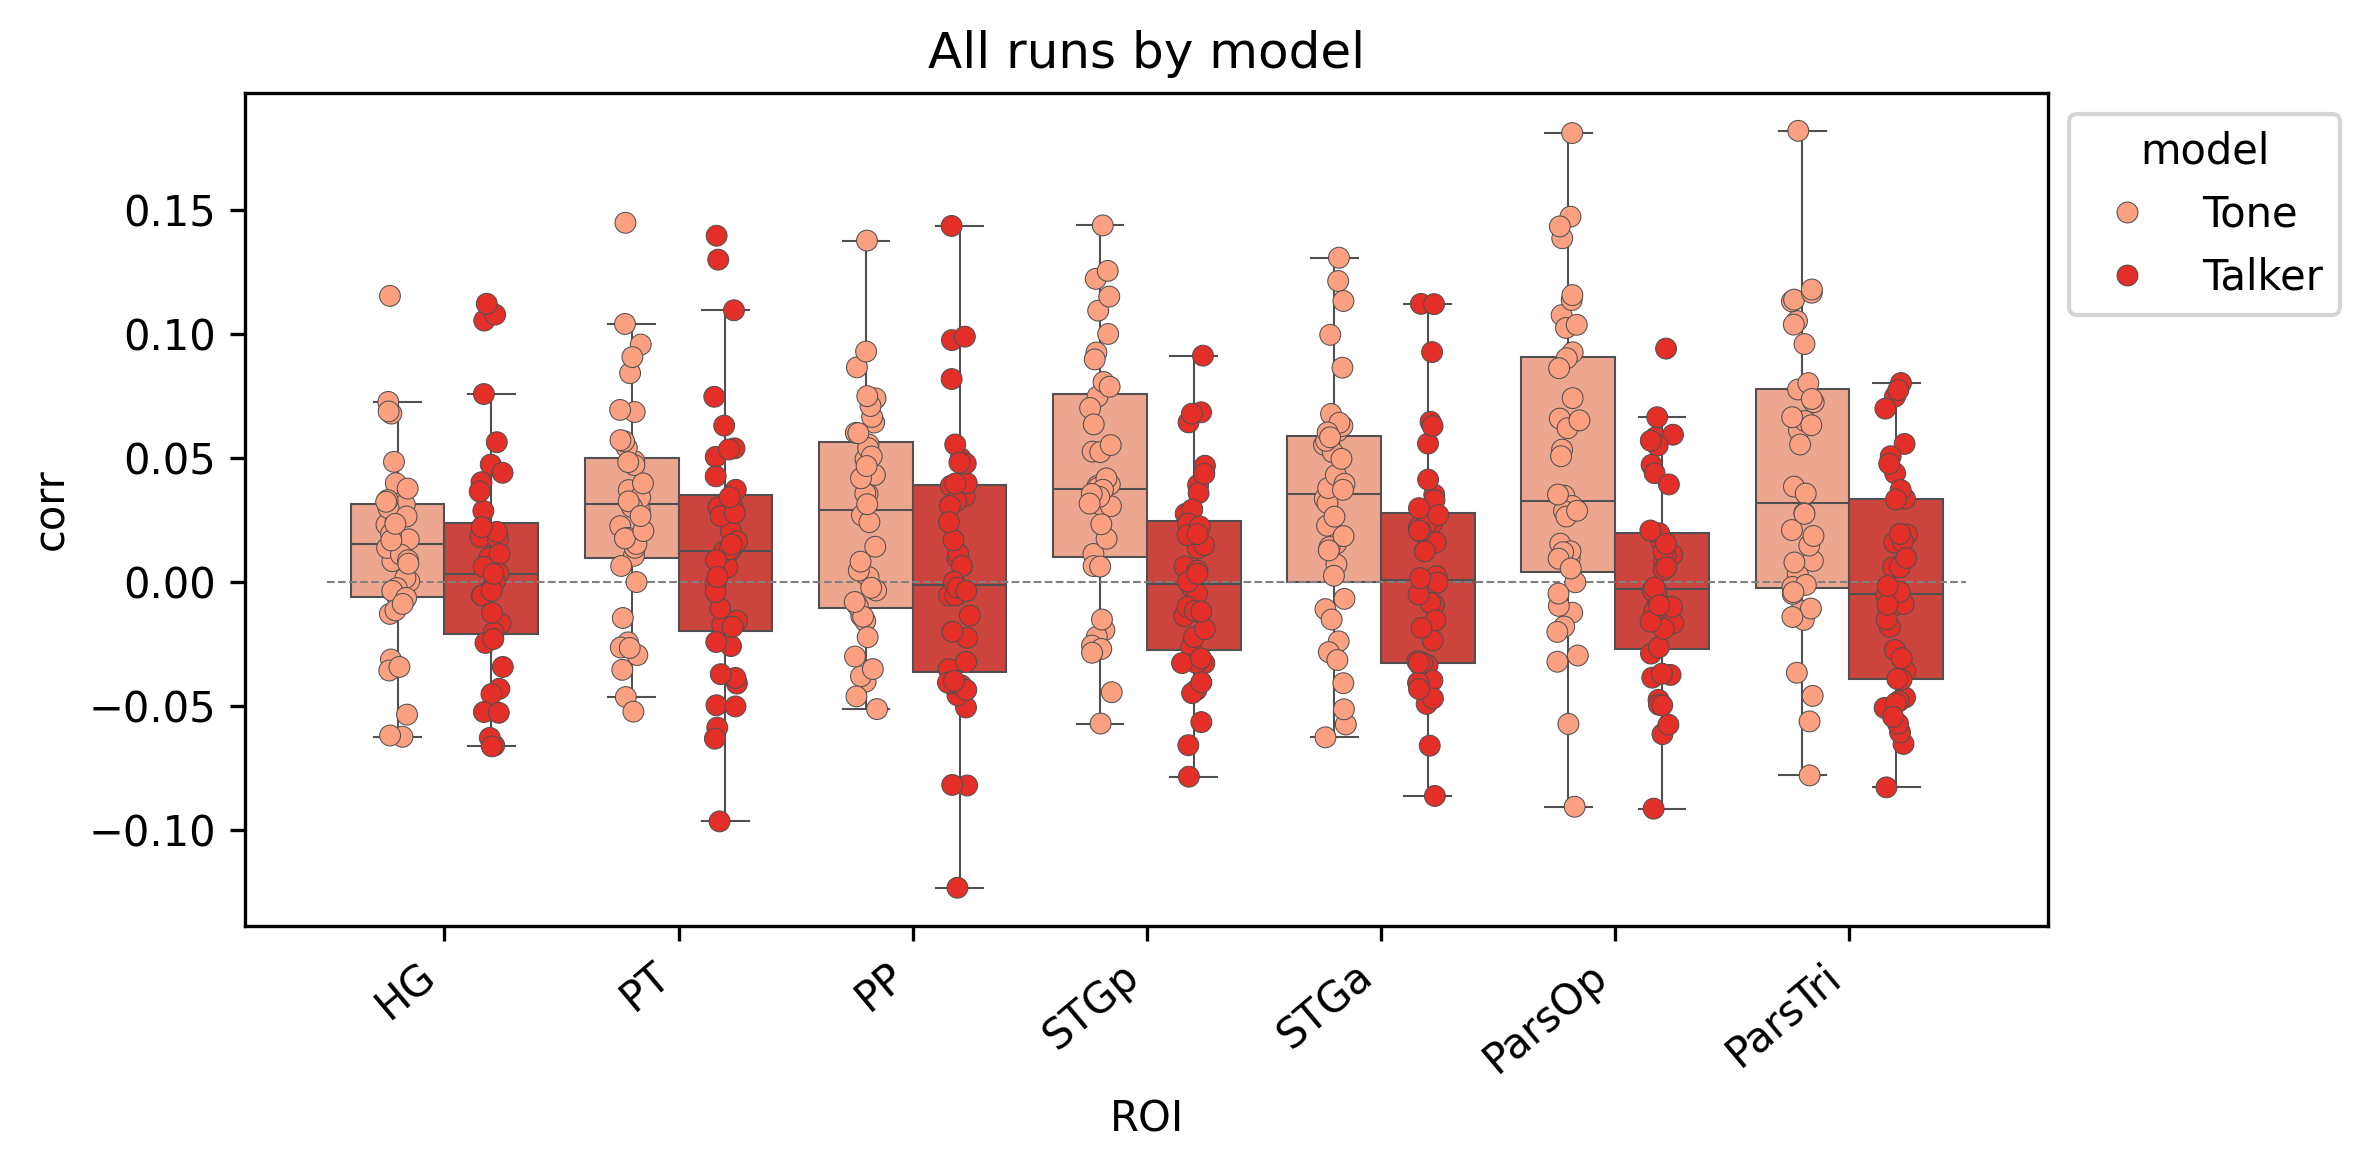

In [54]:
# combine hemispheres

fig, ax = plt.subplots(1,1, figsize=(8,4), dpi=300, sharey=True) # sharex=True, 
#ax = ax.flatten()

group_id = 'non-Mandarin'

#for mx, group_id in enumerate(np.unique(model_long_df.participant_group)):
group_df = laterality_df.where(laterality_df.participant_group==group_id).dropna()

sns.boxplot(data=group_df, 
            x='ROI', y='corr', hue='model', 
            palette='Reds', 
            linewidth=0.5, 
            fliersize = 0,
            legend=None,
            ax=ax, 
            #order=roi_list_ordered
           )
sns.stripplot(data=group_df, 
              x='ROI', y='corr', hue='model', 
              palette='Reds', dodge=True, 
              linewidth=0.25, 
              size=5,
              ax=ax, 
              #order=roi_list_ordered,
             )
handles, labels = ax.get_legend_handles_labels()  # Get legend handles and labels

xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right');
ax.set_title(f'All runs by model');
'''
ax.legend([],[], frameon=False)

# Add legend with only strip plot handles and labels 
# (since the two overlapping plots have redundant legends)
ax.legend(handles[3:], labels[3:], 
              title='Model',
              loc='upper left', bbox_to_anchor=(1, 1))
'''
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
#plt.setp(ax[mx].get_xticklabels(), visible=False)
fig.tight_layout()


#### By model, all runs

/scratch/slurm-3440091/ipykernel_50316/4212526346.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[mx].set_xticklabels(ax[mx].get_xticklabels(), rotation=45, ha='right');
/scratch/slurm-3440091/ipykernel_50316/4212526346.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[mx].set_xticklabels(ax[mx].get_xticklabels(), rotation=45, ha='right');


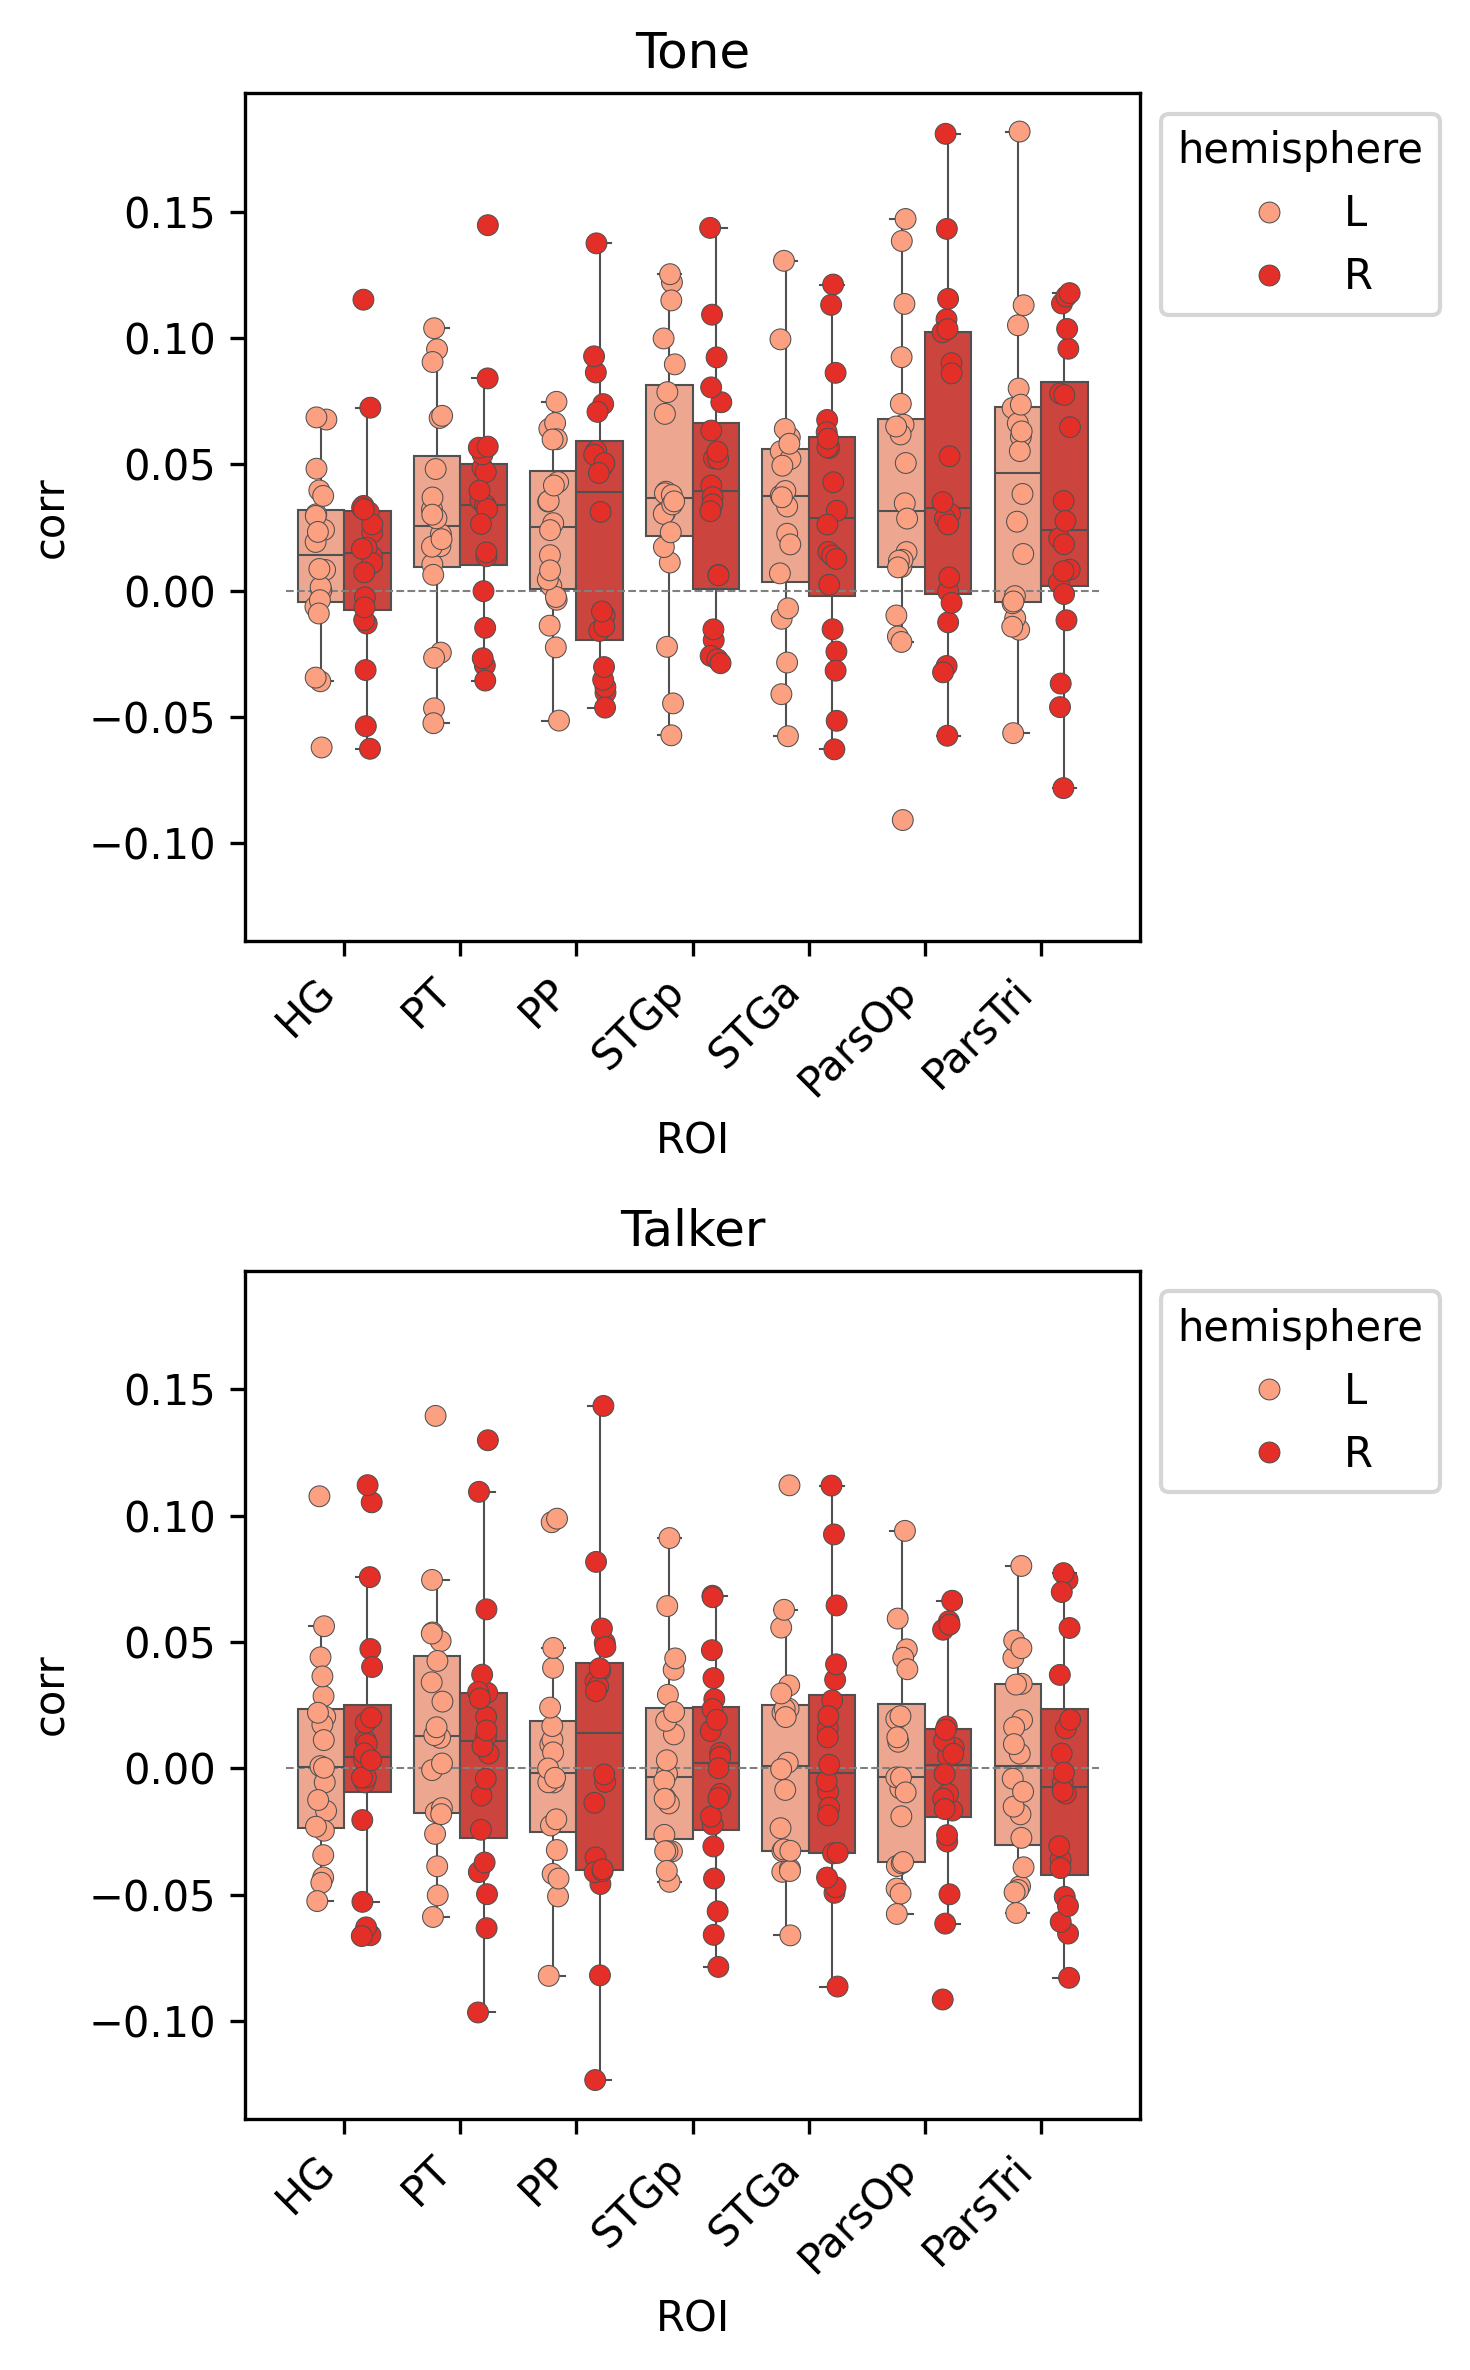

In [56]:
fig, ax = plt.subplots(2,1, figsize=(5,8), dpi=300, sharex=False, sharey=True)
#ax = ax.flatten()


for mx, model_id in enumerate(model_names):
    group_df = laterality_df.where(laterality_df.participant_group==group_id).where(laterality_df.model==model_id)

    sns.boxplot(data=group_df, 
                x='ROI', y='corr', hue='hemisphere', 
                palette='Reds', linewidth=0.5, 
                ax=ax[mx], 
                fliersize = 0,
                legend=None,
                #boxprops=dict(alpha=.3),
                #order=roi_list_ordered
                )
    sns.stripplot(data=group_df, 
                  x='ROI', y='corr', hue='hemisphere', 
                  palette='Reds', dodge=True, 
                  linewidth=0.25, 
                  size=5,
                  ax=ax[mx], 
                  #order=roi_list_ordered,
                 )
    xmin, xmax = ax[mx].get_xlim()
    ax[mx].hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
    sns.move_legend(ax[mx], "upper left", bbox_to_anchor=(1, 1))
    ax[mx].set_xticklabels(ax[mx].get_xticklabels(), rotation=45, ha='right');
    ax[mx].set_title(f'{model_id}');
    #ax[mx].legend([],[], frameon=False)
    #plt.setp(ax[mx].get_xticklabels(), visible=False)
fig.tight_layout()


/scratch/slurm-3440091/ipykernel_50316/913278971.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[mx].set_xticklabels(ax[mx].get_xticklabels(), rotation=45, ha='right');
/scratch/slurm-3440091/ipykernel_50316/913278971.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[mx].set_xticklabels(ax[mx].get_xticklabels(), rotation=45, ha='right');


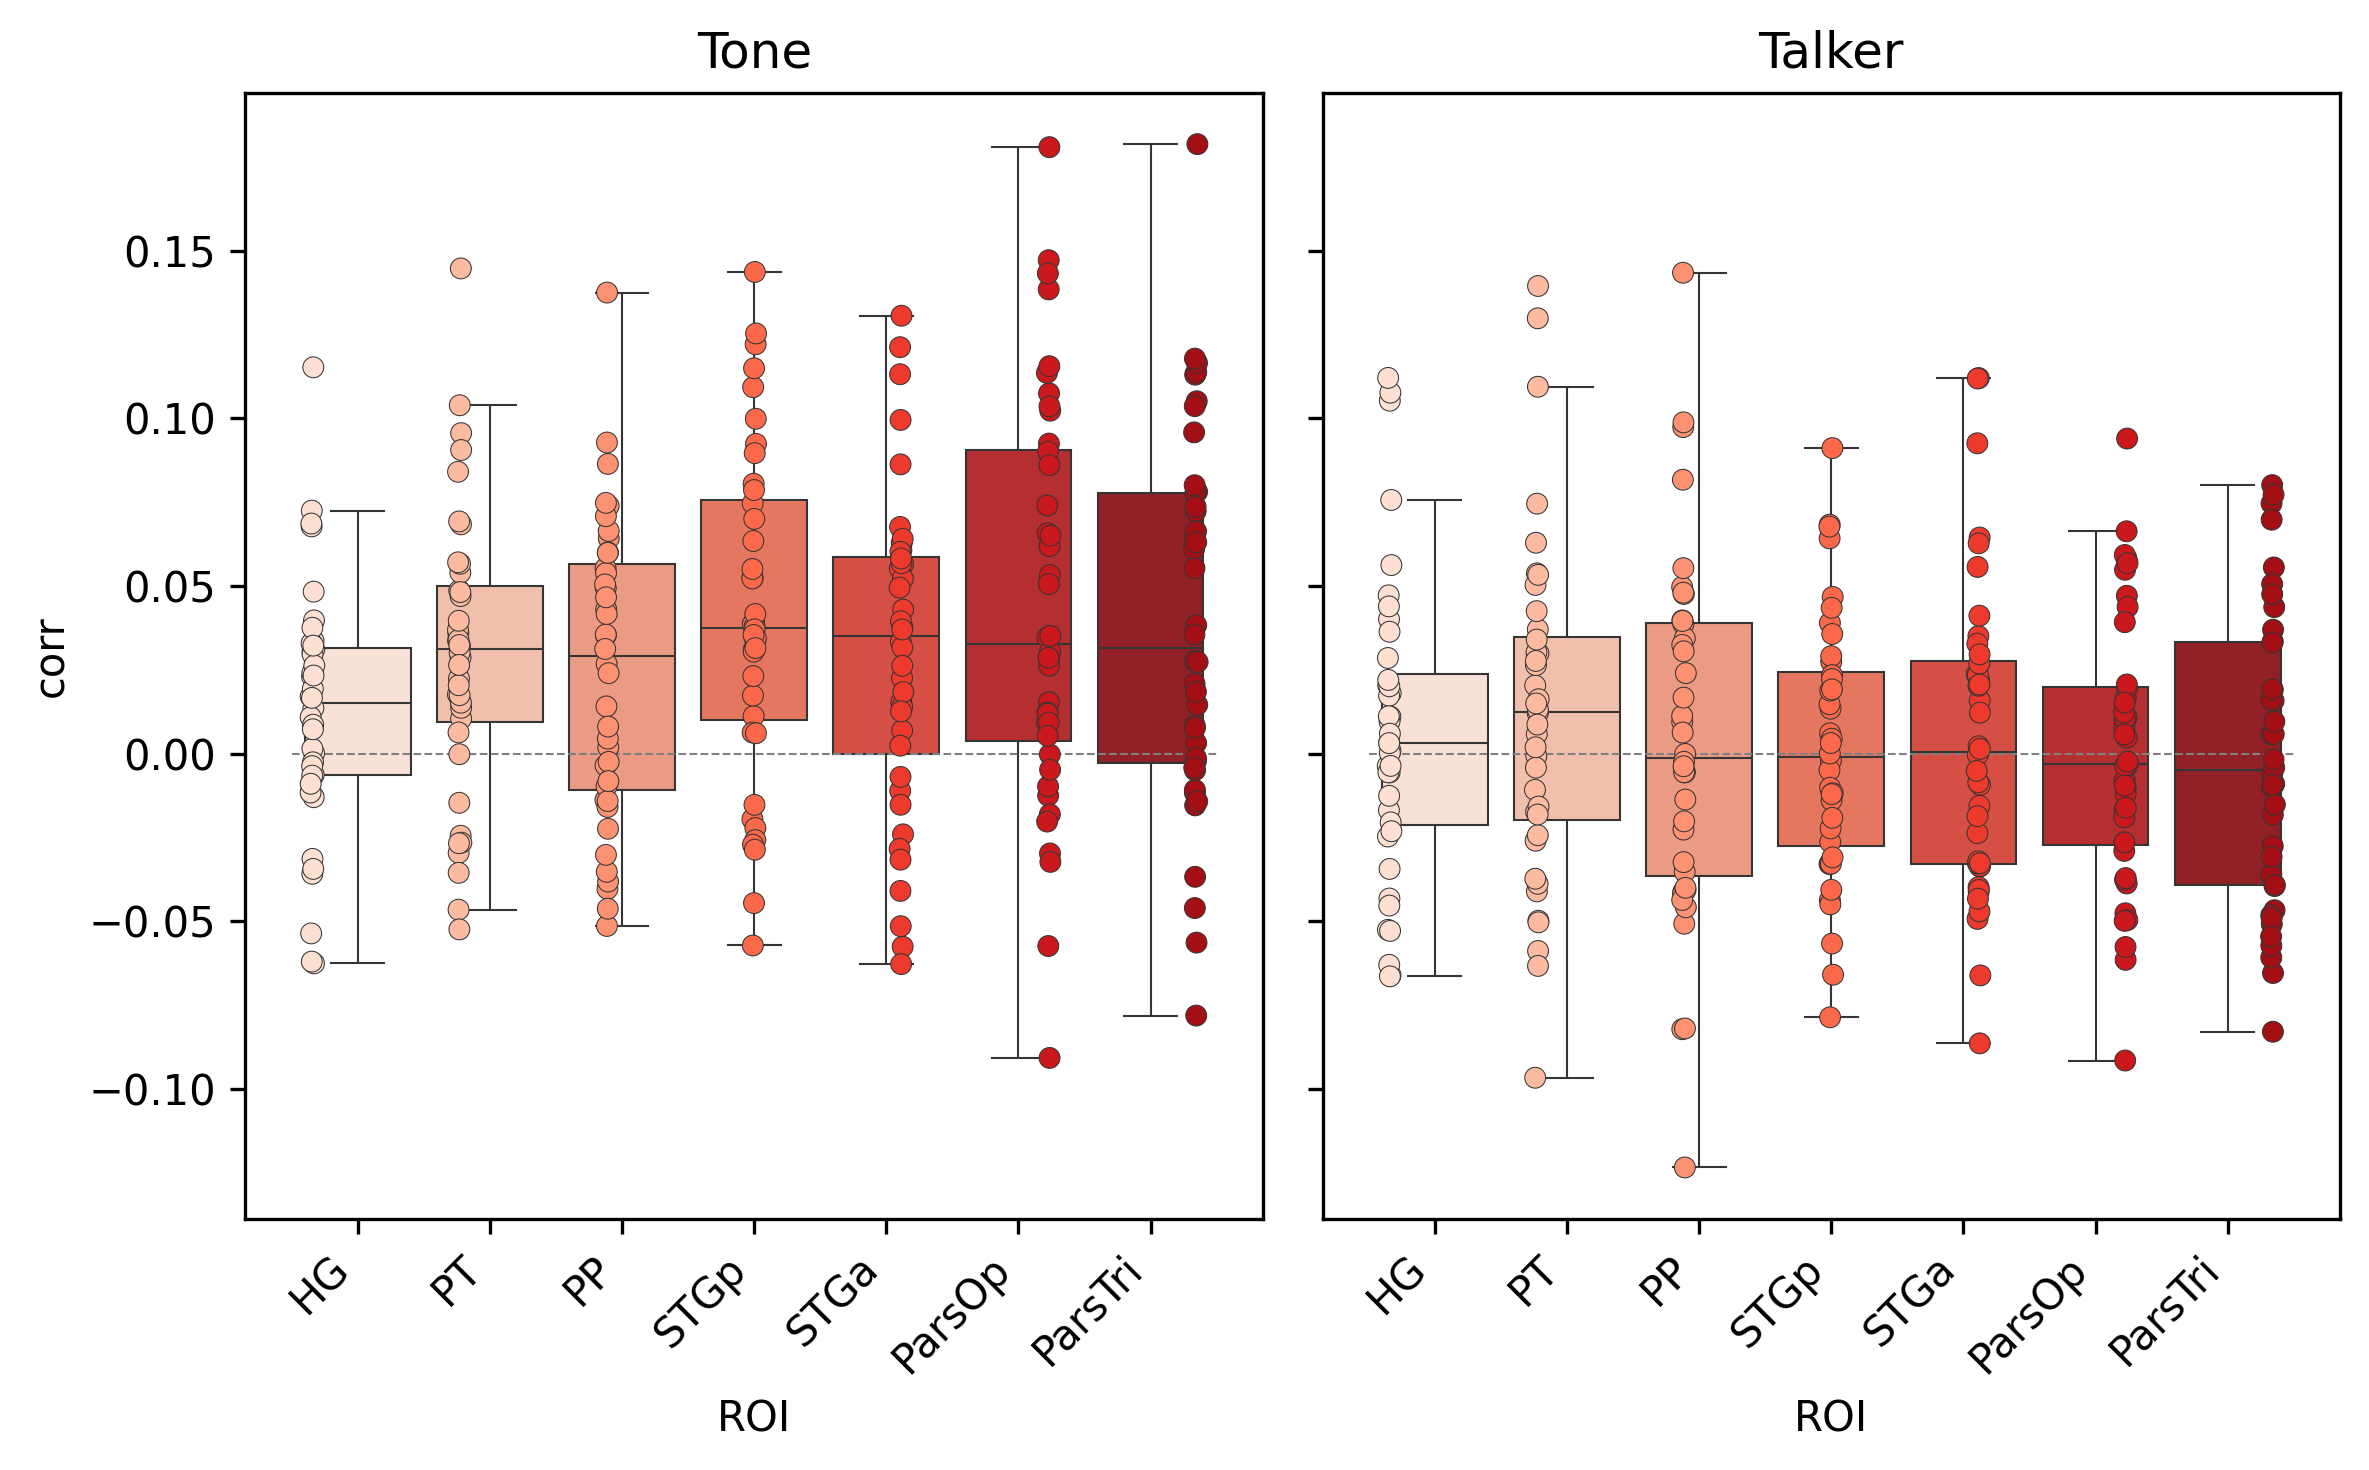

In [57]:
fig, ax = plt.subplots(1,2, figsize=(8,5), dpi=300, sharex=False, sharey=True)
#ax = ax.flatten()


for mx, model_id in enumerate(model_names):
    group_df = laterality_df.where(laterality_df.participant_group==group_id).where(laterality_df.model==model_id)

    sns.boxplot(data=group_df, 
                x='ROI', y='corr', hue='ROI', 
                palette='Reds', linewidth=0.5, 
                ax=ax[mx], 
                fliersize = 0,
                legend=None,
                #boxprops=dict(alpha=.3),
                #order=roi_list_ordered
                )
    sns.stripplot(data=group_df, 
                  x='ROI', y='corr', hue='ROI', 
                  legend=None,
                  palette='Reds', dodge=True, 
                  linewidth=0.25, 
                  size=5,
                  ax=ax[mx], 
                  #order=roi_list_ordered,
                 )
    xmin, xmax = ax[mx].get_xlim()
    ax[mx].hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
    #sns.move_legend(ax[mx], "upper left", bbox_to_anchor=(1, 1))
    ax[mx].set_xticklabels(ax[mx].get_xticklabels(), rotation=45, ha='right');
    ax[mx].set_title(f'{model_id}');
    #ax[mx].legend([],[], frameon=False)
    #plt.setp(ax[mx].get_xticklabels(), visible=False)
fig.tight_layout()


/scratch/slurm-3440091/ipykernel_50316/4192290873.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


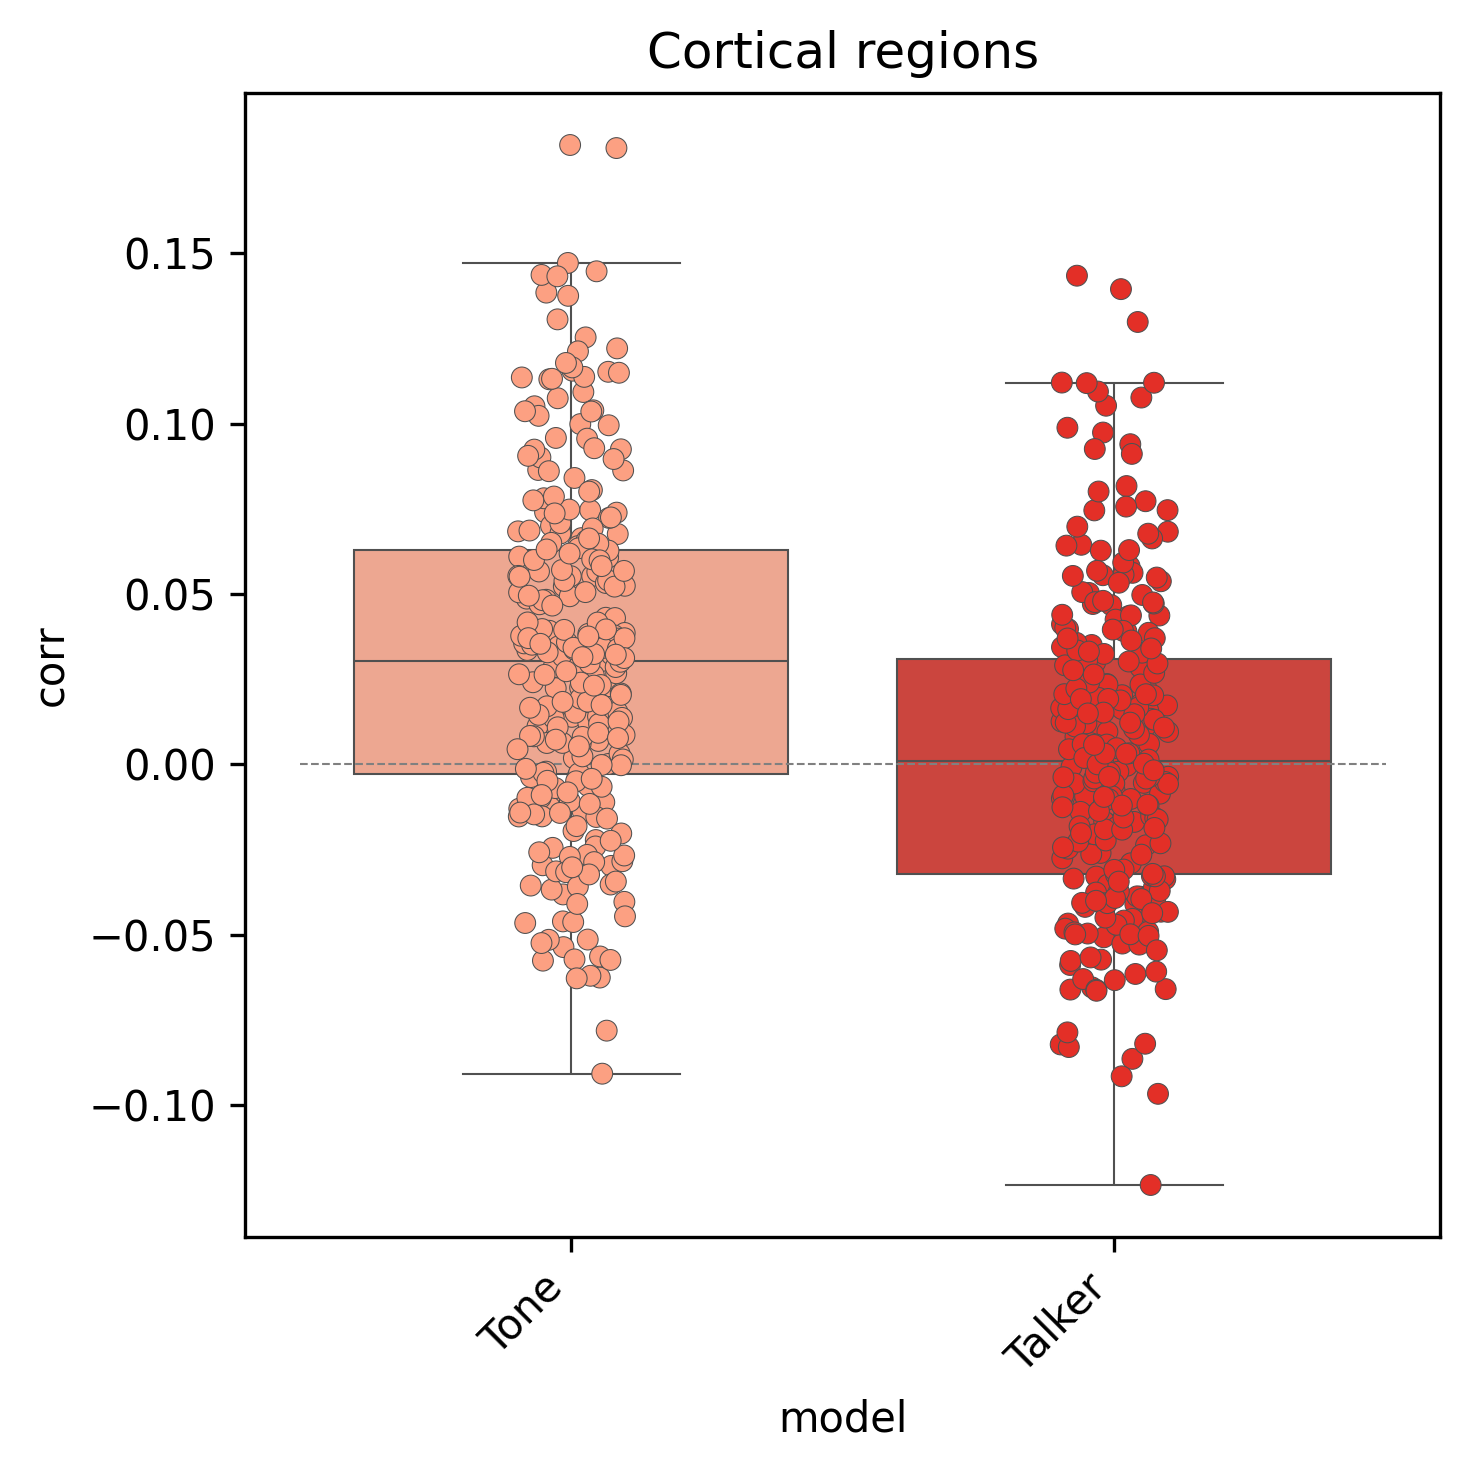

In [59]:
fig, ax = plt.subplots(1,1, figsize=(5,5), dpi=300, sharex=False, sharey=True)

group_df = laterality_df.where(laterality_df.participant_group==group_id)

sns.boxplot(data=group_df, 
            x='model', y='corr', hue='model', 
            palette='Reds', linewidth=0.5, 
            ax=ax, 
            fliersize = 0,
            legend=None,
            #boxprops=dict(alpha=.3),
            #order=roi_list_ordered
            )
sns.stripplot(data=group_df, 
              x='model', y='corr', hue='model', 
              palette='Reds', 
              #dodge=True, 
              linewidth=0.25, 
              legend=None,
              size=5,
              ax=ax, 
              #order=roi_list_ordered,
             )
xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');
ax.set_title(f'Cortical regions');
#ax[mx].legend([],[], frameon=False)
#plt.setp(ax[mx].get_xticklabels(), visible=False)
fig.tight_layout()


#### By group, by run

/scratch/slurm-4614381/ipykernel_171167/3642082356.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


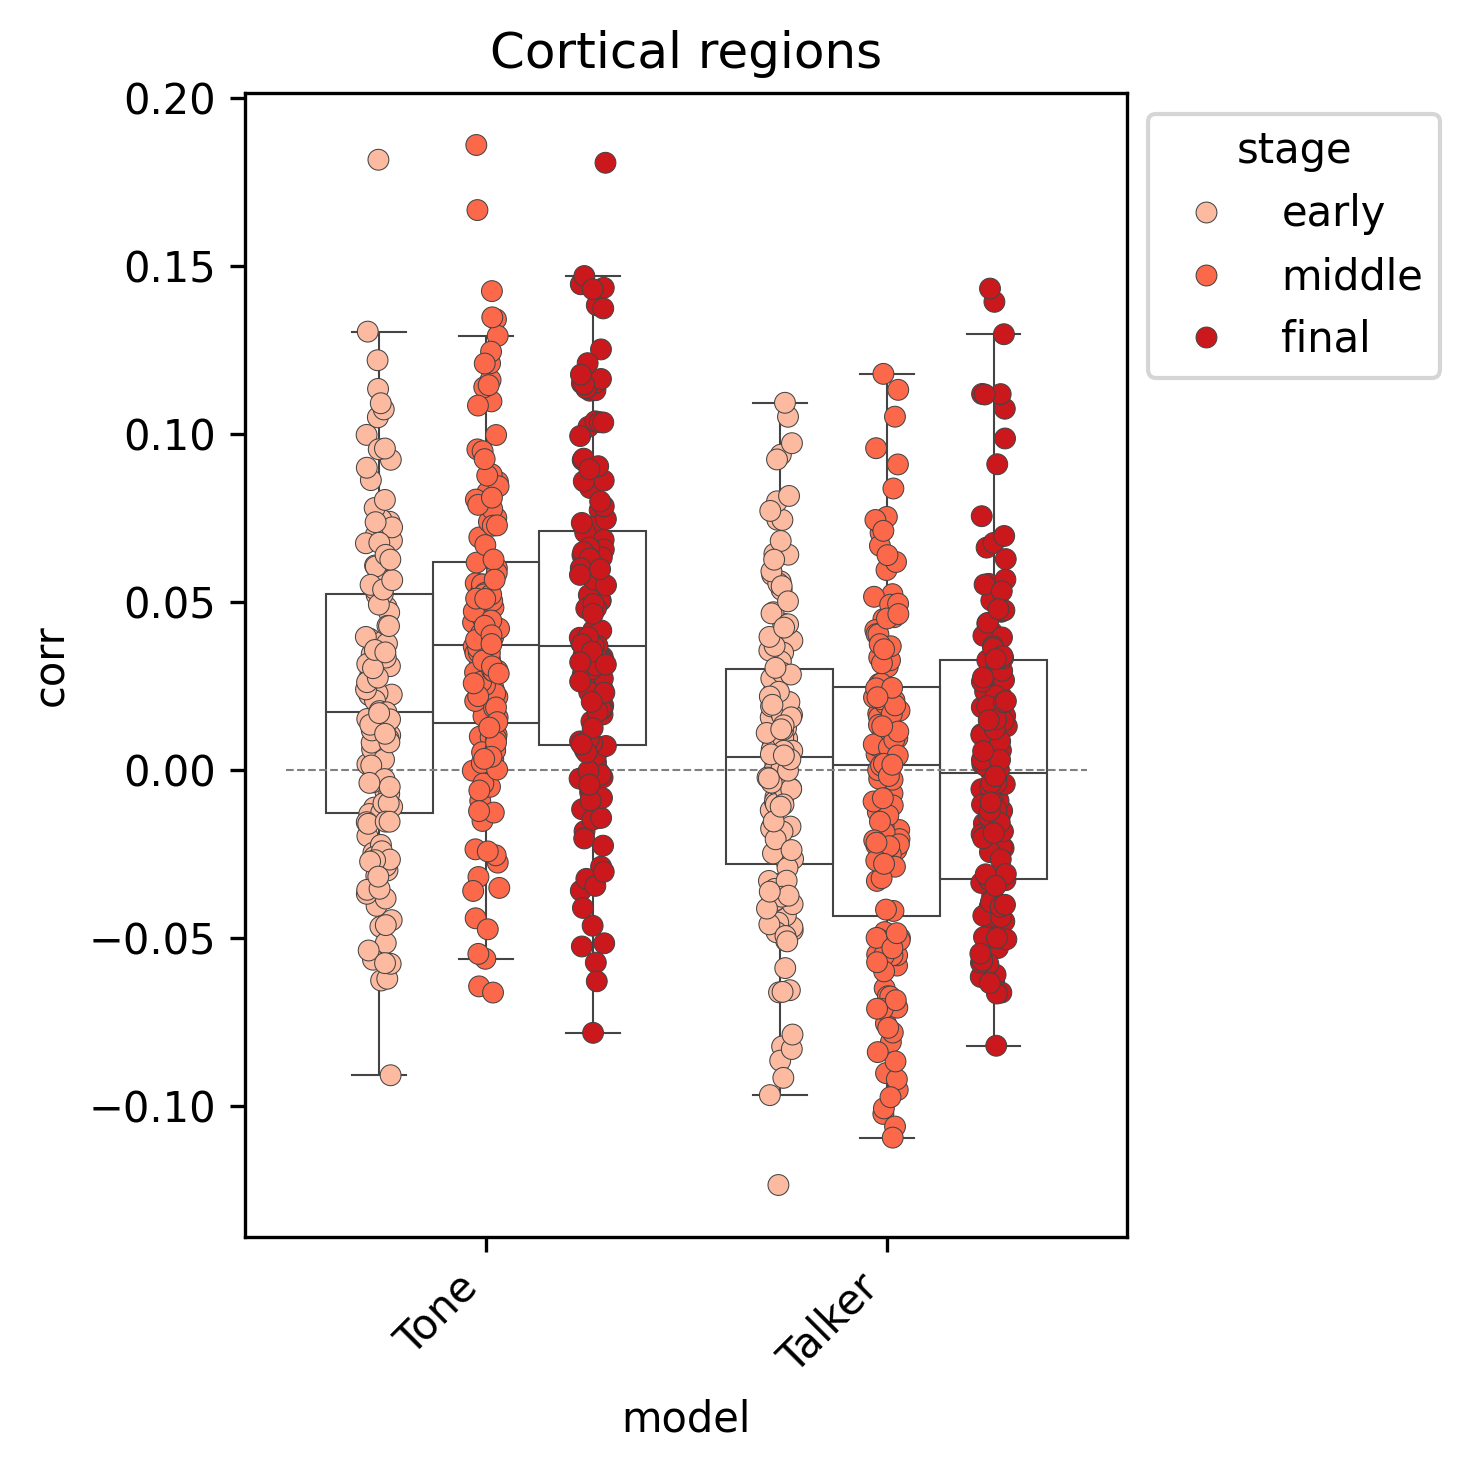

In [82]:
fig, ax = plt.subplots(1,1, figsize=(5,5), dpi=300, sharex=False, sharey=True)

group_df = laterality_df.where(laterality_df.participant_group==group_id)

sns.boxplot(data=group_df, 
            x='model', y='corr', hue='stage', 
            palette='Reds', linewidth=0.5, 
            ax=ax, 
            fliersize = 0,
            legend=None, 
            #boxprops=dict(alpha=.3),
            #order=roi_list_ordered
            )
sns.stripplot(data=group_df, 
              x='model', y='corr', hue='stage', 
              palette='Reds', dodge=True, 
              linewidth=0.25, 
              size=5,
              ax=ax, 
              #order=roi_list_ordered,
             )
xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');
ax.set_title(f'Cortical regions');

# Modify the boxplot to make the boxes white (or transparent)
for patch in ax.patches:
    patch.set_facecolor('none')  # or 'none' for transparent boxes

#ax.legend([],[], frameon=False)
#plt.setp(ax[mx].get_xticklabels(), visible=False)
fig.tight_layout()


/scratch/slurm-3283761/ipykernel_13953/2248329281.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[mx].set_xticklabels(ax[mx].get_xticklabels(), rotation=45, ha='right');
/scratch/slurm-3283761/ipykernel_13953/2248329281.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[mx].set_xticklabels(ax[mx].get_xticklabels(), rotation=45, ha='right');


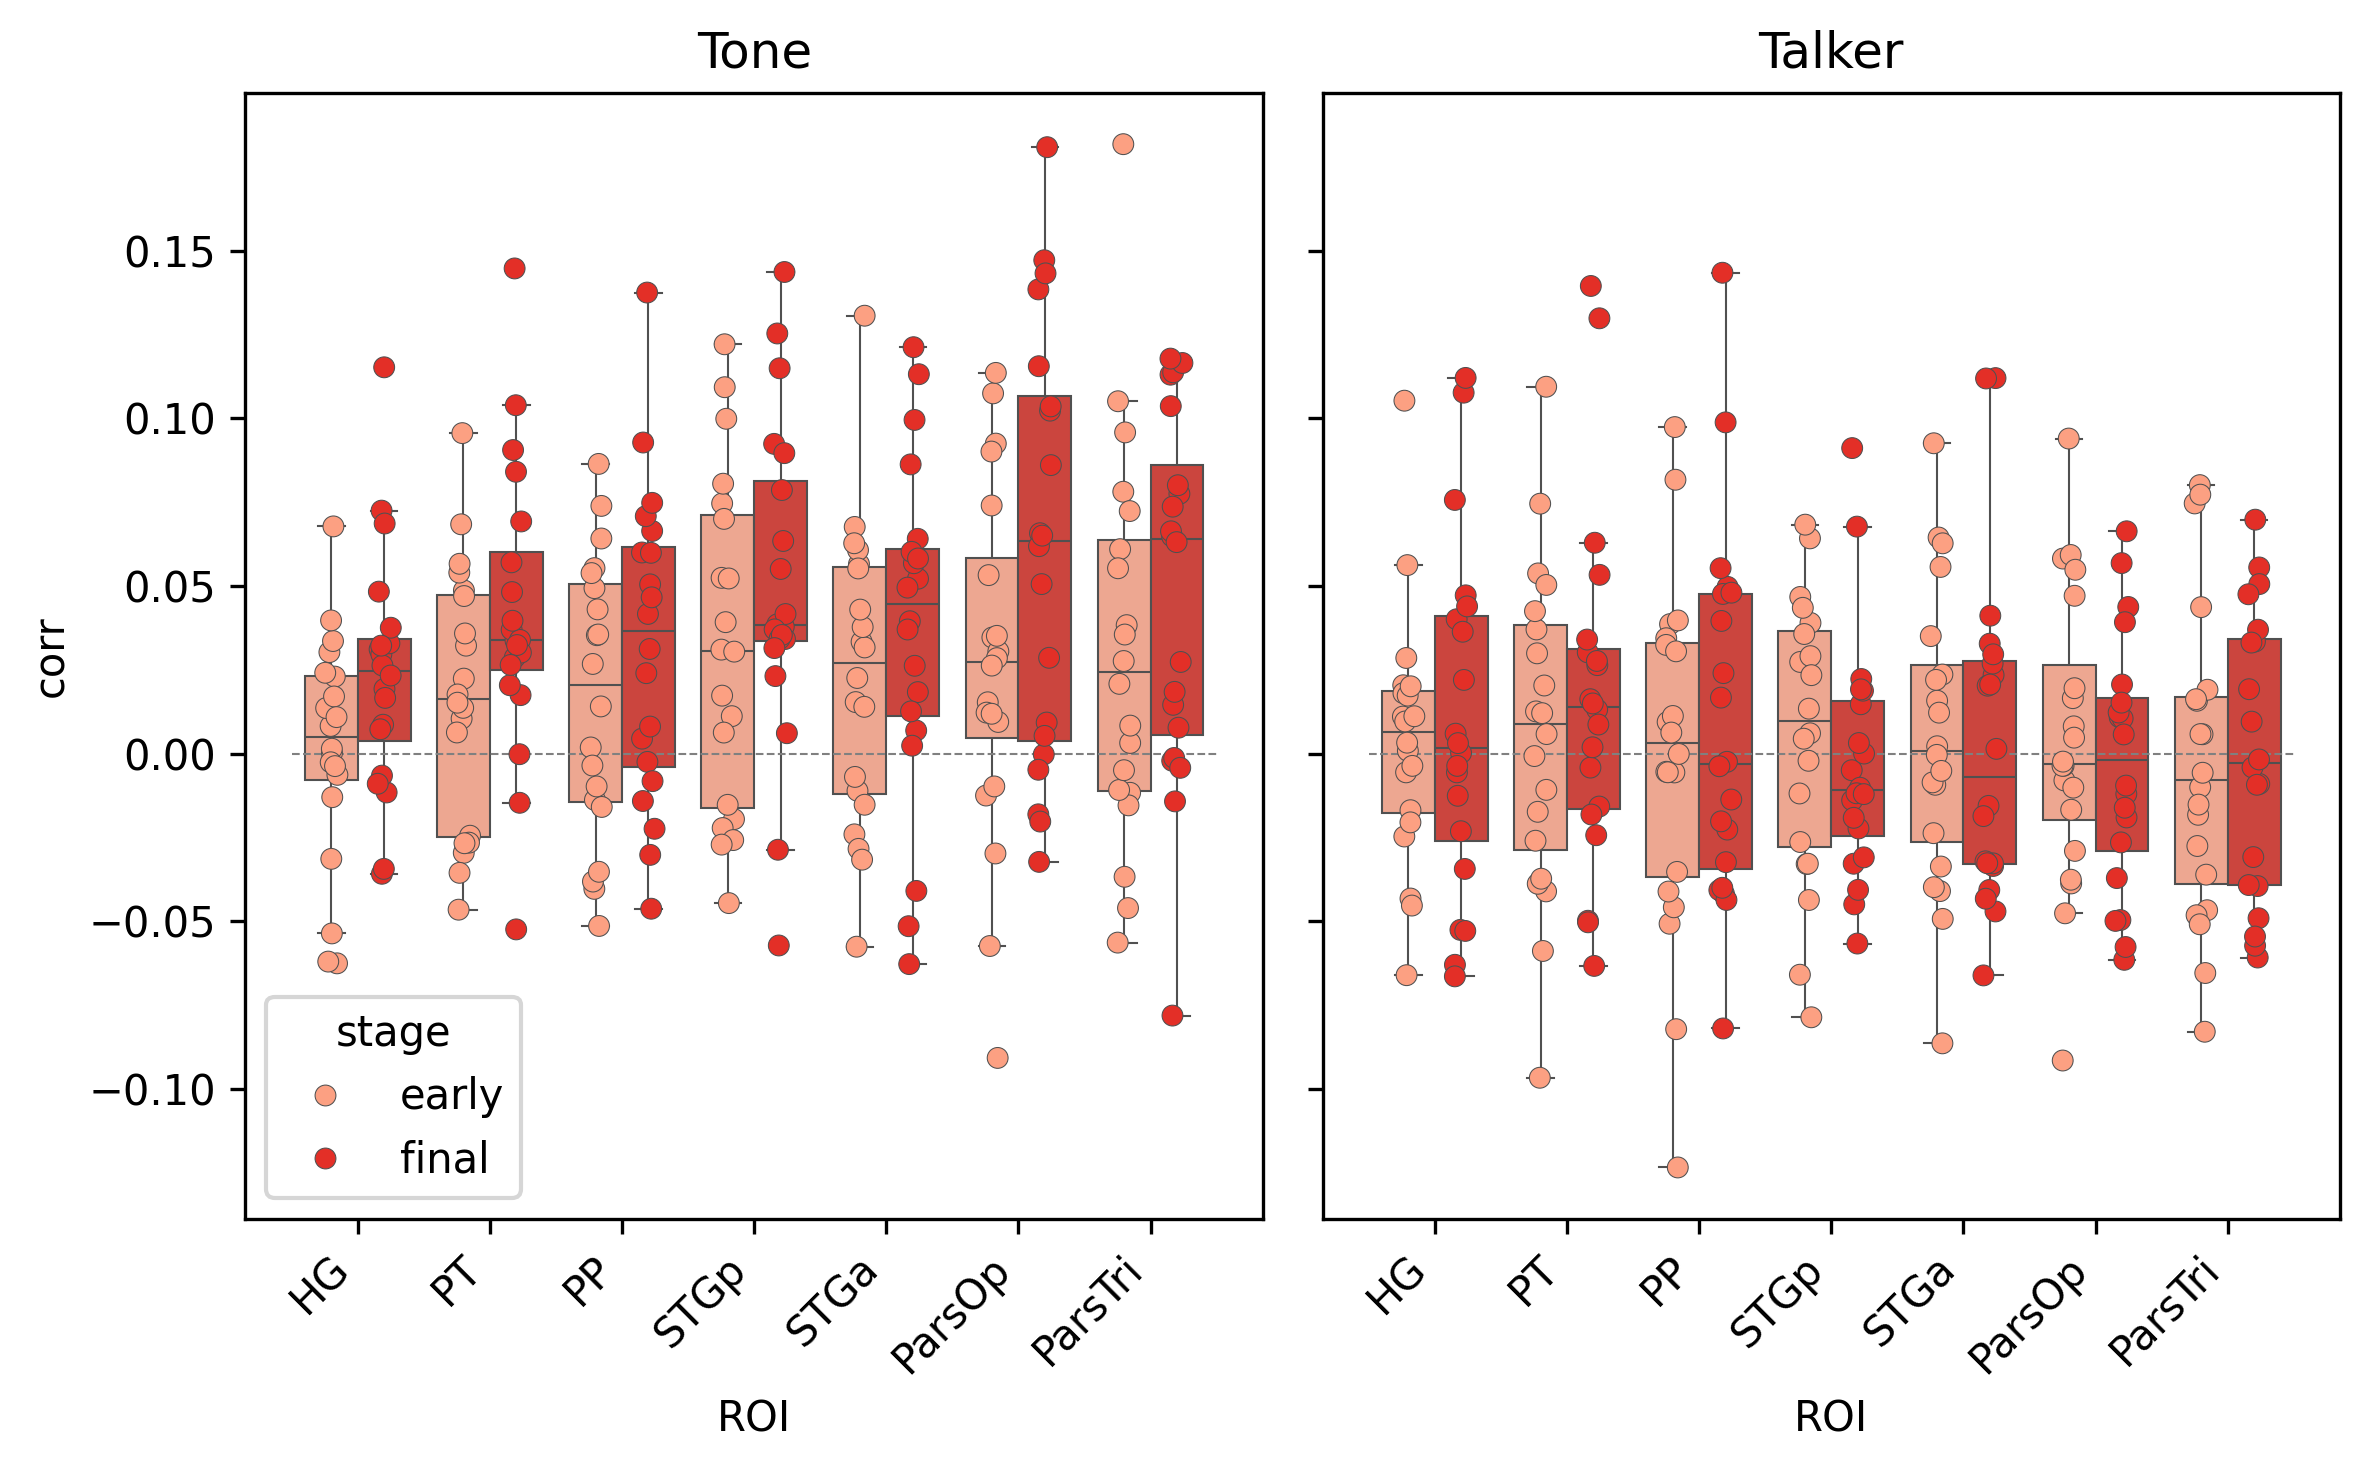

In [100]:
fig, ax = plt.subplots(1,2, figsize=(8,5), dpi=300, sharex=False, sharey=True)
#ax = ax.flatten()


for mx, model_id in enumerate(model_names):
    group_df = laterality_df.where(laterality_df.participant_group==group_id).where(laterality_df.model==model_id)

    sns.boxplot(data=group_df, 
                x='ROI', y='corr', hue='stage', 
                palette='Reds', 
                linewidth=0.5, 
                ax=ax[mx], 
                fliersize = 0,
                legend=None,
                #boxprops=dict(alpha=.3),
                #order=roi_list_ordered
                )
    sns.stripplot(data=group_df, 
                  x='ROI', y='corr', hue='stage', 
                  palette='Reds', dodge=True, 
                  linewidth=0.25, 
                  size=5,
                  ax=ax[mx], 
                  #order=roi_list_ordered,
                 )
    xmin, xmax = ax[mx].get_xlim()
    ax[mx].hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
    #sns.move_legend(ax[mx], "upper left", bbox_to_anchor=(1, 1))
    ax[mx].set_xticklabels(ax[mx].get_xticklabels(), rotation=45, ha='right');
    ax[mx].set_title(f'{model_id}');
    if mx > 0:
        ax[mx].legend([],[], frameon=False)
    #plt.setp(ax[mx].get_xticklabels(), visible=False)
fig.tight_layout()


### ANOVA statistics

In [65]:
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [74]:
laterality_df

,index,ROI,stage,participant_group,model,corr,hemisphere
0,0,HG,early,Mandarin,Tone,0.144426,L
1,1,PT,early,Mandarin,Tone,0.109846,L
2,2,PP,early,Mandarin,Tone,0.162085,L
3,3,STGp,early,Mandarin,Tone,0.079980,L
4,4,STGa,early,Mandarin,Tone,0.156978,L
...,...,...,...,...,...,...,...
1759,135,PP,final,non-Mandarin,Talker,-0.040013,R
1760,136,STGp,final,non-Mandarin,Talker,-0.056632,R
1761,137,STGa,final,non-Mandarin,Talker,-0.018636,R
1762,138,ParsOp,final,non-Mandarin,Talker,-0.049883,R


In [80]:
formula = 'corr ~ model'
model = ols(formula, data=laterality_df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
aov_table

,sum_sq,df,F,PR(>F)
model,0.202187,1.0,89.015764,2.025198e-20
Residual,2.666581,1174.0,NaN,NaN


In [83]:
formula = 'corr ~ hemisphere'
model = ols(formula, data=laterality_df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
aov_table

,sum_sq,df,F,PR(>F)
hemisphere,0.000721,1.0,0.295178,0.587024
Residual,2.868047,1174.0,NaN,NaN


In [82]:
formula = 'corr ~ stage'
group_id = 'non-Mandarin'
for model_id in model_names:
    print(f'\n{model_id}')

    nman_df = laterality_df.where(laterality_df.participant_group==group_id).where(laterality_df.model==model_id) # .where(model_long_df.ROI.isin(roi_list_ordered))

    model = ols(formula, data=nman_df).fit()
    aov_table = sm.stats.anova_lm(model, typ=2)
    print(aov_table)



Tone
            sum_sq     df         F    PR(>F)
stage     0.030956    1.0  13.32448  0.000313
Residual  0.645865  278.0       NaN       NaN

Talker
            sum_sq     df         F    PR(>F)
stage     0.000216    1.0  0.105153  0.745975
Residual  0.571026  278.0       NaN       NaN


In [75]:
roi_names = np.unique(laterality_df.ROI)

In [79]:
formula = 'corr ~ model | ROI'
group_id = 'non-Mandarin'
for region in roi_names:
    print(f'\n{region}')

    nman_df = laterality_df.where(laterality_df.participant_group==group_id).where(laterality_df.ROI==region) # .where(model_long_df.ROI.isin(roi_list_ordered))

    model = ols(formula, data=nman_df).fit()
    aov_table = sm.stats.anova_lm(model) #, typ=2)
    print(aov_table)



HG


PatsyError: Error evaluating factor: TypeError: unsupported operand type(s) for |: 'str' and 'str'
    corr ~ model | ROI
           ^^^^^^^^^^^

In [78]:
formula = 'corr ~ model'
group_id = 'non-Mandarin'
for region in roi_names:
    print(f'\n{region}')

    nman_df = laterality_df.where(laterality_df.participant_group==group_id).where(laterality_df.ROI==region) # .where(model_long_df.ROI.isin(roi_list_ordered))

    model = ols(formula, data=nman_df).fit()
    aov_table = sm.stats.anova_lm(model) #, typ=2)
    print(aov_table)



HG
            df    sum_sq   mean_sq         F   PR(>F)
model      1.0  0.000787  0.000787  0.474783  0.49284
Residual  78.0  0.129255  0.001657       NaN      NaN

PP
            df    sum_sq   mean_sq         F    PR(>F)
model      1.0  0.008198  0.008198  3.432592  0.067704
Residual  78.0  0.186284  0.002388       NaN       NaN

PT
            df    sum_sq   mean_sq         F    PR(>F)
model      1.0  0.006319  0.006319  2.915992  0.091683
Residual  78.0  0.169038  0.002167       NaN       NaN

ParsOp
            df    sum_sq   mean_sq          F    PR(>F)
model      1.0  0.038130  0.038130  14.352797  0.000297
Residual  78.0  0.207219  0.002657        NaN       NaN

ParsTri
            df    sum_sq   mean_sq          F   PR(>F)
model      1.0  0.033106  0.033106  12.989412  0.00055
Residual  78.0  0.198800  0.002549        NaN      NaN

STGa
            df    sum_sq   mean_sq         F   PR(>F)
model      1.0  0.013996  0.013996  6.379606  0.01357
Residual  78.0  0.171119  0.0021

In [73]:
formula = 'corr ~ ROI'
group_id = 'non-Mandarin'
for model_id in model_names:
    print(f'\n{model_id}')

    nman_df = laterality_df.where(laterality_df.participant_group==group_id).where(laterality_df.model==model_id) # .where(model_long_df.ROI.isin(roi_list_ordered))

    model = ols(formula, data=nman_df).fit()
    aov_table = sm.stats.anova_lm(model, typ=2)
    print(aov_table)



Tone
            sum_sq     df         F    PR(>F)
ROI       0.028622    6.0  2.009116  0.064653
Residual  0.648199  273.0       NaN       NaN

Talker
            sum_sq     df         F    PR(>F)
ROI       0.004513    6.0  0.362305  0.902319
Residual  0.566729  273.0       NaN       NaN


## Run-all

In [ ]:
model_desc = 'run-all_LSS'

### Load run-all subject-specific RDMs

In [ ]:
# from `rsa_roi.py`-generated outputs
group_rdm_list = []
for sx, sub_id in enumerate(participant_list): # enumerate(['FLT03']): #
    print(sub_id)
    group_id = group_assignment[sx]

    out_dir = os.path.join(model_dir, 'rsa_roi', network_name)
    os.makedirs(out_dir, exist_ok=True)
    sub_fpath = os.path.join(out_dir,
                         f'sub-{sub_id}_{network_name}_{model_desc}_rdms.hdf5')
    sub_rdm = rsatoolbox.rdm.rdms.load_rdm(sub_fpath)
    
    # add the group descriptor to the subject's RDM
    sub_rdm.rdm_descriptors['group'] = [group_id for x in sub_rdm.rdm_descriptors['index']]
    group_rdm_list.append(sub_rdm)
runall_rdms = rsatoolbox.rdm.rdms.concat(group_rdm_list)

In [ ]:
sub_rdm

### plot all RDMs

In [ ]:
fig = plt.figure(constrained_layout=True, figsize=(20,30), dpi=500)
fig.suptitle('Single-participant ROI RDMs')

subfigs = fig.subfigures(nrows=len(participant_list), ncols=1)

for sx, sub_id in enumerate(participant_list):
    subfigs[sx].suptitle(f'{sub_id} - {group_assignment[sx]} group')
    axes = subfigs[sx].subplots(nrows=1, ncols=len(roi_list_ordered))
    for rx, roi in enumerate(roi_list_ordered):
        rsatoolbox.vis.show_rdm_panel(runall_rdms.subset('participant', value=sub_id).subset('ROI', value=roi), 
                                        ax=axes[rx],
                                        rdm_descriptor='ROI', 
                                        cmap='inferno',
                                        #show_colorbar='panel', # cut figsize height in half if showing colorbar
                                       );


### Mean RDMs across participants per group

In [ ]:
roi_list = roi_list_ordered

In [ ]:
mean_rdms_mand_list = []
mean_rdms_nman_list = []
for rx, roi in enumerate(roi_list):
    # Mandarin-speaking
    dissim_mand = runall_rdms.subset('group', value='Mandarin').subset('ROI', value=roi).dissimilarities
    
    roi_mand = RDMs(dissim_mand.mean(axis=0),
                    rdm_descriptors={'ROI': roi_list[rx], 'group': 'Mandarin'},
                    pattern_descriptors=pattern_descriptors)
    mean_rdms_mand_list.append(roi_mand)
    
    # non-Mandarin-speaking
    dissim_nman = runall_rdms.subset('group', value='non-Mandarin').subset('ROI', value=roi).dissimilarities
    roi_nman = RDMs(dissim_nman.mean(axis=0),
                    rdm_descriptors={'ROI': roi_list[rx], 'group': 'non-Mandarin'},
                    pattern_descriptors=pattern_descriptors)
    mean_rdms_nman_list.append(roi_nman)

mean_rdms_mand = rsatoolbox.rdm.rdms.concat(mean_rdms_mand_list)
mean_rdms_nman = rsatoolbox.rdm.rdms.concat(mean_rdms_nman_list)



In [ ]:
mean_rdms_nman

In [ ]:
fig = plt.figure(constrained_layout=True, figsize=(20,4), dpi=500)
fig.suptitle('Mean RDMs by group and ROI')

subfigs = fig.subfigures(nrows=2, ncols=1)

n_mand = len(sub_group_dict['Mandarin'])
n_nman = len(sub_group_dict['non-Mandarin'])

subfigs[0].suptitle(f'Mandarin-speaking group (n = {n_mand})')
subfigs[1].suptitle(f'non-Mandarin-speaking group (n = {n_nman})')

axs0 = subfigs[0].subplots(nrows=1, ncols=len(roi_list))
axs1 = subfigs[1].subplots(nrows=1, ncols=len(roi_list))
for rx, roi in enumerate(roi_list):
    rsatoolbox.vis.show_rdm_panel(mean_rdms_mand.subset('ROI', value=roi), 
                                  rdm_descriptor='ROI', 
                                  cmap='inferno', 
                                  ax=axs0[rx])
    rsatoolbox.vis.show_rdm_panel(mean_rdms_nman.subset('ROI', value=roi), 
                                  rdm_descriptor='ROI', 
                                  cmap='inferno', 
                                  ax=axs1[rx])

#### MDS

In [ ]:
rsatoolbox.vis.scatter_plot.show_MDS(mean_rdms_mand, 
                                     rdm_descriptor='ROI',
                                     pattern_descriptor='tone')

In [ ]:
rsatoolbox.vis.scatter_plot.show_MDS(mean_rdms_nman, 
                                     rdm_descriptor='ROI',
                                     pattern_descriptor='tone')

### Model comparisons

In [ ]:
[x.name for x in cat_models]

#### Across all ROIs

In [ ]:
'''
group = 'Mandarin'
ROI = 'mask-R-ParsTri'
'''
group_results = {}
for group in np.unique(runall_rdms.rdm_descriptors['group']):
    group_results[group] = {}
    print(f'group-{group}')
    results_grr = rsatoolbox.inference.eval_fixed(cat_models, 
                                                  runall_rdms.subset('group', value=group),  
                                                  method='corr',)

    fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr);
    ax1.set_title(f'group-{group} network-{network_name}');
    ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")

    #results_grr.save(f'results-eval/run-all/results-eval_denoised_run-all_group-{group}_{network_name}_ROI-{ROI}.hdf5',overwrite=True)

    group_results[group]['Tone'] = results_grr.to_dict()['evaluations'][0][0]
    group_results[group]['Talker'] = results_grr.to_dict()['evaluations'][0][1]
    #roi_results[group][ROI] = results_grr.to_dict()['evaluations']


#### Per ROI

In [ ]:
'''
group = 'Mandarin'
ROI = 'mask-R-ParsTri'
'''
roi_results = {}
for group in np.unique(runall_rdms.rdm_descriptors['group']):
    roi_results[group] = {}
    for ROI in np.unique(runall_rdms.rdm_descriptors['ROI']):
        print(f'group-{group} ROI-{ROI}')
        results_grr = rsatoolbox.inference.eval_fixed(cat_models, 
                                                      runall_rdms.subset('group', value=group).subset('ROI',value=ROI),  
                                                      method='corr',)
        
        fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr);
        ax1.set_title(f'group-{group} ROI-{ROI}');
        ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")
        
        #results_grr.save(f'results-eval/run-all/results-eval_denoised_run-all_group-{group}_{network_name}_ROI-{ROI}.hdf5',overwrite=True)
        
        roi_results[group][ROI] = {}
        roi_results[group][ROI]['Tone'] = results_grr.to_dict()['evaluations'][0][0]
        roi_results[group][ROI]['Talker'] = results_grr.to_dict()['evaluations'][0][1]
        #roi_results[group][ROI] = results_grr.to_dict()['evaluations']
        

In [ ]:
results_grr.to_dict()['evaluations']

In [ ]:
print(results_grr.summary())

#### Custom plots

In [ ]:
roi_results

In [ ]:
pd.DataFrame.from_dict(roi_results['Mandarin'], orient='index')

# ARCHIVE